## Single-Category Sales Forecasting Experiments

The objective is to analyze the behavior of all product categories, select representative categories, and train separate forecasting models for individual categories.

### Step 1:  Load cleaned daily category sales

### Step 0: Setup

Data loading, feature engineering, splits, metrics and models are imported
from the `src/` package rather than redefined here, so this notebook uses the
same implementations as every other one.

Run from the repository root.

In [8]:
import os
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src import config, features as feat, splits as spl, models as mdl
from src import pipeline as pipe, validation as val
from src.metrics import evaluate_forecast

daily = pd.read_csv(config.DAILY_CLEAN, parse_dates=["Date"])
daily.head(10)

,Date,Category,Quantity,Revenue,Orders
0,2010-12-01,"Bag Charms, Key Rings & Phone Charms",1,1.66,1
1,2010-12-02,"Bag Charms, Key Rings & Phone Charms",206,133.90,3
2,2010-12-03,"Bag Charms, Key Rings & Phone Charms",1,1.25,1
3,2010-12-04,"Bag Charms, Key Rings & Phone Charms",0,0.00,0
4,2010-12-05,"Bag Charms, Key Rings & Phone Charms",58,37.90,8
5,2010-12-06,"Bag Charms, Key Rings & Phone Charms",18,20.79,4
6,2010-12-07,"Bag Charms, Key Rings & Phone Charms",52,37.84,2
7,2010-12-08,"Bag Charms, Key Rings & Phone Charms",4,6.64,1
8,2010-12-09,"Bag Charms, Key Rings & Phone Charms",111,82.09,3
9,2010-12-10,"Bag Charms, Key Rings & Phone Charms",5,8.30,2


### Interpretation

The dataset contains one row for each combination of **Date** and **Category**.  
For each category on each day, the table gives:

- `Quantity`: total quantity sold for that category on that date;
- `Revenue`: total revenue generated by that category on that date;
- `Orders`: number of distinct orders/invoices for that category on that date.

The `Date` column was converted to a datetime format, which is necessary for time series analysis, chronological splitting, and forecasting.

The first rows show sales for different product categories on `2010-12-01`.  
For example, on this date, the category **Christmas Decorations** had a high quantity sold, while **Bag Charms, Key Rings & Phone Charms** had a very low quantity sold.


### Step 2: Overview of All Categories

Before selecting the five categories for single-category forecasting, I first analyze all available categories.

The goal is to understand:
- which categories have the highest sales volume;
- which categories are active frequently;
- which categories may be too sparse or irregular for modeling.

In [11]:
print("Dataset shape:", daily.shape)
print("Date range:", daily["Date"].min(), "to", daily["Date"].max())
print("Number of categories:", daily["Category"].nunique())

daily.info()

Dataset shape: (20570, 5)
Date range: 2010-12-01 00:00:00 to 2011-12-09 00:00:00
Number of categories: 55
<class 'pandas.DataFrame'>
RangeIndex: 20570 entries, 0 to 20569
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   Date      20570 non-null  datetime64[us]
 1   Category  20570 non-null  str           
 2   Quantity  20570 non-null  int64         
 3   Revenue   20570 non-null  float64       
 4   Orders    20570 non-null  int64         
dtypes: datetime64[us](1), float64(1), int64(2), str(1)
memory usage: 803.6 KB


In [305]:
# Number of daily observations per category

category_counts = (daily["Category"].value_counts().reset_index())
category_counts.columns = ["Category", "Number of Observations"]
category_counts.head(10)

,Category,Number of Observations
0,"Bag Charms, Key Rings & Phone Charms",374
1,"Bags, Purses & Backpacks",374
2,"Baskets, Hampers & Wicker",374
3,Cake Cases & Baking Accessories,374
4,Cake Stands,374
5,"Candles, Incense & Matches",374
6,Children's Toys & Playsets,374
7,Christmas Decorations,374
8,Clocks & Timepieces,374
9,"Clothing, Accessories & Beauty",374


### Interpretation

Each category has 374 observations because the dataset is structured as a complete daily panel: one row for each category and each date.
Therefore, the number of observations alone does not help identify important categories, since all categories appear across the same date range.
To select meaningful categories for separate forecasting models, we need to analyze additional indicators such as total quantity sold, number of active selling days, zero-sales days, active ratio, revenue, and variability.

In [307]:
category_summary = (daily.groupby("Category")
    .agg(
        total_quantity=("Quantity", "sum"),
        mean_daily_quantity=("Quantity", "mean"),
        std_daily_quantity=("Quantity", "std"),
        active_days=("Quantity", lambda x: (x > 0).sum()),
        zero_days=("Quantity", lambda x: (x == 0).sum()),
        total_days=("Quantity", "count"),
        total_revenue=("Revenue", "sum"),
        total_orders=("Orders", "sum")
    ).reset_index()
)

category_summary["active_ratio"] = (
    category_summary["active_days"] / category_summary["total_days"]
)
category_summary = category_summary.sort_values("total_quantity", ascending=False)
category_summary.head(15)

,Category,total_quantity,mean_daily_quantity,std_daily_quantity,active_days,zero_days,total_days,total_revenue,total_orders,active_ratio
3,Cake Cases & Baking Accessories,276088,738.203209,825.537762,305,69,374,363490.67,7071,0.815508
48,Tealight Holders & Sets,260608,696.812834,592.684018,305,69,374,411953.36,6853,0.815508
30,Jumbo Bags & Shoppers,258060,690.000000,841.212797,305,69,374,531527.53,5547,0.815508
35,Lunch Boxes & Snack Bags,256566,686.005348,734.337337,305,69,374,435307.67,6047,0.815508
11,Colouring & Art Supplies,250079,668.660428,688.611537,305,69,374,166568.40,4542,0.815508
1,"Bags, Purses & Backpacks",245017,655.125668,555.932671,305,69,374,371108.14,6766,0.815508
21,"Gift Wrap, Tape & Ribbons",236535,632.446524,633.601092,305,69,374,183898.02,4871,0.815508
39,"Mugs, Cups & Glasses",224485,600.227273,699.927935,305,69,374,324127.83,7046,0.815508
14,Decorative Hanging Ornaments & Figurines,219758,587.588235,622.414521,305,69,374,283077.73,6474,0.815508
7,Christmas Decorations,199673,533.885027,882.985825,301,73,374,222477.73,4486,0.804813


### Step 3: Visualization of Category Importance

After creating the category summary table, I visualize all categories to better understand their behavior.

The objective is to identify categories that are important, active, and suitable for separate forecasting models.

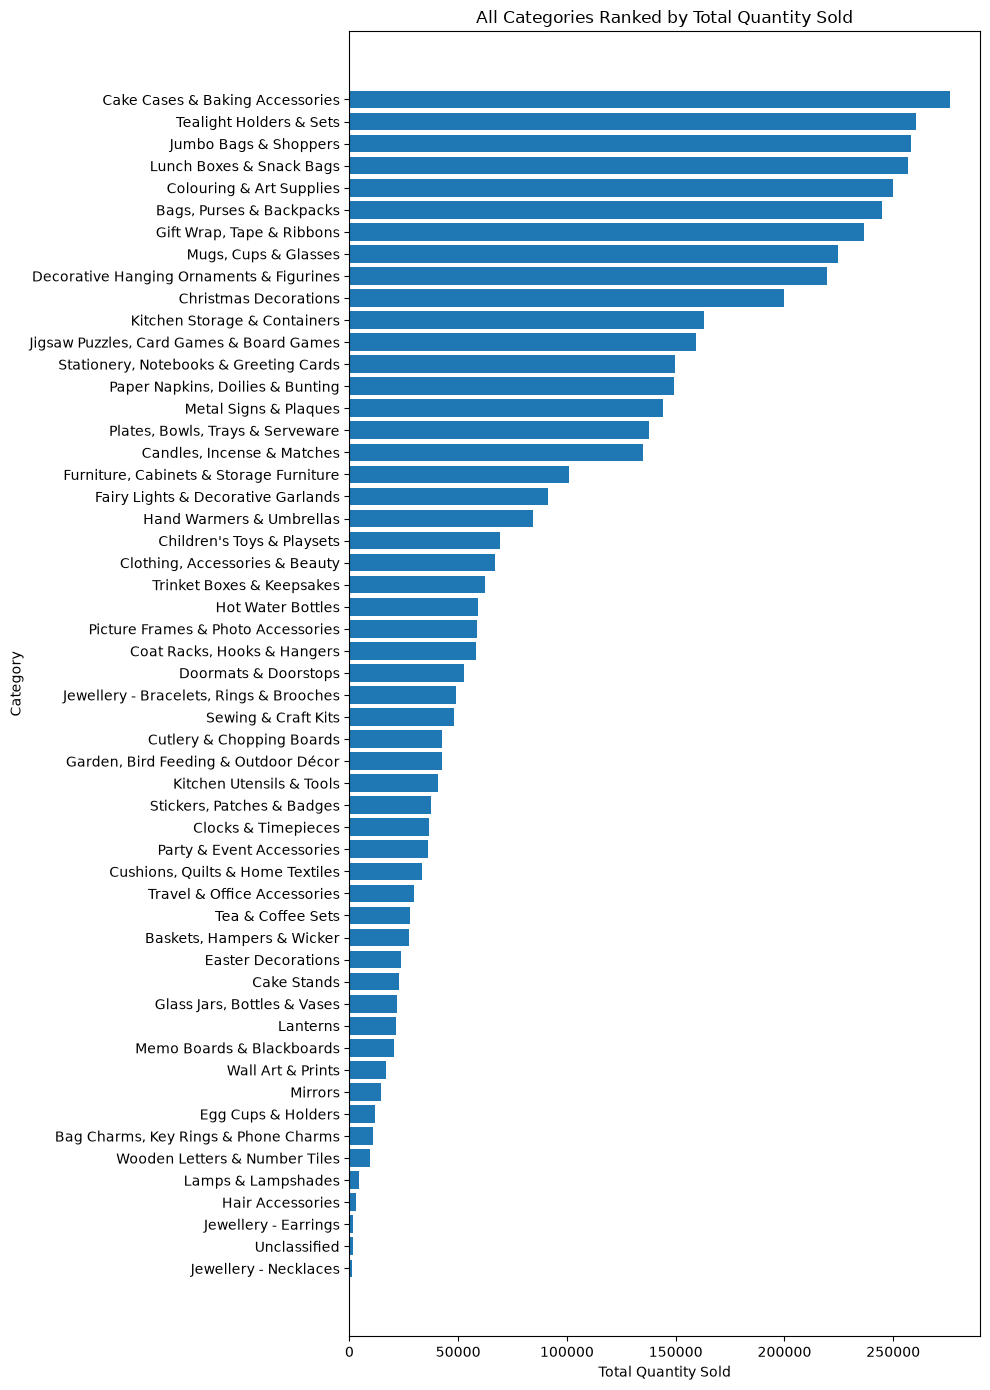

In [310]:
plt.figure(figsize=(10,14))
plt.barh( category_summary["Category"], category_summary["total_quantity"])
plt.gca().invert_yaxis()
plt.title("All Categories Ranked by Total Quantity Sold")
plt.xlabel("Total Quantity Sold")
plt.ylabel("Category")
plt.tight_layout()
plt.show()

### Interpretation

The first plot shows that **Miscellaneous** strongly dominates the dataset, with a much higher total quantity than the other categories.

However, this category is a catch-all group of heterogeneous products, so it may not represent a coherent demand pattern.

For this reason, I exclude **Miscellaneous** from the following category selection analysis and focus on more interpretable product categories.

In [18]:
daily = daily[~daily["Category"].isin(config.EXCLUDED_CATEGORIES)]
category_summary = category_summary[
    ~category_summary["Category"].isin(config.EXCLUDED_CATEGORIES)]
print(f"{daily['Category'].nunique()} categories after exclusion")

54 categories after exclusion


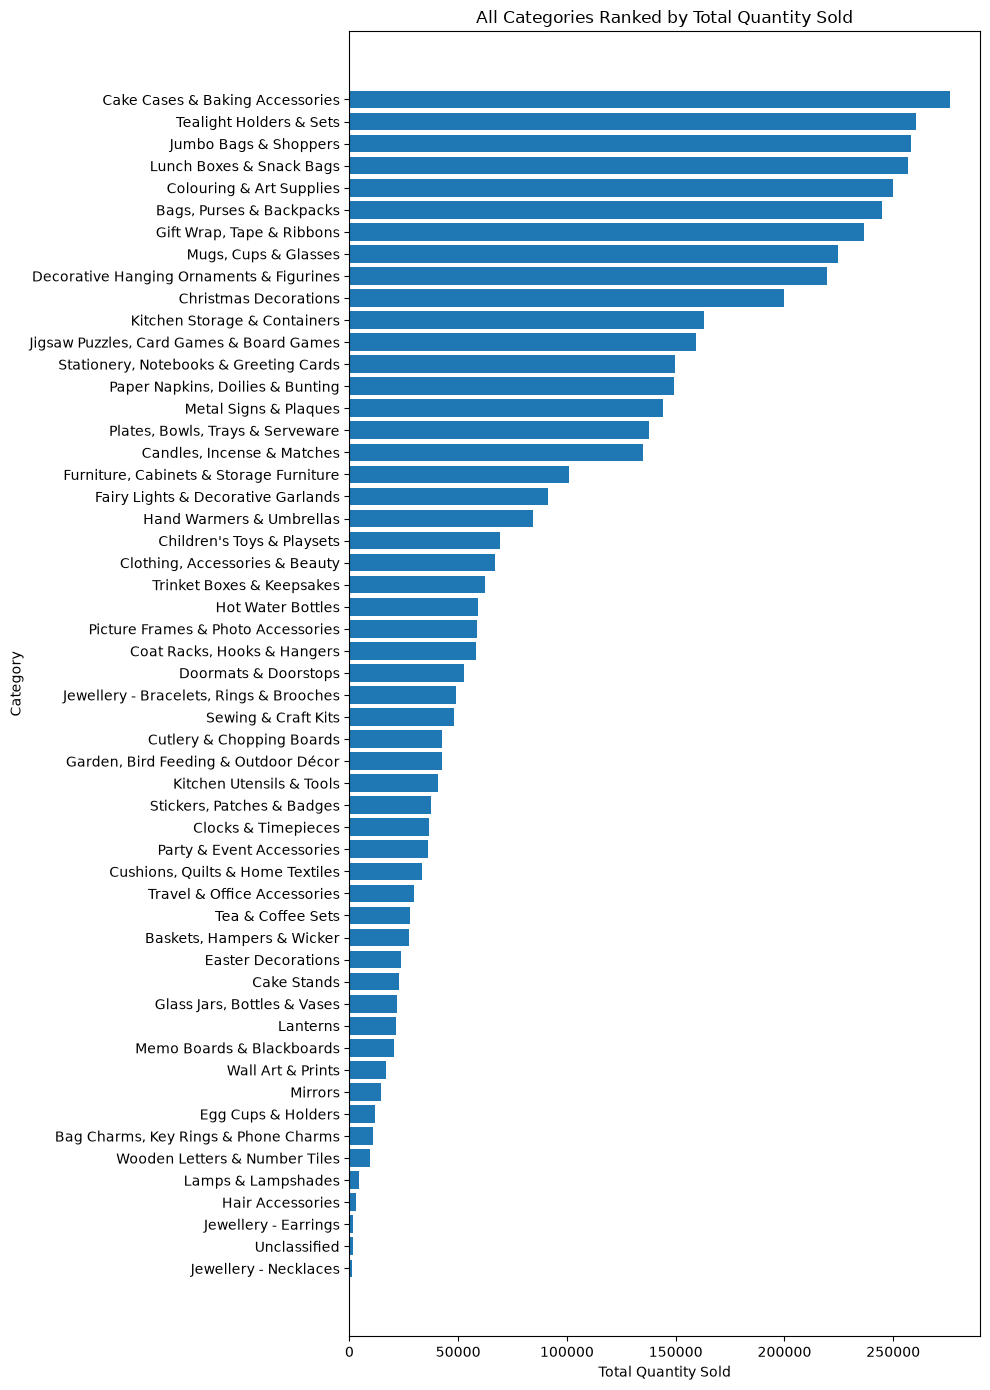

In [19]:
plt.figure(figsize=(10,14))

plt.barh(
    category_summary["Category"],
    category_summary["total_quantity"]
)

plt.gca().invert_yaxis()
plt.title("All Categories Ranked by Total Quantity Sold")
plt.xlabel("Total Quantity Sold")
plt.ylabel("Category")
plt.tight_layout()
plt.show()

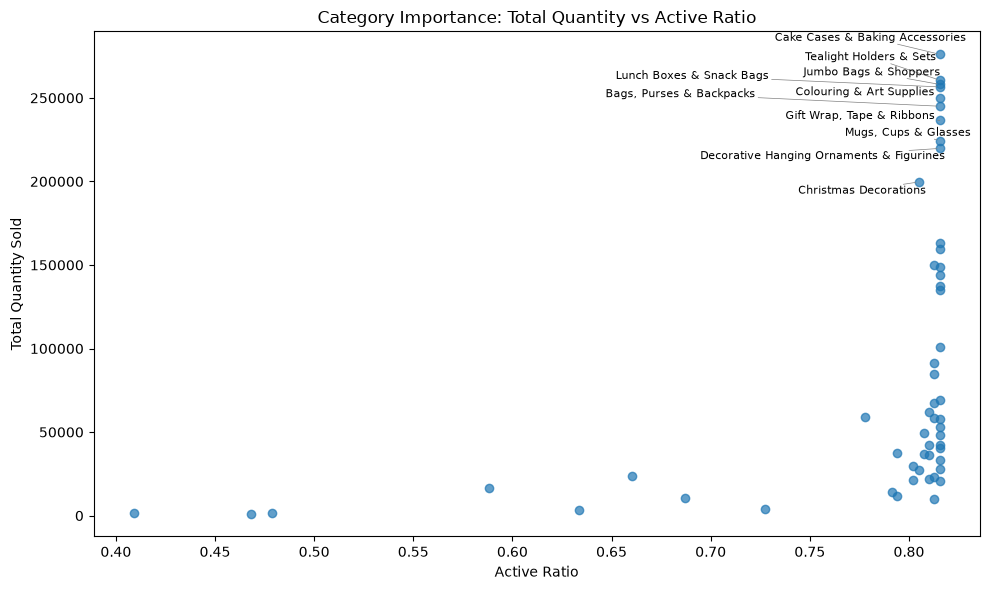

In [20]:

from adjustText import adjust_text

plt.figure(figsize=(10, 6))
plt.scatter(
    category_summary["active_ratio"],
    category_summary["total_quantity"],
    alpha=0.7
)

texts = []
for _, row in category_summary.head(10).iterrows():
    texts.append(plt.text(
        row["active_ratio"],
        row["total_quantity"],
        row["Category"],
        fontsize=8
    ))

adjust_text(texts, arrowprops=dict(arrowstyle="-", color="gray", lw=0.5))

plt.title("Category Importance: Total Quantity vs Active Ratio")
plt.xlabel("Active Ratio")
plt.ylabel("Total Quantity Sold")
plt.tight_layout()
plt.show()

The scatter plot confirms that most high-volume categories cluster 
around an active ratio of 0.81 — meaning they sell on approximately 
81% of all days. These are the most suitable candidates for 
single-category forecasting models.

Categories in the bottom-left corner (active ratio < 0.65) are 
sparse and intermittent — standard regression models are less 
appropriate for these and they will be excluded from single-category 
modeling.

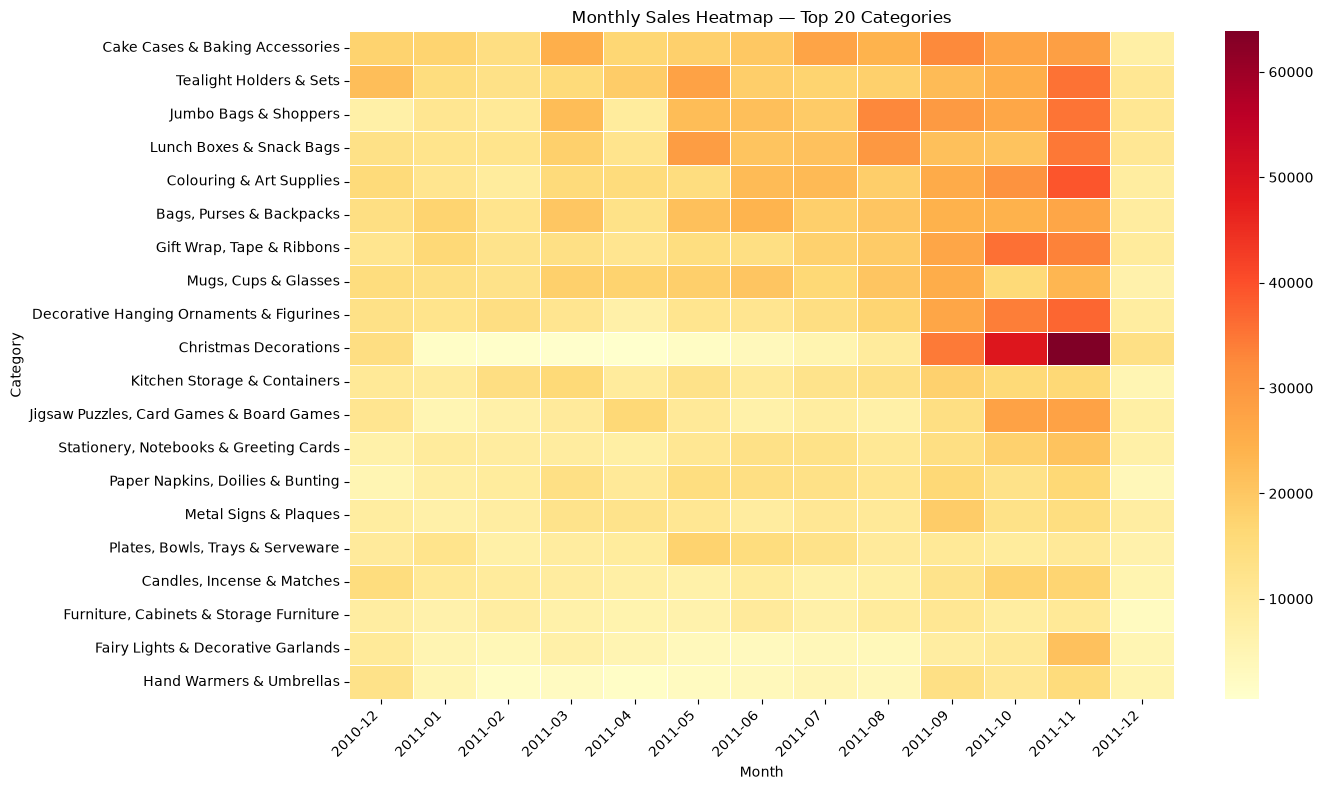

In [312]:
import seaborn as sns
top20 = category_summary.head(20)["Category"].tolist()

monthly_data = daily[daily["Category"].isin(top20)].copy()
monthly_data["Month"] = monthly_data["Date"].dt.to_period("M").dt.to_timestamp()
monthly_pivot=(monthly_data
    .pivot_table(index="Month",columns="Category",values="Quantity",aggfunc="sum")
    .fillna(0))

# Sort by total quantity
monthly_pivot = monthly_pivot[
    monthly_pivot.sum().sort_values(ascending=False).index
]

plt.figure(figsize=(14, 8))
ax = sns.heatmap(
    monthly_pivot.T,
    cmap="YlOrRd",
    linewidths=0.5
)

ax.set_xticklabels(
    [t.get_text()[:7] for t in ax.get_xticklabels()],
    rotation=45, ha="right"
)

plt.title("Monthly Sales Heatmap — Top 20 Categories")
plt.tight_layout()
plt.show()

### Interpretation
The heatmap reveals distinct seasonal behaviors across categories:
- Most top categories show stable demand year-round with a slight 
  increase toward Q4.
- **Christmas Decorations** and **Children's Toys & Playsets** show stronger activity near the end of the year, especially around the Christmas period. This suggests seasonal behavior, although sales may still occur during other months.
- **Kitchen Storage & Containers** shows an isolated spike in January 2011, 
  likely a single large bulk order rather than a seasonal pattern.


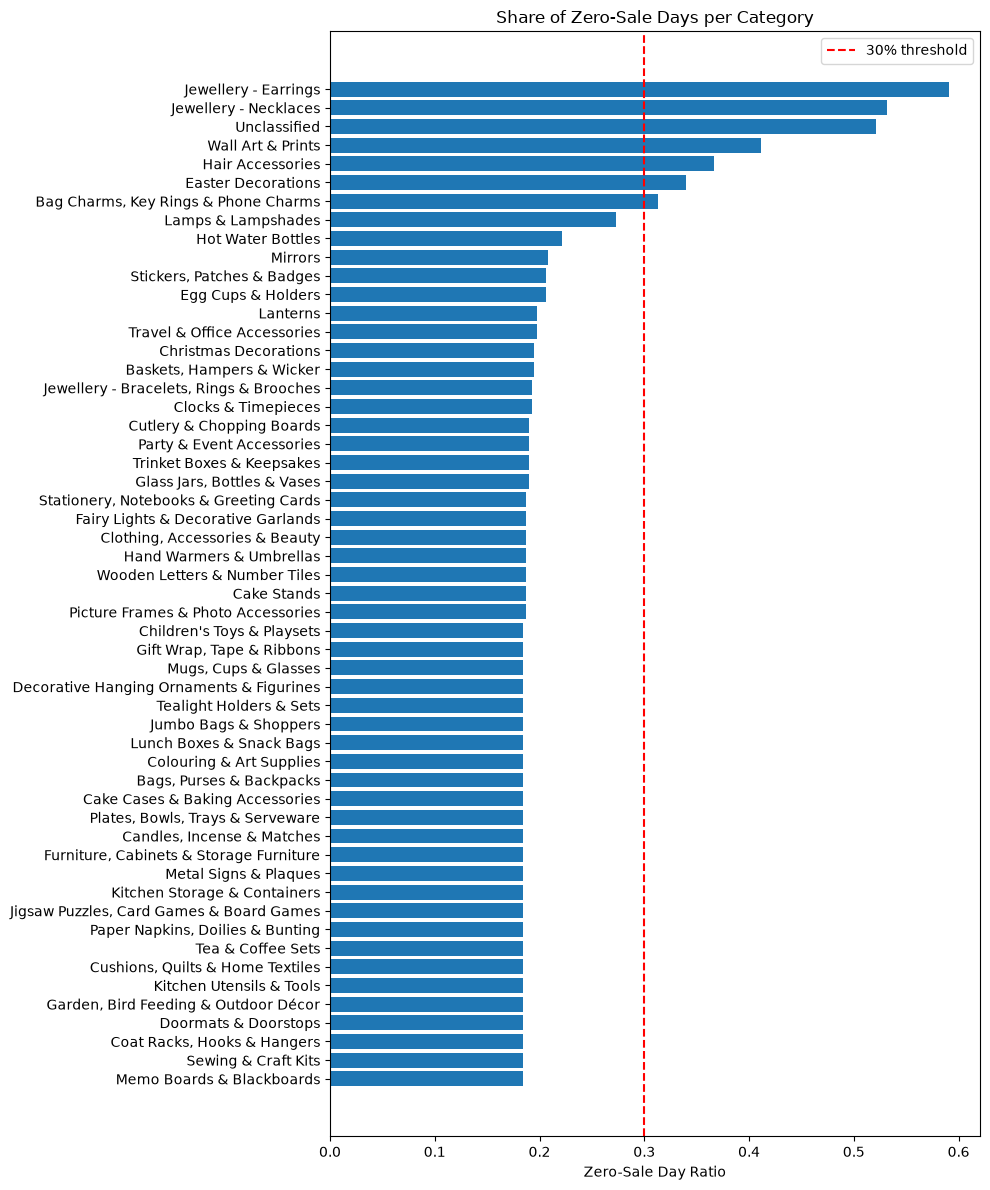

In [24]:
sparsity = category_summary.sort_values("zero_days", ascending=False)

plt.figure(figsize=(10, 12))
plt.barh(sparsity["Category"], sparsity["zero_days"] / sparsity["total_days"])
plt.gca().invert_yaxis()
plt.axvline(x=0.3, color="red", linestyle="--", label="30% threshold")
plt.title("Share of Zero-Sale Days per Category")
plt.xlabel("Zero-Sale Day Ratio")
plt.legend()
plt.tight_layout()
plt.show()

### Interpretation
Categories above the 30% threshold have too many zero-sale days 
to be reliably forecast with standard regression models. 
Jewellery categories are the most sparse (~55–60% zero-sales days).  
They are not suitable as standard forecasting candidates, but one Jewellery category is kept as an intermittent-demand stress-test case.

Categories below the threshold show regular daily sales and are 
the most suitable candidates for forecasting.

### Step 4: Category Selection

Based on total volume, active ratio, sparsity, and seasonal behavior, I select five representative categories that cover different forecasting situations:

1. **Tealight Holders & Sets** — high volume and regular demand. Good candidate for standard forecasting models.

2. **Cake Cases & Baking Accessories** — high volume and relatively stable demand. Useful as a strong baseline category.

3. **Jumbo Bags & Shoppers** — high volume but more volatile. This category tests model robustness on noisy demand.

4. **Christmas Decorations** — seasonal category with stronger activity around the end-of-year period. This tests whether models can capture seasonal behavior.

5. **Jewellery - Earrings** — sparse/intermittent category with many zero-sales days. It is included as a stress-test case, not as a standard forecasting candidate.

In [314]:
selected_categories = config.SELECTED_CATEGORIES
selected_data = daily[daily["Category"].isin(selected_categories)].copy()
print(f"Selected {len(selected_categories)} categories")
for c in selected_categories:
    print(" ", c)
print(f"Rows: {len(selected_data)}")

Selected 5 categories
  Tealight Holders & Sets
  Cake Cases & Baking Accessories
  Jumbo Bags & Shoppers
  Christmas Decorations
  Jewellery - Earrings
Rows: 1870


### Step 5: Time Series Visualization of Selected Categories

We plot the daily sales for each selected category to visually inspect 
their behavior before modeling.

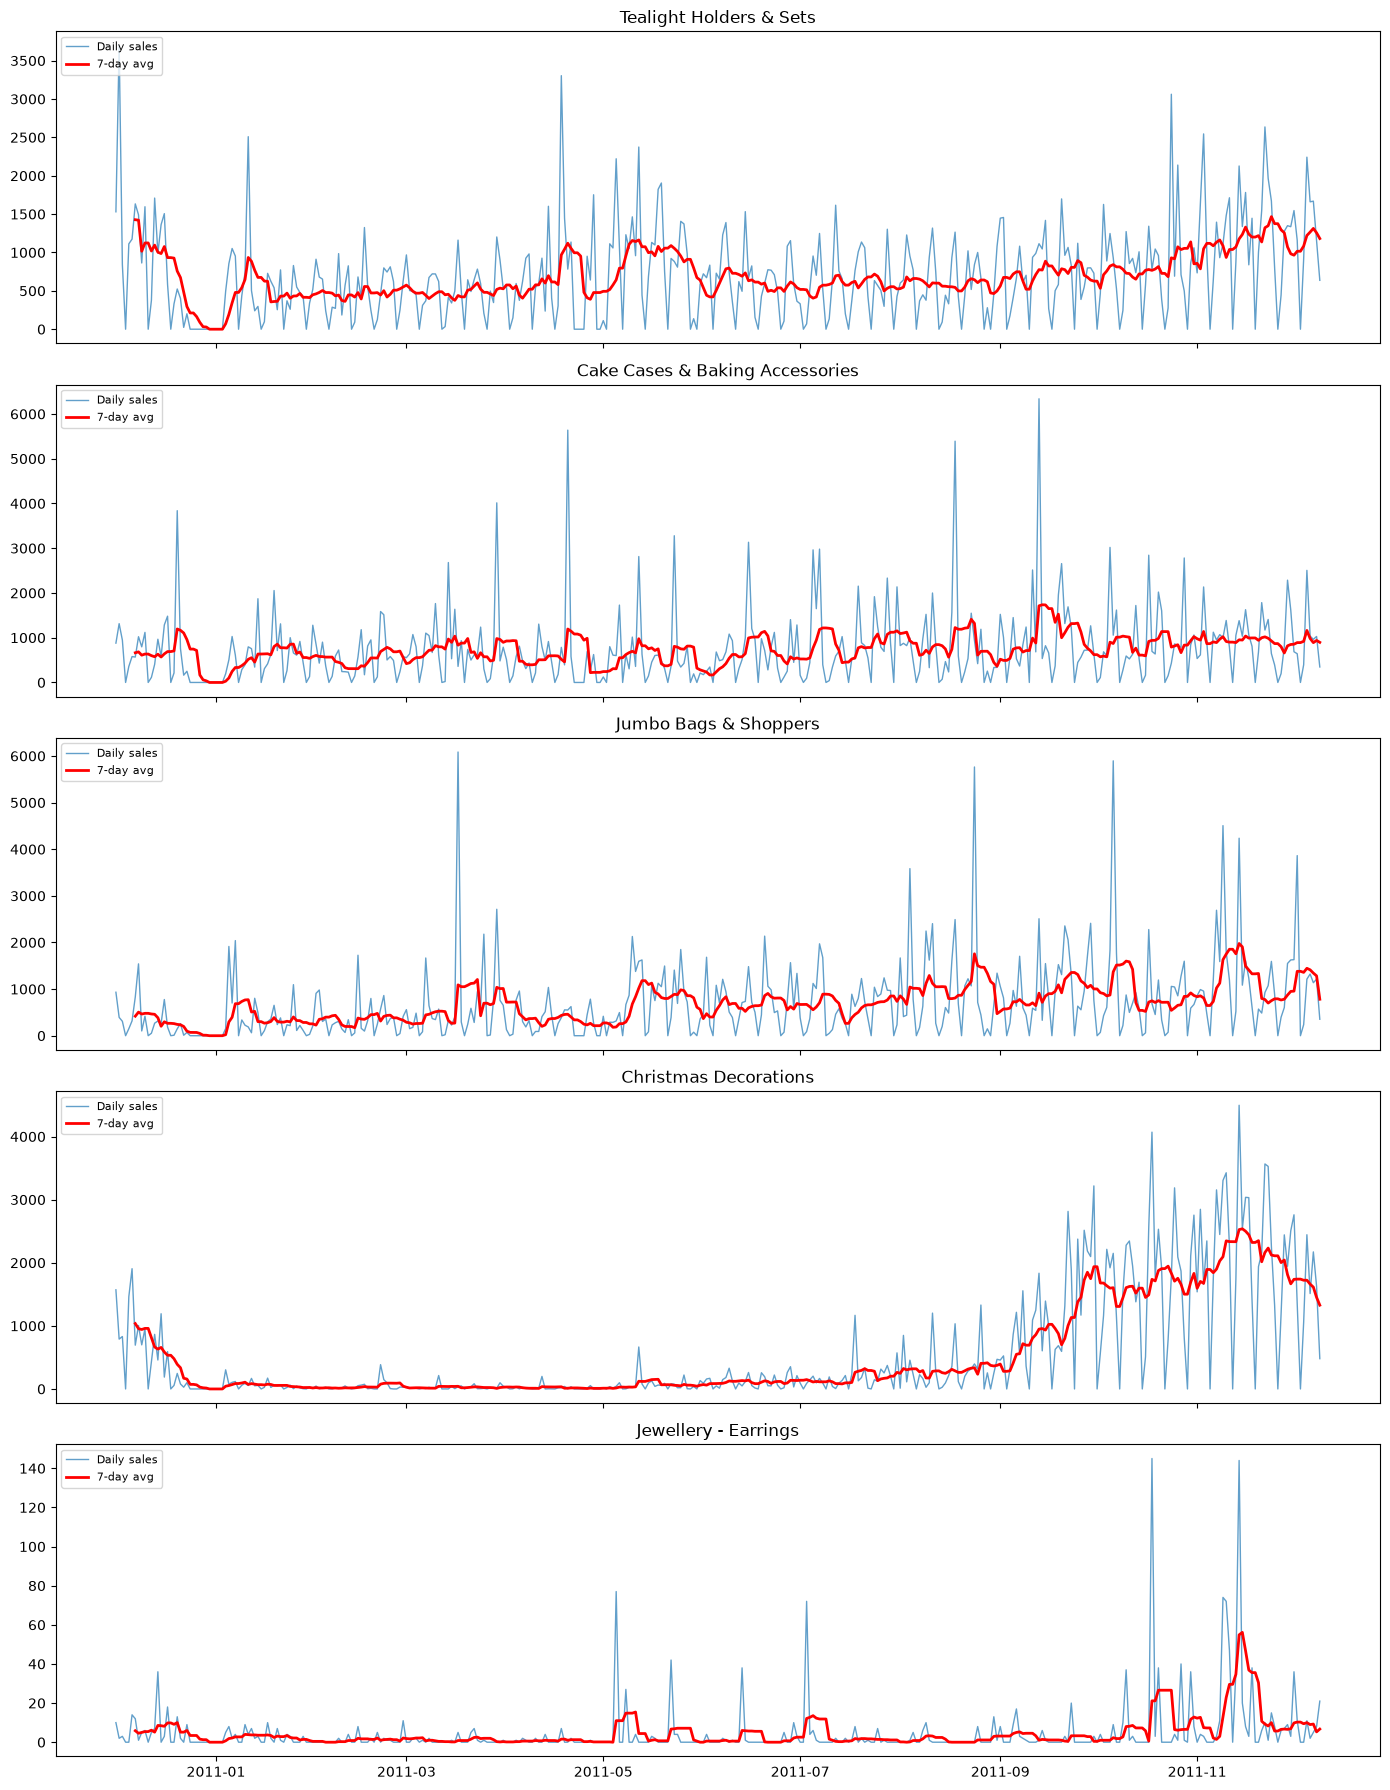

In [316]:
fig, axes = plt.subplots(5, 1, figsize=(14, 18), sharex=True)
for ax, cat in zip(axes, selected_categories):
    s = selected_data[selected_data["Category"] == cat].set_index("Date")["Quantity"].sort_index()
    ax.plot(s.index, s.values, lw=1, alpha=0.7, label="Daily sales")
    ax.plot(s.index, s.rolling(7).mean(), lw=2, color="red", label="7-day avg")
    ax.set_title(cat)
    ax.legend(loc="upper left", fontsize=8)

plt.tight_layout()
plt.show()

### Interpretation of Selected Category Time Series

The selected categories show different demand behaviors.

**Tealight Holders & Sets** and **Cake Cases & Baking Accessories** have frequent sales with visible fluctuations. These categories are suitable for standard forecasting models such as SARIMA, Random Forest, and XGBoost.

**Jumbo Bags & Shoppers** has high sales volume but appears more volatile, with several sales spikes. This category can be used to test whether the models handle noisy demand patterns.

**Christmas Decorations** shows stronger seasonal behavior, especially near the end of the year. This category may require seasonal features or seasonal time series models.

**Jewellery - Earrings** is much sparser, with many zero-sales days. This category may be difficult for standard regression models and may require a different forecasting approach.

Overall, these five categories provide a useful set of forecasting cases: regular demand, volatile demand, seasonal demand, and intermittent demand.

### Step 6: Explore Time Series Outcomes and Correlations

In this step, I analyze whether the selected category outcomes move together over time.

The objective is to understand whether some categories have similar demand patterns, common seasonal behavior, or correlated sales movements.

This can help decide whether categories should be modeled separately, grouped together, or enriched with cross-category features.

In [32]:
## Create pivot table 
selected_daily = daily[daily["Category"].isin(selected_categories)].copy()

category_pivot = (
    selected_daily
    .pivot_table(
        index="Date",
        columns="Category",
        values="Quantity",
        aggfunc="sum"
    )
    .fillna(0)
)

category_pivot.head()

Category,Cake Cases & Baking Accessories,Christmas Decorations,Jewellery - Earrings,Jumbo Bags & Shoppers,Tealight Holders & Sets
Date,,,,,
2010-12-01,879,1571,10,932,1530
2010-12-02,1314,790,2,393,3697
2010-12-03,946,831,3,309,841
2010-12-04,0,0,0,0,0
2010-12-05,359,1462,0,150,1112


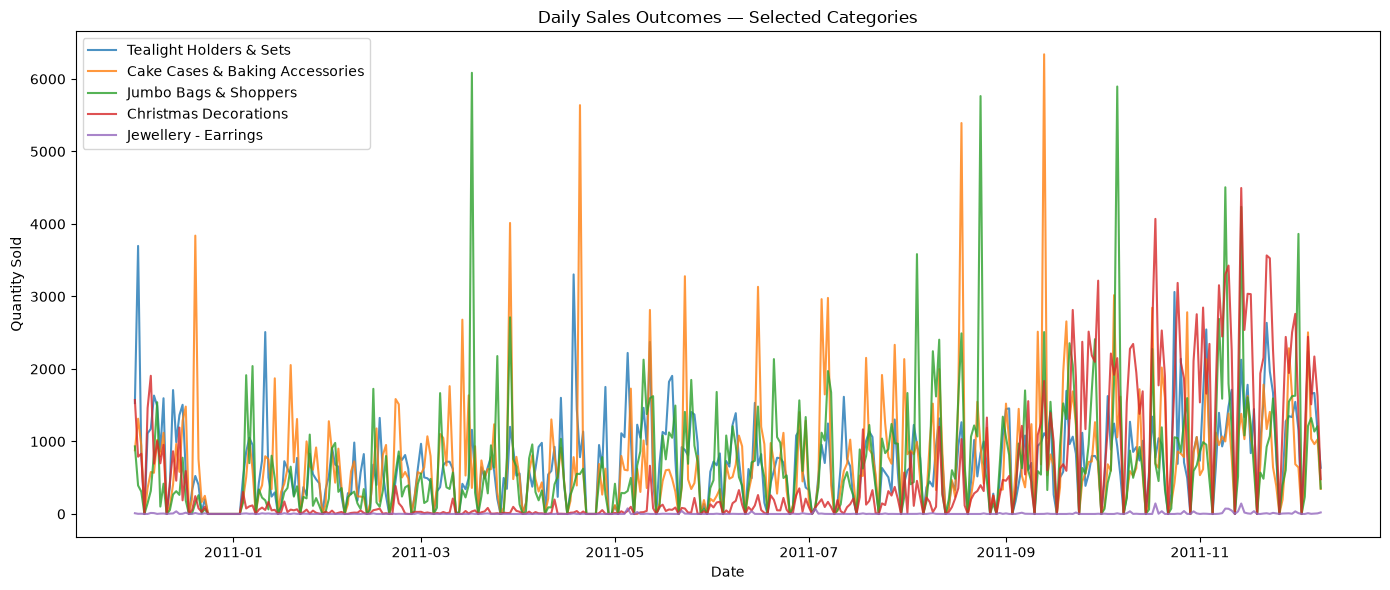

In [33]:
## Plot selected category outcomes together
plt.figure(figsize=(14, 6))

for category in selected_categories:
    plt.plot(
        category_pivot.index,
        category_pivot[category],
        label=category,
        alpha=0.8
    )

plt.title("Daily Sales Outcomes — Selected Categories")
plt.xlabel("Date")
plt.ylabel("Quantity Sold")
plt.legend()
plt.tight_layout()
plt.show()

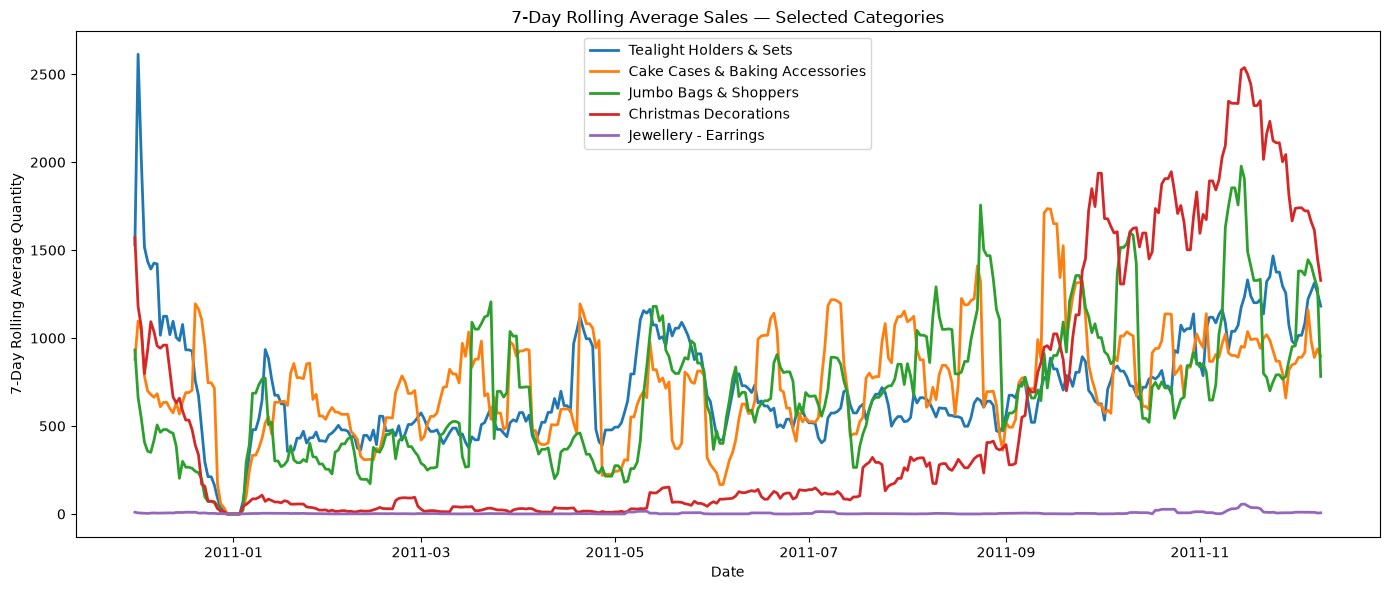

In [318]:
## Plot 7-day rolling average together
rolling_category_pivot = category_pivot.rolling(7, min_periods=1).mean()
plt.figure(figsize=(14, 6))
for category in selected_categories:
    plt.plot(
        rolling_category_pivot.index,
        rolling_category_pivot[category],
        label=category,
        linewidth=2
    )

plt.title("7-Day Rolling Average Sales — Selected Categories")
plt.xlabel("Date")
plt.ylabel("7-Day Rolling Average Quantity")
plt.legend()
plt.tight_layout()
plt.show()

In [320]:
## Correlation Matrix
category_corr = category_pivot.corr()
category_corr

Category,Cake Cases & Baking Accessories,Christmas Decorations,Jewellery - Earrings,Jumbo Bags & Shoppers,Tealight Holders & Sets
Category,,,,,
Cake Cases & Baking Accessories,1.000000,0.287396,0.057625,0.412027,0.408385
Christmas Decorations,0.287396,1.000000,0.452089,0.403666,0.479145
Jewellery - Earrings,0.057625,0.452089,1.000000,0.227847,0.228917
Jumbo Bags & Shoppers,0.412027,0.403666,0.227847,1.000000,0.420946
Tealight Holders & Sets,0.408385,0.479145,0.228917,0.420946,1.000000


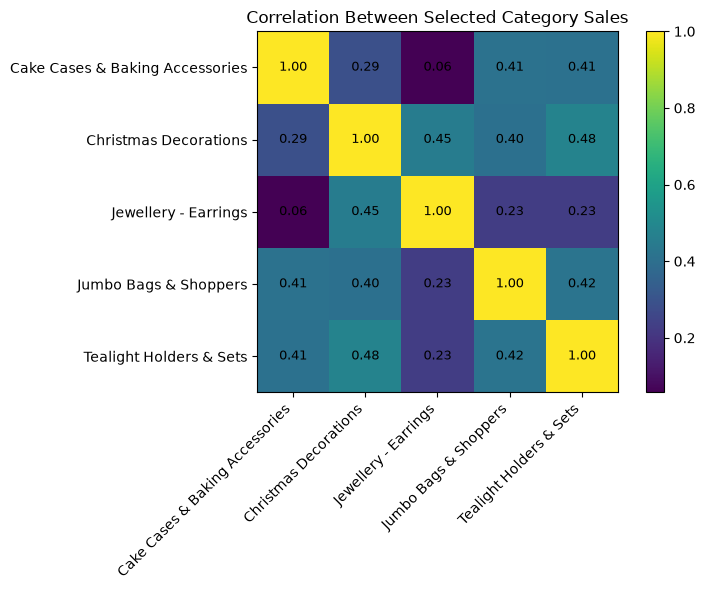

In [322]:
## Correlation Heatmap
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(category_corr.values)
ax.set_xticks(range(len(category_corr.columns)))
ax.set_yticks(range(len(category_corr.index)))
ax.set_xticklabels(category_corr.columns, rotation=45, ha="right")
ax.set_yticklabels(category_corr.index)
for i in range(len(category_corr.index)):
    for j in range(len(category_corr.columns)):
        ax.text(j, i, f"{category_corr.values[i, j]:.2f}",ha="center", va="center", fontsize=9)
plt.colorbar(im, ax=ax)
ax.set_title("Correlation Between Selected Category Sales")
plt.tight_layout()
plt.show()

### Interpretation

The selected categories show different sales behaviors over time.

The daily time series plot shows that some categories have regular demand, while others are more volatile or sparse. The 7-day rolling average helps smooth short-term fluctuations and makes the global sales patterns easier to compare.

The correlation matrix shows that the selected categories are not strongly correlated overall. Most correlations are low to moderate, which means that the categories do not always increase or decrease together.

This supports the decision to build separate forecasting models for each category instead of using only one global model.

Some moderate correlations may indicate shared demand periods, common seasonality, or similar customer behavior. However, the correlations are not strong enough to assume that all categories follow the same sales pattern.

---

## From exploration to modelling

The five categories above are carried forward. An earlier version of this
notebook continued here with a full modelling pass using a **chronological**
train/validation/test split.

That pass has been removed. `03_split_strategy.ipynb` compares four split
strategies across all 54 categories and shows the chronological split yields
positive R² in only **2 of 54** — the test period falls on a season the model
has never seen, and one year of data provides no second example of it. Results
obtained under that split are not interpretable, so keeping them would have
meant publishing conclusions drawn from a method the project itself rejects.

What follows uses the **stratified block split** selected in
`03_split_strategy.ipynb`, and reports uncertainty across repeated draws
rather than a single split.

## Step 7: Dataset preparation

`build_features` creates the target — total units sold over the next X days,
starting Y days ahead — together with lags, rolling statistics, calendar and
holiday features. Rolling windows are shifted by one day before the window is
applied, so today's quantity never enters a feature describing today.

Holiday features are included: `is_holiday`,
`number_of_holidays_in_target_window` and `holiday_in_target_window`. Their
usefulness is assessed below through mutual information ranking rather than
assumed.

In [40]:
X, Y = 7, 7
target_col = config.target_name(X, Y)

datasets = {cat: feat.build_features(daily, cat, X=X, Y=Y)
            for cat in selected_categories}
features = feat.available_features(next(iter(datasets.values())))

for cat, d in datasets.items():
    print(f"{cat:35s} {len(d):4d} rows")
print(f"\n{len(features)} features, target = {target_col}")

Tealight Holders & Sets              333 rows
Cake Cases & Baking Accessories      333 rows
Jumbo Bags & Shoppers                333 rows
Christmas Decorations                333 rows
Jewellery - Earrings                 333 rows

30 features, target = target_X7_Y7


## Step 8: Split

The stratified block split orders 14-day blocks by mean demand before dealing
them out, so each split receives a comparable share of high- and low-season
weeks. See `03_split_strategy.ipynb` Step 9 for why this matters: without it,
validation WAPE on Christmas Decorations ranged from 17% to 209% depending
only on the seed.

In [42]:
splits = {cat: spl.stratified_block_split(d, target_col, random_state=42)
          for cat, d in datasets.items()}

for cat, s in splits.items():
    sizes = {k: len(v) for k, v in s.items()}
    print(f"{cat:35s} {sizes}  leakage {spl.leakage_ratio(s, X):.0%}")

Tealight Holders & Sets             {'train': 238, 'validation': 53, 'test': 42}  leakage 57%
Cake Cases & Baking Accessories     {'train': 235, 'validation': 56, 'test': 42}  leakage 71%
Jumbo Bags & Shoppers               {'train': 238, 'validation': 53, 'test': 42}  leakage 57%
Christmas Decorations               {'train': 235, 'validation': 56, 'test': 42}  leakage 57%
Jewellery - Earrings                {'train': 235, 'validation': 56, 'test': 42}  leakage 71%


## Step 9: Model comparison on one split

Four models per category: the 7-day rolling sum baseline, Linear Regression,
Random Forest and XGBoost.

The baseline deserves a word. The target is cumulative demand over the next
seven days; using the cumulative demand of the *previous* seven days is the
simplest forecast that is methodologically consistent with it, and any model
that fails to beat it is not earning its complexity.

In [44]:
rows = []
for cat, s in splits.items():
    res, _ = pipe.train_all_models(s, features, target_col)
    res.insert(0, "Category", cat)
    rows.append(res)

all_results = pd.concat(rows, ignore_index=True)
all_results[["Category", "Model", "Validation WAPE (%)", "Validation R2",
             "Test WAPE (%)", "Test R2"]]

,Category,Model,Validation WAPE (%),Validation R2,Test WAPE (%),Test R2
0,Tealight Holders & Sets,7-Day Rolling Sum Baseline,15.813,0.702,42.482,-1.171
1,Tealight Holders & Sets,Linear Regression,15.389,0.757,31.024,-0.178
2,Tealight Holders & Sets,Random Forest,15.596,0.689,22.657,0.300
3,Tealight Holders & Sets,XGBoost,17.032,0.610,24.904,0.218
4,Cake Cases & Baking Accessories,7-Day Rolling Sum Baseline,38.295,-0.442,33.866,-1.932
5,Cake Cases & Baking Accessories,Linear Regression,42.440,-0.634,34.654,-2.050
6,Cake Cases & Baking Accessories,Random Forest,29.706,0.146,20.725,-0.281
7,Cake Cases & Baking Accessories,XGBoost,30.916,0.071,24.603,-0.661
8,Jumbo Bags & Shoppers,7-Day Rolling Sum Baseline,33.961,0.181,68.139,-1.361
9,Jumbo Bags & Shoppers,Linear Regression,35.182,0.189,56.178,-0.777


### Interpretation

Read the validation and test columns together, not separately.

The model with the lowest validation WAPE is frequently not the one with the
lowest test WAPE. That is not an accident of these five categories: measured
across all 54, validation-based selection identifies the test winner in only
**13 of 54 cases (24%)**, against ~25% expected by choosing at random among
four models. See `RESULTS_54_AND_TABFM.md`.

The reason is visible in the numbers themselves — the top models are typically
separated by less than one WAPE point on validation, while the seed-to-seed
standard deviation on the same category is several points. A single split
cannot resolve a difference that small.

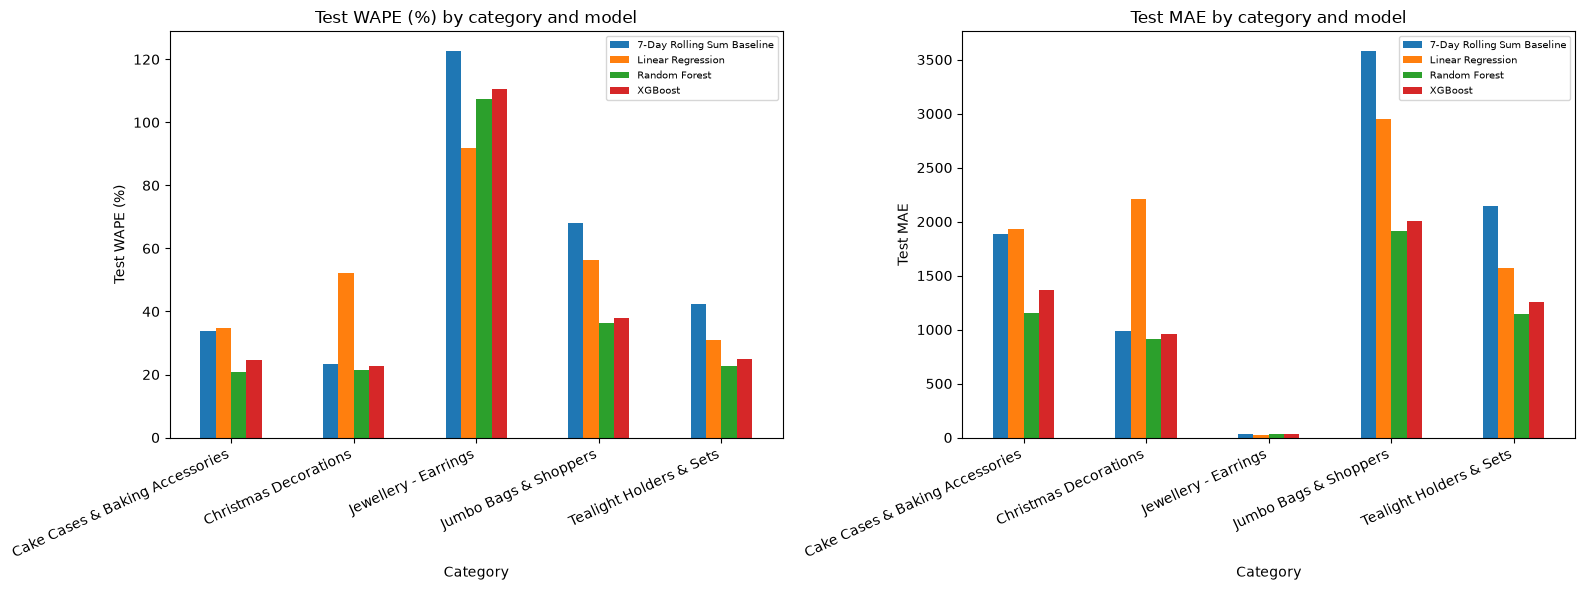

Spearman rank correlation, WAPE vs MAE, per category:
  Tealight Holders & Sets             +1.00
  Cake Cases & Baking Accessories     +1.00
  Jumbo Bags & Shoppers               +1.00
  Christmas Decorations               +1.00
  Jewellery - Earrings                +1.00


In [46]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, metric in zip(axes, ["Test WAPE (%)", "Test MAE"]):
    pv = all_results.pivot(index="Category", columns="Model", values=metric)
    pv.plot(kind="bar", ax=ax)
    ax.set_ylabel(metric)
    ax.set_title(f"{metric} by category and model")
    ax.set_xticklabels(pv.index, rotation=25, ha="right")
    ax.legend(fontsize=7)

plt.tight_layout()
plt.show()

print("Spearman rank correlation, WAPE vs MAE, per category:")
for cat in selected_categories:
    sub = all_results[all_results["Category"] == cat]
    r = sub["Test WAPE (%)"].corr(sub["Test MAE"], method="spearman")
    print(f"  {cat:35s} {r:+.2f}")

### Why both metrics are shown

The Spearman correlation is +1.00 for every category, and that is expected
rather than reassuring. Within one category on one split, all four models are
evaluated on the same test rows, so WAPE's denominator is identical for all of
them and `WAPE = MAE x n / denominator` is a constant multiple of MAE. The two
metrics cannot disagree on the ranking here.

That answers the question directly: MAE does not change which model looks best
within a category. Where WAPE and MAE do diverge is in the two comparisons that
actually depend on the denominator.

**Across splits.** Re-drawing the split changes which rows are evaluated, and
therefore the denominator. Measured across 30 seeds on Christmas Decorations,
WAPE correlates -0.587 with the evaluation set's denominator while MAE
correlates +0.863 — on identical predictions.

**Across categories.** A high-volume category has a large denominator and
therefore a lower WAPE at equal forecast quality. Comparing WAPE between
Jewellery - Earrings and Jumbo Bags & Shoppers is not comparing forecast
quality.

Both are reported because they answer different questions. WAPE is scale-free,
which is why it was chosen for cross-category summaries; that same property
makes it sensitive to the composition of the evaluation window. MAE is in units
and is what a stock planner acts on, but cannot be averaged across categories
of different size.

The R2 shown in the forecast plots below is the third piece: a model can reach
a moderate WAPE while explaining none of the day-to-day variation, simply by
predicting close to the mean.

## Step 10: The same comparison with uncertainty

The chart above ranks models on one draw. This re-runs the comparison across
30 stratified draws and reports the distribution.

`win_rate` is the fraction of draws in which each model came first. A model
winning 40% of draws is not "the best model for this category" — it is the one
that happened to win a single draw.

In [49]:
repeats = []
for cat in selected_categories:
    print("running", cat)
    repeats.append(val.repeated_evaluation(daily, cat, X=X, Y=Y,
                                           seeds=range(30), stratified=True))

rep = pd.concat(repeats, ignore_index=True)
rep.to_csv(config.RESULTS / "modeling_repeated_raw.csv", index=False)
val.summarise_repeats(rep)

running Tealight Holders & Sets
running Cake Cases & Baking Accessories
running Jumbo Bags & Shoppers
running Christmas Decorations
running Jewellery - Earrings


,Category,Model,wape_mean,wape_std,wape_min,wape_max,r2_mean,win_rate
2,Cake Cases & Baking Accessories,Random Forest,31.855,4.441,22.946,39.604,0.113,0.500
3,Cake Cases & Baking Accessories,XGBoost,32.722,4.331,24.317,42.309,0.029,0.333
1,Cake Cases & Baking Accessories,Linear Regression,34.683,4.271,25.125,42.440,-0.048,0.167
0,Cake Cases & Baking Accessories,7-Day Rolling Sum Baseline,50.308,7.403,38.295,63.818,-1.096,0.000
4,Christmas Decorations,7-Day Rolling Sum Baseline,22.504,4.566,16.904,31.272,0.906,0.700
7,Christmas Decorations,XGBoost,29.220,6.712,16.426,40.482,0.874,0.067
6,Christmas Decorations,Random Forest,29.816,9.542,18.296,56.114,0.873,0.233
5,Christmas Decorations,Linear Regression,48.813,18.236,26.411,91.543,0.676,0.000
11,Jewellery - Earrings,XGBoost,76.285,7.188,62.683,90.187,0.132,0.533
10,Jewellery - Earrings,Random Forest,76.510,5.957,65.050,87.392,0.168,0.433


### Paired comparison

`is_difference_meaningful` compares two models on the **same** 30 draws. The
pairing removes the split-to-split variation that dominates the absolute
numbers, so what remains is the difference attributable to the models.

If the confidence interval crosses zero, the two are indistinguishable on this
dataset and no claim should be made either way.

In [51]:
verdicts = []
for cat in selected_categories:
    sub = rep[rep["Category"] == cat]
    for a, b in [("Random Forest", "7-Day Rolling Sum Baseline"),
                 ("XGBoost", "Random Forest"),
                 ("Linear Regression", "Random Forest")]:
        d = val.is_difference_meaningful(sub, a, b)
        decided = (d["ci_low"] < 0) == (d["ci_high"] < 0)
        verdicts.append({
            "Category": cat, "A": a, "B": b,
            "mean_diff": d["mean_diff"],
            "ci_low": d["ci_low"], "ci_high": d["ci_high"],
            "A_wins_%": d["a_better_pct"],
            "verdict": ("A better" if decided and d["mean_diff"] < 0
                        else "B better" if decided else "within noise"),
        })

pd.DataFrame(verdicts)

,Category,A,B,mean_diff,ci_low,ci_high,A_wins_%,verdict
0,Tealight Holders & Sets,Random Forest,7-Day Rolling Sum Baseline,-5.476,-7.789,-3.162,86.7,A better
1,Tealight Holders & Sets,XGBoost,Random Forest,0.599,0.000,1.198,36.7,B better
2,Tealight Holders & Sets,Linear Regression,Random Forest,8.032,6.126,9.937,6.7,B better
3,Cake Cases & Baking Accessories,Random Forest,7-Day Rolling Sum Baseline,-18.452,-20.851,-16.054,100.0,A better
4,Cake Cases & Baking Accessories,XGBoost,Random Forest,0.867,-0.269,2.002,36.7,within noise
5,Cake Cases & Baking Accessories,Linear Regression,Random Forest,2.828,1.610,4.046,23.3,B better
6,Jumbo Bags & Shoppers,Random Forest,7-Day Rolling Sum Baseline,-6.280,-9.285,-3.275,76.7,A better
7,Jumbo Bags & Shoppers,XGBoost,Random Forest,1.515,0.603,2.427,23.3,B better
8,Jumbo Bags & Shoppers,Linear Regression,Random Forest,-5.373,-8.354,-2.392,66.7,A better
9,Christmas Decorations,Random Forest,7-Day Rolling Sum Baseline,7.312,3.417,11.208,30.0,B better


### What survives

Compare this table with the single-split chart above. Several apparent
differences do not survive the paired test, and at least one reverses.

This is the notebook's main methodological point: **a ranking produced by one
split is not a result.** Reporting a model as best for a category requires
showing that it wins consistently, not that it won once.

## Step 11: Feature relevance

Mutual information is estimated on the **training split only**, so that the
ranking cannot borrow information from validation or test.

In [324]:
mi_rank = {}
for cat, s in splits.items():
    top = pipe.select_features(s["train"], features, target_col, n_features=len(features))
    mi_rank[cat] = top

pd.DataFrame({c: v[:10] for c, v in mi_rank.items()})

,Tealight Holders & Sets,Cake Cases & Baking Accessories,Jumbo Bags & Shoppers,Christmas Decorations,Jewellery - Earrings
0,month,rolling_max_14,month,rolling_max_14,rolling_std_28
1,rolling_max_28,rolling_max_7,rolling_mean_14,rolling_max_7,month
2,rolling_max_14,rolling_mean_28,rolling_mean_28,rolling_max_28,rolling_std_14
3,rolling_std_28,rolling_max_28,weekly_mean_2,rolling_std_14,rolling_max_28
4,rolling_std_14,month,rolling_max_28,rolling_mean_28,rolling_max_14
5,rolling_mean_28,rolling_std_28,rolling_max_14,rolling_std_28,rolling_mean_14
6,rolling_mean_14,rolling_std_7,weekly_mean_3,rolling_std_7,rolling_mean_28
7,rolling_max_7,rolling_mean_7,rolling_std_14,rolling_mean_14,rolling_std_7
8,rolling_std_7,rolling_mean_14,rolling_max_7,month,rolling_max_7
9,weekly_mean_2,rolling_std_14,weekly_mean_4,rolling_mean_7,weekly_mean_4


### Interpretation

Rolling statistics dominate: rolling means, standard deviations and maxima
consistently rank above individual daily lags. Aggregated recent demand
carries more information than any single previous day.

`month` also ranks highly for most categories, consistent with the seasonal
patterns visible in Step 3.

The ordering differs across categories, which is often taken as an argument
for category-specific feature selection. Given the selection results in
Step 10, treat that argument with caution: differences in ranking between
categories may reflect estimation noise on ~230 training rows rather than
genuine differences in what matters.

## Step 12: Forecast horizon (X) and lead time (Y)

A caveat has to come before any result here.

**WAPE is not comparable across different values of X.** WAPE is
`sum|error| / sum|actual|`. Widening the forecast window grows the denominator
roughly linearly in X, while daily errors partly cancel and grow more slowly.
WAPE therefore tends to fall as X increases regardless of whether the forecast
improved. Choosing X by minimising WAPE will favour the longest window tested
as a property of the metric, not as a finding about the data.

`build_features` also drops the last X+Y rows, so a larger X leaves fewer
usable rows: at X=28 roughly 310 remain, giving 22 blocks of which validation
receives about three. The scans below are therefore run across 10 seeds with
the standard deviation reported. A single-seed version of this scan was not
monotonic at all — Christmas Decorations went from 4.84 at X=21 to 39.62 at
X=28 — and could not have distinguished a trend from noise.

In [326]:
# Step 12.0 — Select one forecasting model per category
# based on the repeated evaluation from Step 10

rep_summary = val.summarise_repeats(rep)
candidate_models=["Linear Regression", "Random Forest", "XGBoost"]
model_selection = (
    rep_summary[rep_summary["Model"].isin(candidate_models)]
    .sort_values(["Category", "wape_mean"])
    .groupby("Category", as_index=False)
    .first()
)

model_selection = model_selection[
    ["Category", "Model", "wape_mean", "wape_std", "win_rate"]
]

best_model_by_category = dict(
    zip(model_selection["Category"], model_selection["Model"])
)

display(
    model_selection.rename(
        columns={
            "Model": "Selected Model",
            "wape_mean": "Mean WAPE (%)",
            "wape_std": "WAPE Std (%)",
            "win_rate": "Win Rate"
        }
    ).round(3)
)

print("\nSelected model by category:")

for category, model in best_model_by_category.items():
    print(f"{category:40s} -> {model}")

,Category,Selected Model,Mean WAPE (%),WAPE Std (%),Win Rate
0,Cake Cases & Baking Accessories,Random Forest,31.855,4.441,0.500
1,Christmas Decorations,XGBoost,29.220,6.712,0.067
2,Jewellery - Earrings,XGBoost,76.285,7.188,0.533
3,Jumbo Bags & Shoppers,Linear Regression,28.870,4.778,0.633
4,Tealight Holders & Sets,Random Forest,17.512,3.566,0.467



Selected model by category:
Cake Cases & Baking Accessories          -> Random Forest
Christmas Decorations                    -> XGBoost
Jewellery - Earrings                     -> XGBoost
Jumbo Bags & Shoppers                    -> Linear Regression
Tealight Holders & Sets                  -> Random Forest


In [328]:
# Step 12.1 — Effect of forecast-window length X

SEEDS_XY = range(10)
X_VALUES = [3, 7, 14, 21, 28]
FIXED_Y = 7
X_scan = []
for cat in selected_categories:
    model_name = best_model_by_category[cat]
    print(f"Running {cat} with {model_name}")
    for x in X_VALUES:
        d=feat.build_features(daily, cat, X=x, Y=FIXED_Y)
        if len(d) < 50:
            continue
            
        target = config.target_name(x, FIXED_Y)
        f = feat.available_features(d)
        wapes = []
        
        for seed in SEEDS_XY:
            s=spl.stratified_block_split(d, target, random_state=seed)
            _, val_pred, _=mdl.MODELS[model_name](s["train"], s["validation"], s["test"], f, target)
            metrics = evaluate_forecast(s["validation"][target], val_pred)
            wapes.append(metrics["wape"])
            
        s0=spl.stratified_block_split(d, target, random_state=0)

        X_scan.append({
            "Category": cat,
            "Model": model_name,
            "X": x,
            "n_rows": len(d),
            "wape_mean": np.mean(wapes),
            "wape_std": np.std(wapes),
            "denominator":
                s0["validation"][target].sum()
        })

x_df = pd.DataFrame(X_scan)
display(x_df.pivot(index="X", columns="Category", values="wape_mean").round(2))

Running Tealight Holders & Sets with Random Forest
Running Cake Cases & Baking Accessories with Random Forest
Running Jumbo Bags & Shoppers with Linear Regression
Running Christmas Decorations with XGBoost
Running Jewellery - Earrings with XGBoost


Category,Cake Cases & Baking Accessories,Christmas Decorations,Jewellery - Earrings,Jumbo Bags & Shoppers,Tealight Holders & Sets
X,,,,,
3,43.02,33.16,118.07,52.30,29.51
7,31.45,28.67,75.54,28.82,16.69
14,22.00,22.11,63.17,25.45,12.81
21,9.67,13.26,71.36,22.93,15.18
28,8.97,24.05,62.68,16.30,11.63


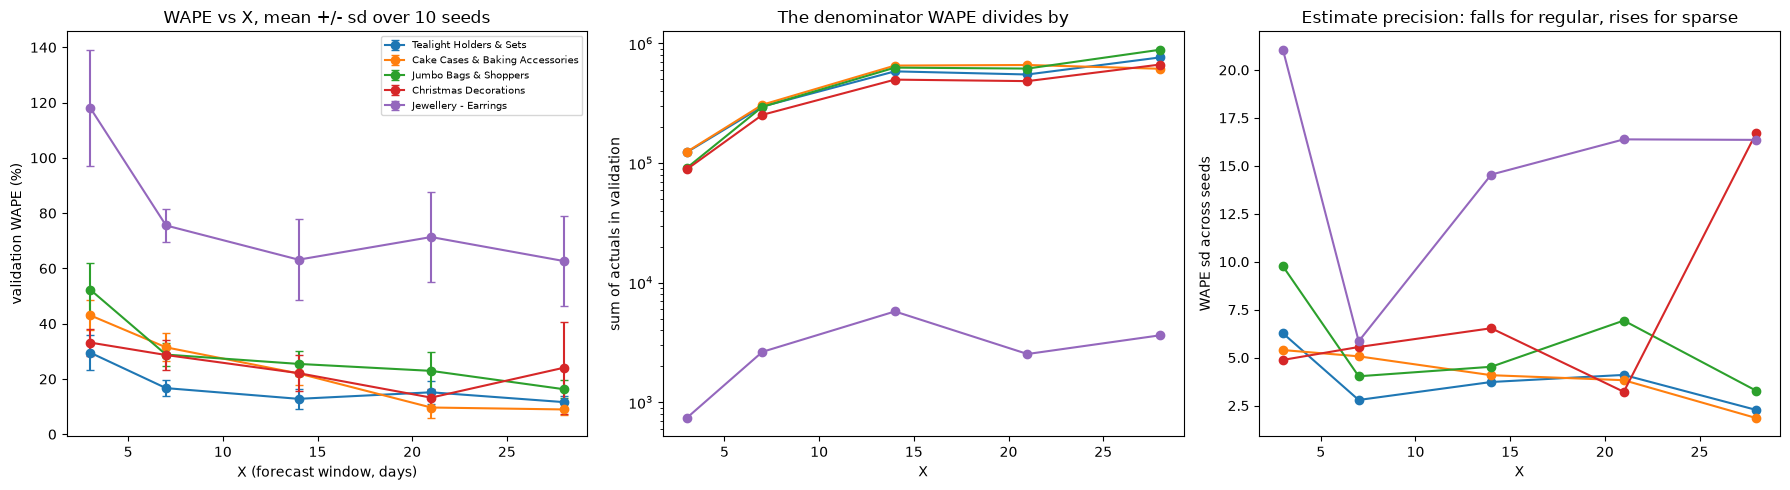

Correlation across X, per category:
  Tealight Holders & Sets             X~WAPE -0.77   X~denominator +0.95   X~sd -0.63
  Cake Cases & Baking Accessories     X~WAPE -0.96   X~denominator +0.84   X~sd -0.96
  Jumbo Bags & Shoppers               X~WAPE -0.85   X~denominator +0.96   X~sd -0.54
  Christmas Decorations               X~WAPE -0.69   X~denominator +0.95   X~sd +0.65
  Jewellery - Earrings                X~WAPE -0.73   X~denominator +0.44   X~sd +0.12


In [329]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for cat in selected_categories:
    sub = x_df[x_df["Category"] == cat]
    axes[0].errorbar(sub["X"], sub["wape_mean"], yerr=sub["wape_std"],
                     marker="o", capsize=3, label=cat)
    axes[1].plot(sub["X"], sub["denominator"], marker="o")
    axes[2].plot(sub["X"], sub["wape_std"], marker="o")

axes[0].set_xlabel("X (forecast window, days)")
axes[0].set_ylabel("validation WAPE (%)")
axes[0].set_title("WAPE vs X, mean +/- sd over 10 seeds")
axes[0].legend(fontsize=7)

axes[1].set_xlabel("X"); axes[1].set_ylabel("sum of actuals in validation")
axes[1].set_yscale("log")
axes[1].set_title("The denominator WAPE divides by")

axes[2].set_xlabel("X"); axes[2].set_ylabel("WAPE sd across seeds")
axes[2].set_title("Estimate precision: falls for regular, rises for sparse")
plt.tight_layout()
plt.show()

print("Correlation across X, per category:")
for cat in selected_categories:
    sub = x_df[x_df["Category"] == cat]
    print(f"  {cat:35s} X~WAPE {sub['X'].corr(sub['wape_mean']):+.2f}   "
          f"X~denominator {sub['X'].corr(sub['denominator']):+.2f}   "
          f"X~sd {sub['X'].corr(sub['wape_std']):+.2f}")

### Interpretation

**The denominator effect is confirmed.** Across all five categories, WAPE
correlates negatively with X (−0.63 to −0.96) while the evaluation denominator
correlates positively (+0.44 to +0.96). The two move together systematically.
Widening the forecast window inflates `sum|actual|` and mechanically deflates
WAPE, so part of the apparent improvement is arithmetic rather than
forecasting.

Note that a single-split version of this scan was not monotonic at all —
Christmas Decorations went from 4.84 at X=21 to 39.62 at X=28. Averaging over
10 seeds removed that noise and revealed the underlying trend. The single-split
scan used in an earlier version of this project could not have distinguished
the two.

**The effect on precision splits by category type.** The standard deviation
*falls* with X for Tealight, Cake Cases and Jumbo Bags (−0.63 to −0.96) and
*rises* for Christmas Decorations and Jewellery - Earrings (+0.59, +0.69).
Where demand is regular and high-volume, aggregating over a longer window
stabilises the estimate more than the loss of usable rows destabilises it. For
the strongly seasonal and the sparse categories, the opposite holds.

**What follows for X.** The trend is real but partly artefactual, and it cannot
be used to select X: minimising WAPE over X would always favour the longest
window tested. An earlier version of this project concluded that *"longer X
windows dramatically improve WAPE (Jewellery: 73% → 9.7%)"*. That conclusion is
withdrawn. X should be set by the business replenishment cycle, with
performance then reported at that X.

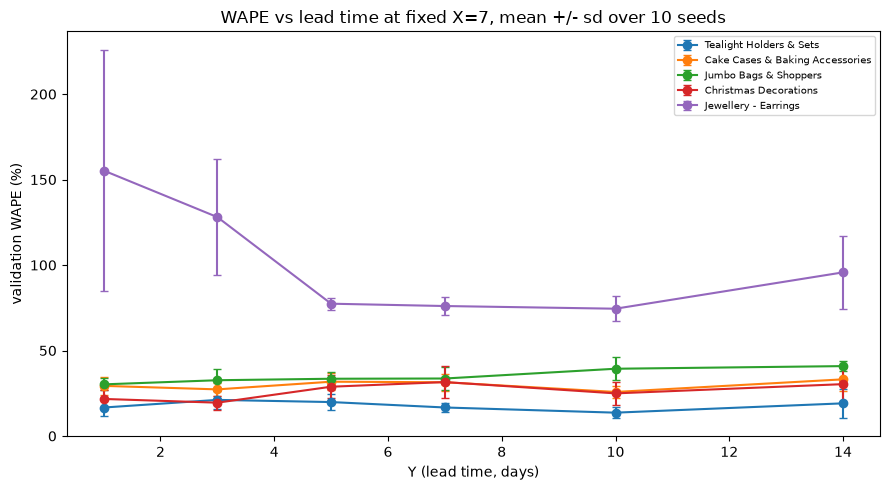

Category,Cake Cases & Baking Accessories,Christmas Decorations,Jewellery - Earrings,Jumbo Bags & Shoppers,Tealight Holders & Sets
Y,,,,,
1,29.34,21.69,155.32,30.21,16.66
3,27.28,19.50,128.07,32.63,21.13
5,31.77,28.84,77.40,33.50,19.86
7,31.45,31.55,76.04,33.64,16.69
10,25.77,24.94,74.47,39.35,13.66
14,33.15,30.34,95.73,40.89,19.11


In [60]:
Y_scan = []
BEST_X = 7   # set by replenishment cycle, not by minimising WAPE

for cat in selected_categories:
    for y in [1, 3, 5, 7, 10, 14]:
        d = feat.build_features(daily, cat, X=BEST_X, Y=y)
        if len(d) < 50:
            continue
        t = config.target_name(BEST_X, y)
        f = feat.available_features(d)
        wapes = []
        for seed in SEEDS_XY:
            s = spl.stratified_block_split(d, t, random_state=seed)
            _, vp, _ = mdl.MODELS["Random Forest"](s["train"], s["validation"],
                                                   s["test"], f, t)
            wapes.append(evaluate_forecast(s["validation"][t], vp)["wape"])
        Y_scan.append({"Category": cat, "Y": y,
                       "wape_mean": round(np.mean(wapes), 2),
                       "wape_std": round(np.std(wapes), 2)})

y_df = pd.DataFrame(Y_scan)

fig, ax = plt.subplots(figsize=(9, 5))
for cat in selected_categories:
    sub = y_df[y_df["Category"] == cat]
    ax.errorbar(sub["Y"], sub["wape_mean"], yerr=sub["wape_std"],
                marker="o", capsize=3, label=cat)
ax.set_xlabel("Y (lead time, days)"); ax.set_ylabel("validation WAPE (%)")
ax.set_title(f"WAPE vs lead time at fixed X={BEST_X}, mean +/- sd over 10 seeds")
ax.legend(fontsize=7)
plt.tight_layout(); plt.show()

y_df.pivot(index="Y", columns="Category", values="wape_mean")

Lead time shows no consistent effect, which is itself worth reporting. The
natural expectation — forecasting further ahead is harder — does not appear.
Tealight Holders & Sets ranges from 13.66 to 21.13 across Y with no trend, and
Cake Cases & Baking Accessories is similarly flat.

The exception is Jewellery - Earrings, falling from 155.32 at Y=1 to 74.47 at
Y=10. On a category with ~60% zero-demand days, a short lead time means the
target window frequently starts immediately after a run of zeros, which the
recent-history features predict poorly.

For the other four categories, Y can therefore be set by operational
constraints — the supplier's replenishment cycle — rather than by forecast
accuracy, because accuracy does not meaningfully depend on it in the range
tested.

### Step 12.3 — Joint analysis of forecasting window X and lead time Y

The previous experiments varied X and Y separately. This experiment evaluates
their combined effect using a compact 3 × 3 grid:

- Forecast windows: X = 7, 14, 28 days.
- Lead times: Y = 1, 7, 14 days.

For each category, we use the same forecasting model selected in Step 12.0.

To make comparisons more consistent, all nine combinations are evaluated on
the same reference dates. For each repeated split, the train, validation,
and test reference dates are also kept identical across combinations.

The results report validation WAPE, MAE, mean actual demand, and WAPE
variability across 10 repeated splits.

WAPE values across different X should not be interpreted as directly
comparable forecasting tasks, because changing X also changes the cumulative
quantity being predicted. Comparisons across Y at a fixed X are more
informative, although the target period still changes.

In [332]:
# Step 12.3 — Joint X/Y experiment

XY_X_VALUES = [7, 14, 28]
XY_Y_VALUES = [1, 7, 14]
XY_SEEDS = range(10)

xy_rows = []

for cat in selected_categories:

    model_name = best_model_by_category[cat]
    print(f"Running {cat} with {model_name}")

    # Build the nine datasets once per category.
    xy_datasets = {}

    for x in XY_X_VALUES:
        for y in XY_Y_VALUES:
            xy_datasets[(x, y)] = feat.build_features(daily, cat, X=x, Y=y).copy()

    # Retain only reference dates available for ALL X/Y combinations.
    common_dates = set(xy_datasets[(7, 7)]["Date"])
    for d in xy_datasets.values():
        common_dates &= set(d["Date"])
    common_dates = sorted(common_dates)

    if len(common_dates) < 50:
        print(f"Skipping {cat}: insufficient common dates.")
        continue

    for key, d in xy_datasets.items():
        xy_datasets[key]=(d[d["Date"].isin(common_dates)].sort_values("Date").reset_index(drop=True))
        assert len(xy_datasets[key]) == len(common_dates)

    # The X=7, Y=7 dataset defines the SAME reference-date
    # split for every X/Y combination within each seed.
    anchor = xy_datasets[(7, 7)]
    anchor_target = config.target_name(7, 7)

    for seed in XY_SEEDS:
        anchor_split = spl.stratified_block_split(anchor, anchor_target, random_state=seed)
        split_dates = {
            part: anchor_split[part]["Date"]
            for part in ["train", "validation", "test"]
        }

        for x in XY_X_VALUES:
            for y in XY_Y_VALUES:
                d = xy_datasets[(x, y)]
                target = config.target_name(x, y)
                f = feat.available_features(d)
                # Reuse the same split dates instead of generating a different stratified split for each target.
                indexed = d.set_index("Date", drop=False)
                s = {
                    part: indexed.loc[dates].copy()
                    for part, dates in split_dates.items()
                }
                _, val_pred, _ = mdl.MODELS[model_name](s["train"],s["validation"], s["test"], f, target)
                actual=s["validation"][target]
                metrics=evaluate_forecast(actual, val_pred)

                xy_rows.append({
                    "Category": cat,
                    "Model": model_name,
                    "X": x,
                    "Y": y,
                    "Seed": seed,
                    "WAPE (%)": metrics["wape"],
                    "MAE": metrics["mae"],
                    "Mean actual demand": actual.mean(),
                    "Validation observations": len(actual)
                })

xy_raw_df = pd.DataFrame(xy_rows)

xy_summary_df=(xy_raw_df
    .groupby(["Category", "Model", "X", "Y"],as_index=False)
    .agg(
        wape_mean=("WAPE (%)", "mean"),
        wape_std=("WAPE (%)", "std"),
        mae_mean=("MAE", "mean"),
        actual_mean=("Mean actual demand", "mean"),
        n_validation=("Validation observations", "mean")
    )
)

display(
    xy_summary_df[
        ["Category",
            "X",
            "Y",
            "wape_mean",
            "wape_std",
            "mae_mean",
            "actual_mean"
        ]
    ].round(2)
)

Running Tealight Holders & Sets with Random Forest
Running Cake Cases & Baking Accessories with Random Forest
Running Jumbo Bags & Shoppers with Linear Regression
Running Christmas Decorations with XGBoost
Running Jewellery - Earrings with XGBoost


,Category,X,Y,wape_mean,wape_std,mae_mean,actual_mean
0,Cake Cases & Baking Accessories,7,1,27.21,6.50,1358.25,5058.90
1,Cake Cases & Baking Accessories,7,7,25.01,8.79,1292.52,5198.05
2,Cake Cases & Baking Accessories,7,14,30.69,8.44,1590.92,5257.41
3,Cake Cases & Baking Accessories,14,1,16.57,4.95,1688.05,10271.73
4,Cake Cases & Baking Accessories,14,7,15.97,5.09,1658.11,10455.46
5,Cake Cases & Baking Accessories,14,14,17.67,3.82,1866.21,10651.58
6,Cake Cases & Baking Accessories,28,1,11.16,3.68,2329.74,20935.97
7,Cake Cases & Baking Accessories,28,7,11.14,2.68,2355.58,21290.56
8,Cake Cases & Baking Accessories,28,14,11.66,2.94,2467.83,21510.16
9,Christmas Decorations,7,1,33.45,10.90,414.60,1153.92


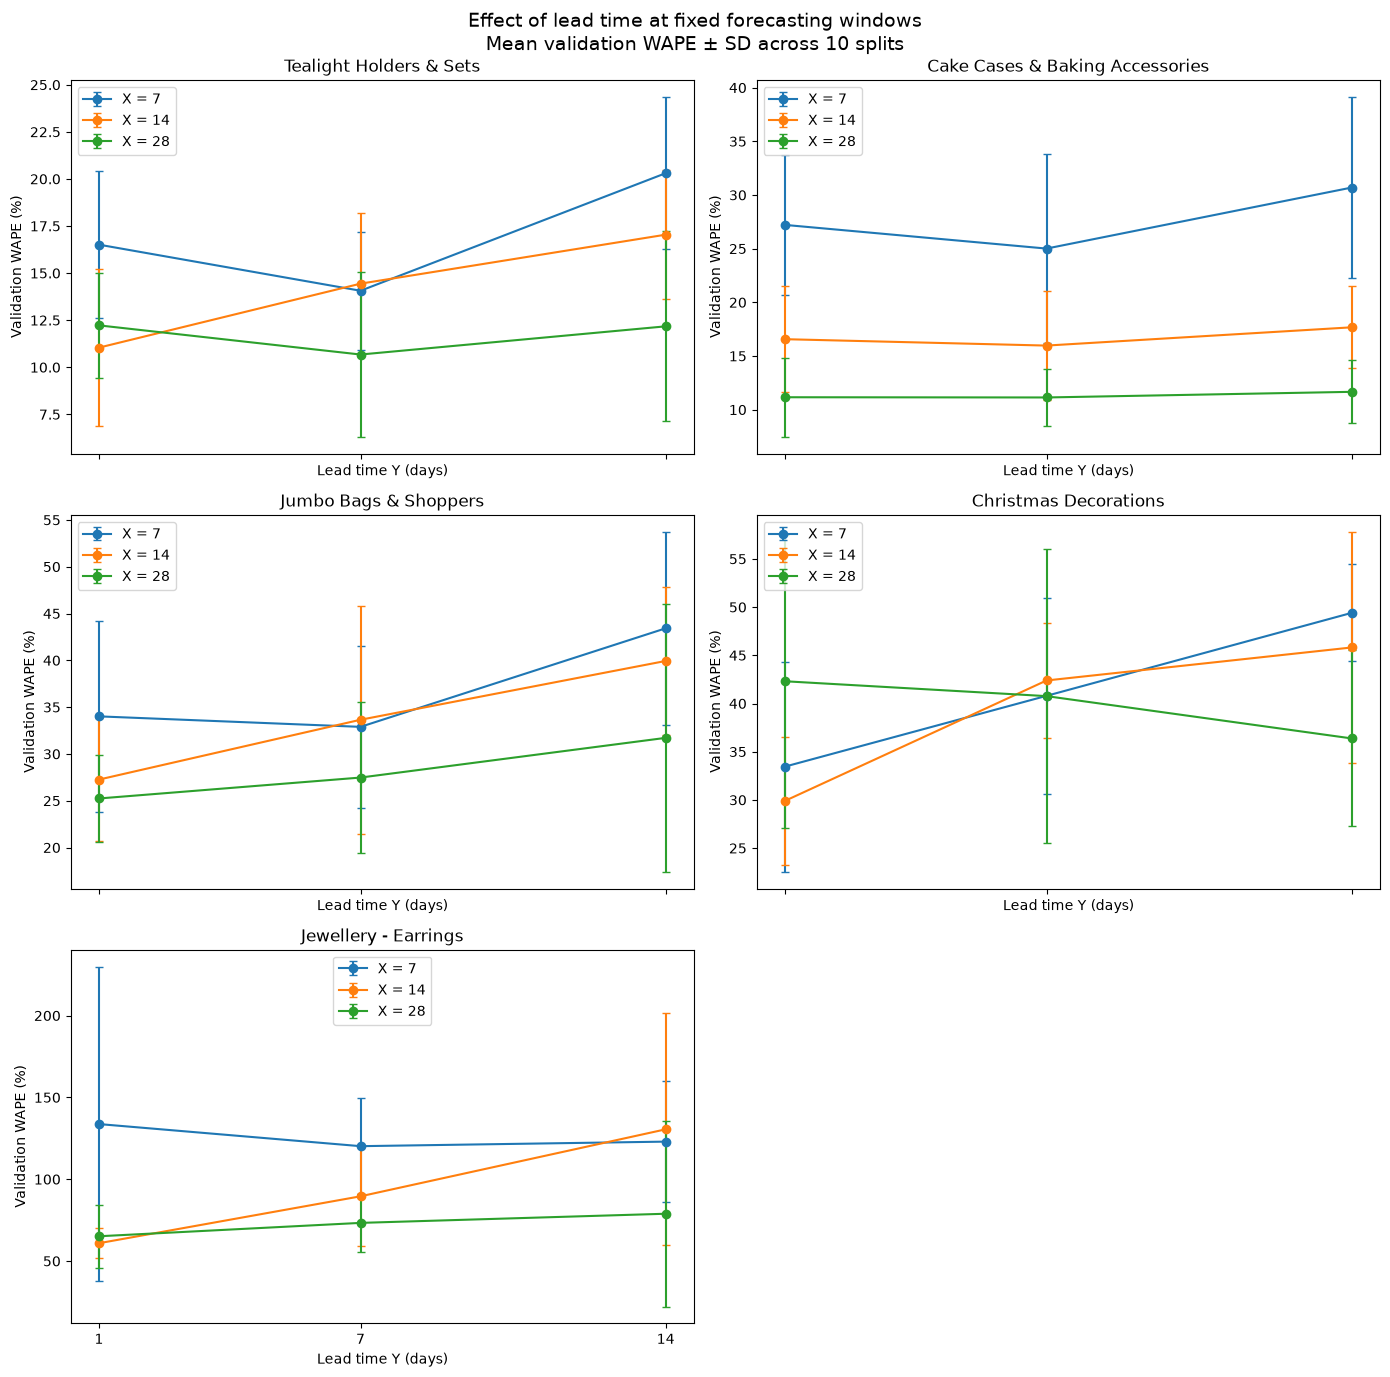

In [253]:
# Step 12.4 — WAPE vs lead time, at each fixed X

fig, axes = plt.subplots(
    3, 2,
    figsize=(14, 14),
    sharex=True
)

axes = axes.flatten()

for ax, cat in zip(axes, selected_categories):

    sub = xy_summary_df[
        xy_summary_df["Category"] == cat
    ]

    for x in XY_X_VALUES:

        x_sub = sub[
            sub["X"] == x
        ].sort_values("Y")

        ax.errorbar(
            x_sub["Y"],
            x_sub["wape_mean"],
            yerr=x_sub["wape_std"],
            marker="o",
            capsize=3,
            label=f"X = {x}"
        )

    ax.set_title(cat)
    ax.set_xlabel("Lead time Y (days)")
    ax.set_ylabel("Validation WAPE (%)")
    ax.set_xticks(XY_Y_VALUES)
    ax.legend()

# Hide unused sixth subplot.
for ax in axes[len(selected_categories):]:
    ax.set_visible(False)

fig.suptitle(
    "Effect of lead time at fixed forecasting windows\n"
    "Mean validation WAPE ± SD across 10 splits",
    fontsize=14
)

plt.tight_layout()
plt.show()

In [333]:
# Step 12.5 — MAE and WAPE comparison tables

for x in XY_X_VALUES:

    sub = xy_summary_df[
        xy_summary_df["X"] == x
    ]
    print(f"\nForecasting window X = {x} days")

    print("Mean validation WAPE (%)")
    display(
        sub.pivot(
            index="Y",
            columns="Category",
            values="wape_mean"
        ).round(2)
    )

    print("Mean validation MAE (units)")
    display(sub.pivot(index="Y", columns="Category", values="mae_mean").round(2))


Forecasting window X = 7 days
Mean validation WAPE (%)


Category,Cake Cases & Baking Accessories,Christmas Decorations,Jewellery - Earrings,Jumbo Bags & Shoppers,Tealight Holders & Sets
Y,,,,,
1,27.21,33.45,133.70,34.01,16.51
7,25.01,40.80,120.20,32.89,14.06
14,30.69,49.40,122.98,43.42,20.30


Mean validation MAE (units)


Category,Cake Cases & Baking Accessories,Christmas Decorations,Jewellery - Earrings,Jumbo Bags & Shoppers,Tealight Holders & Sets
Y,,,,,
1,1358.25,414.60,21.89,1552.62,693.24
7,1292.52,590.77,18.04,1491.80,607.57
14,1590.92,841.08,24.46,1984.57,933.00



Forecasting window X = 14 days
Mean validation WAPE (%)


...

Category,Cake Cases & Baking Accessories,Christmas Decorations,Jewellery - Earrings,Jumbo Bags & Shoppers,Tealight Holders & Sets
Y,,,,,
1,1688.05,799.01,19.62,2485.54,944.71
7,1658.11,1367.30,31.63,3051.23,1287.17
14,1866.21,1788.92,44.02,3617.18,1574.52



Forecasting window X = 28 days
Mean validation WAPE (%)


Category,Cake Cases & Baking Accessories,Christmas Decorations,Jewellery - Earrings,Jumbo Bags & Shoppers,Tealight Holders & Sets
Y,,,,,
1,11.16,42.31,65.15,25.24,12.23
7,11.14,40.77,73.32,27.48,10.68
14,11.66,36.38,78.91,31.72,12.17


Mean validation MAE (units)


Category,Cake Cases & Baking Accessories,Christmas Decorations,Jewellery - Earrings,Jumbo Bags & Shoppers,Tealight Holders & Sets
Y,,,,,
1,2329.74,2902.38,46.83,4598.83,2184.14
7,2355.58,3127.10,61.92,4919.63,1970.08
14,2467.83,3504.64,66.88,5623.75,2356.79


### Step 12.6 — Interpretation of the joint X/Y experiment

The joint experiment evaluated three forecasting windows (X = 7, 14,
and 28 days) and three lead times (Y = 1, 7, and 14 days) across five
product categories, using 10 repeated splits per configuration.

**1. Effect of lead time at a fixed forecasting window**

Increasing lead time often increases forecasting error, but this
relationship is not systematic across categories and forecasting windows.

For example, at X = 14, WAPE increases with Y for Jumbo Bags & Shoppers
(27.26% to 39.93%), Tealight Holders & Sets (11.04% to 17.04%),
Christmas Decorations (29.90% to 45.81%), and Jewellery - Earrings
(60.89% to 130.49%).

However, Cake Cases & Baking Accessories is relatively insensitive
to lead time at X = 28, with WAPE values between 11.14% and 11.66%.

Christmas Decorations also exhibits a different pattern at X = 28:
WAPE decreases from 42.31% at Y = 1 to 36.38% at Y = 14.

These results indicate that the effect of lead time depends on both
the forecasting window and the category's demand characteristics.

**2. Effect of the forecasting-window length**

Longer forecasting windows often produce lower WAPE, especially for
Cake Cases & Baking Accessories, Jumbo Bags & Shoppers, and
Tealight Holders & Sets.

Nevertheless, this decrease does not automatically imply better
forecasting accuracy.

Increasing X changes the prediction target by aggregating demand
over a longer period. The mean actual demand therefore increases,
which can mechanically reduce WAPE through its denominator.

At the same time, MAE in absolute units generally increases with X.
Consequently, X should reflect the operational forecasting requirement
rather than being selected solely by minimizing WAPE across windows.

**3. Category-dependent robustness**

The repeated-split analysis reveals substantial differences in the
stability of forecasting performance across categories.

Jewellery - Earrings exhibits particularly high WAPE and variability,
especially at short forecasting windows. This is consistent with the
difficulty of forecasting sparse demand and abrupt demand changes
observed in the previous error analysis.

Other categories, such as Cake Cases & Baking Accessories, show
more stable performance across the tested lead times.

Small differences in mean WAPE should therefore be interpreted
alongside their standard deviations rather than treated as definitive
performance improvements.

**4. Methodological limitations**

All X/Y configurations use common reference dates and the same
train-validation-test assignments within each repeated split.
This improves comparability between configurations.

However, changing X or Y also changes the future period being
predicted, so different configurations may contain different
demand events.

Furthermore, overlapping target windows and temporal dependencies
between the stratified-block splits limit the interpretation of
these results as independent out-of-sample performance estimates.

**Conclusion**

The experiment identifies an interaction between forecasting-window
length, lead time, and product category. No single X/Y configuration
provides uniformly lower forecasting error across all categories.

The appropriate X and Y should be determined primarily by the
operational forecasting task, after which the predictive performance
of the models can be evaluated for that specific configuration.

### Step 12.7 — Feature selection: Can fewer features improve forecasting?

The current forecasting pipeline uses approximately 30 explanatory
variables, while the available training dataset is relatively small.

This experiment investigates whether reducing the feature set can
improve forecasting accuracy and stability.

We focus on two challenging categories:
- Jewellery - Earrings
- Christmas Decorations

For each category, we compare three configurations:
- Full feature set
- Top 15 features
- Top 10 features

Feature ranking is performed using mutual information estimated
exclusively on the training subset of each split.

The forecasting model, prediction target (X = 7, Y = 7), and data
splits remain identical across the three configurations.

Performance is evaluated on validation data across 10 repeated
splits using MAE and WAPE.

The objective is not to assume that fewer features are always better,
but to determine whether a smaller feature set provides a consistent
improvement or maintains similar accuracy with lower complexity.

In [336]:
# Step 12.8 — Repeated feature selection experiment

FS_CATEGORIES=["Jewellery - Earrings", "Christmas Decorations"]
FS_SEEDS=range(10)
FS_SIZES=[len(features), 15, 10]
fs_results=[]
fs_selected_features={}

for cat in FS_CATEGORIES:
    model_name=best_model_by_category[cat]
    print(f"\nRunning: {cat}")
    print(f"Model: {model_name}")
    d=datasets[cat].copy()
    for seed in FS_SEEDS:
        # Same data split for all feature configurations
        s=spl.stratified_block_split(d, target_col, random_state=seed)
        tr=s["train"]
        va=s["validation"]
        te=s["test"]

        # Rank features using TRAINING DATA ONLY
        ranked_features = pipe.select_features(
            tr, features, target_col, n_features=len(features))

        fs_selected_features[(cat, seed)] = ranked_features

        for n_features in FS_SIZES:
            selected = ranked_features[:n_features]
            # Same model and split; only the feature set changes
            _, val_pred, _ = mdl.MODELS[model_name](
                tr, va, te, selected, target_col)

            val_pred = np.maximum(np.asarray(val_pred).reshape(-1),0)

            metrics=evaluate_forecast(va[target_col],val_pred)

            fs_results.append({
                "Category": cat,
                "Model": model_name,
                "Seed": seed,
                "Number of features": n_features,
                "Validation WAPE (%)": metrics["wape"],
                "Validation MAE": metrics["mae"]
            })

fs_raw_df = pd.DataFrame(fs_results)

fs_summary_df = (
    fs_raw_df.groupby(["Category", "Number of features"],as_index=False)
    .agg(mean_wape=("Validation WAPE (%)", "mean"),
        std_wape=("Validation WAPE (%)", "std"),
        mean_mae=("Validation MAE", "mean"),
        std_mae=("Validation MAE", "std"))
)

display(fs_summary_df.round(2))


Running: Jewellery - Earrings
Model: XGBoost

Running: Christmas Decorations
Model: XGBoost


,Category,Number of features,mean_wape,std_wape,mean_mae,std_mae
0,Christmas Decorations,10,33.36,12.93,1480.99,518.95
1,Christmas Decorations,15,34.23,10.80,1524.10,428.73
2,Christmas Decorations,30,33.82,10.08,1508.38,406.95
3,Jewellery - Earrings,10,73.61,11.81,31.96,4.42
4,Jewellery - Earrings,15,76.59,7.67,33.46,4.25
5,Jewellery - Earrings,30,75.23,6.60,32.86,3.73


In [338]:
# Step 12.9 — Paired comparison with the full feature set

fs_comparison = []
for cat in FS_CATEGORIES:
    sub=fs_raw_df[fs_raw_df["Category"] == cat]
    pivot=sub.pivot(index="Seed", columns="Number of features", values="Validation WAPE (%)")
    full_size = len(features)
    for reduced_size in [15, 10]:
        delta=(pivot[reduced_size]-pivot[full_size])
        fs_comparison.append({
            "Category": cat,
            "Features retained": reduced_size,
            "Mean Δ WAPE (pp)": delta.mean(),
            "Std Δ WAPE (pp)": delta.std(),
            "Splits improved (%)": 100 * (delta < 0).mean()
        })
fs_comparison_df = pd.DataFrame(fs_comparison)
display(fs_comparison_df.round(2))

,Category,Features retained,Mean Δ WAPE (pp),Std Δ WAPE (pp),Splits improved (%)
0,Jewellery - Earrings,15,1.36,2.13,20.0
1,Jewellery - Earrings,10,-1.62,8.63,70.0
2,Christmas Decorations,15,0.41,1.13,30.0
3,Christmas Decorations,10,-0.46,4.58,60.0


### Step 12.10 — Interpretation of feature selection

The feature selection experiment compared the full set of 30
explanatory variables with reduced sets of 15 and 10 variables,
using the same forecasting model and 10 repeated validation splits.

For Jewellery - Earrings, reducing the feature set to 10 variables
decreased mean validation WAPE from 75.23% to 73.61%, corresponding
to an improvement of 1.62 percentage points. The reduced model
performed better on 70% of the splits.

However, the standard deviation of WAPE increased from 6.60 to
11.81 percentage points. The improvement in average accuracy was
therefore accompanied by greater variability across splits.

For Christmas Decorations, the differences between configurations
were small. The 10-feature model achieved a mean WAPE of 33.36%,
compared with 33.82% for the full model, and improved performance
on 60% of the splits. Its WAPE standard deviation nevertheless
increased from 10.18 to 12.93 percentage points.

The 15-feature configuration did not improve mean WAPE for either
category.

Overall, the experiment suggests that a substantially smaller
feature set can maintain forecasting accuracy comparable to the
full model. However, reducing the number of features does not
consistently improve predictive performance or stability.

The results support feature reduction as a possible model
simplification strategy, rather than establishing that the
reduced models are systematically more accurate or robust.

Given the limited number of observations and the variability
across splits, the full feature set is retained as the reference
configuration for the existing forecasting pipeline.

## Step 13: Forecast visualisation

Aggregate metrics hide the shape of the error. These plots compare actual and
predicted demand over the test period.

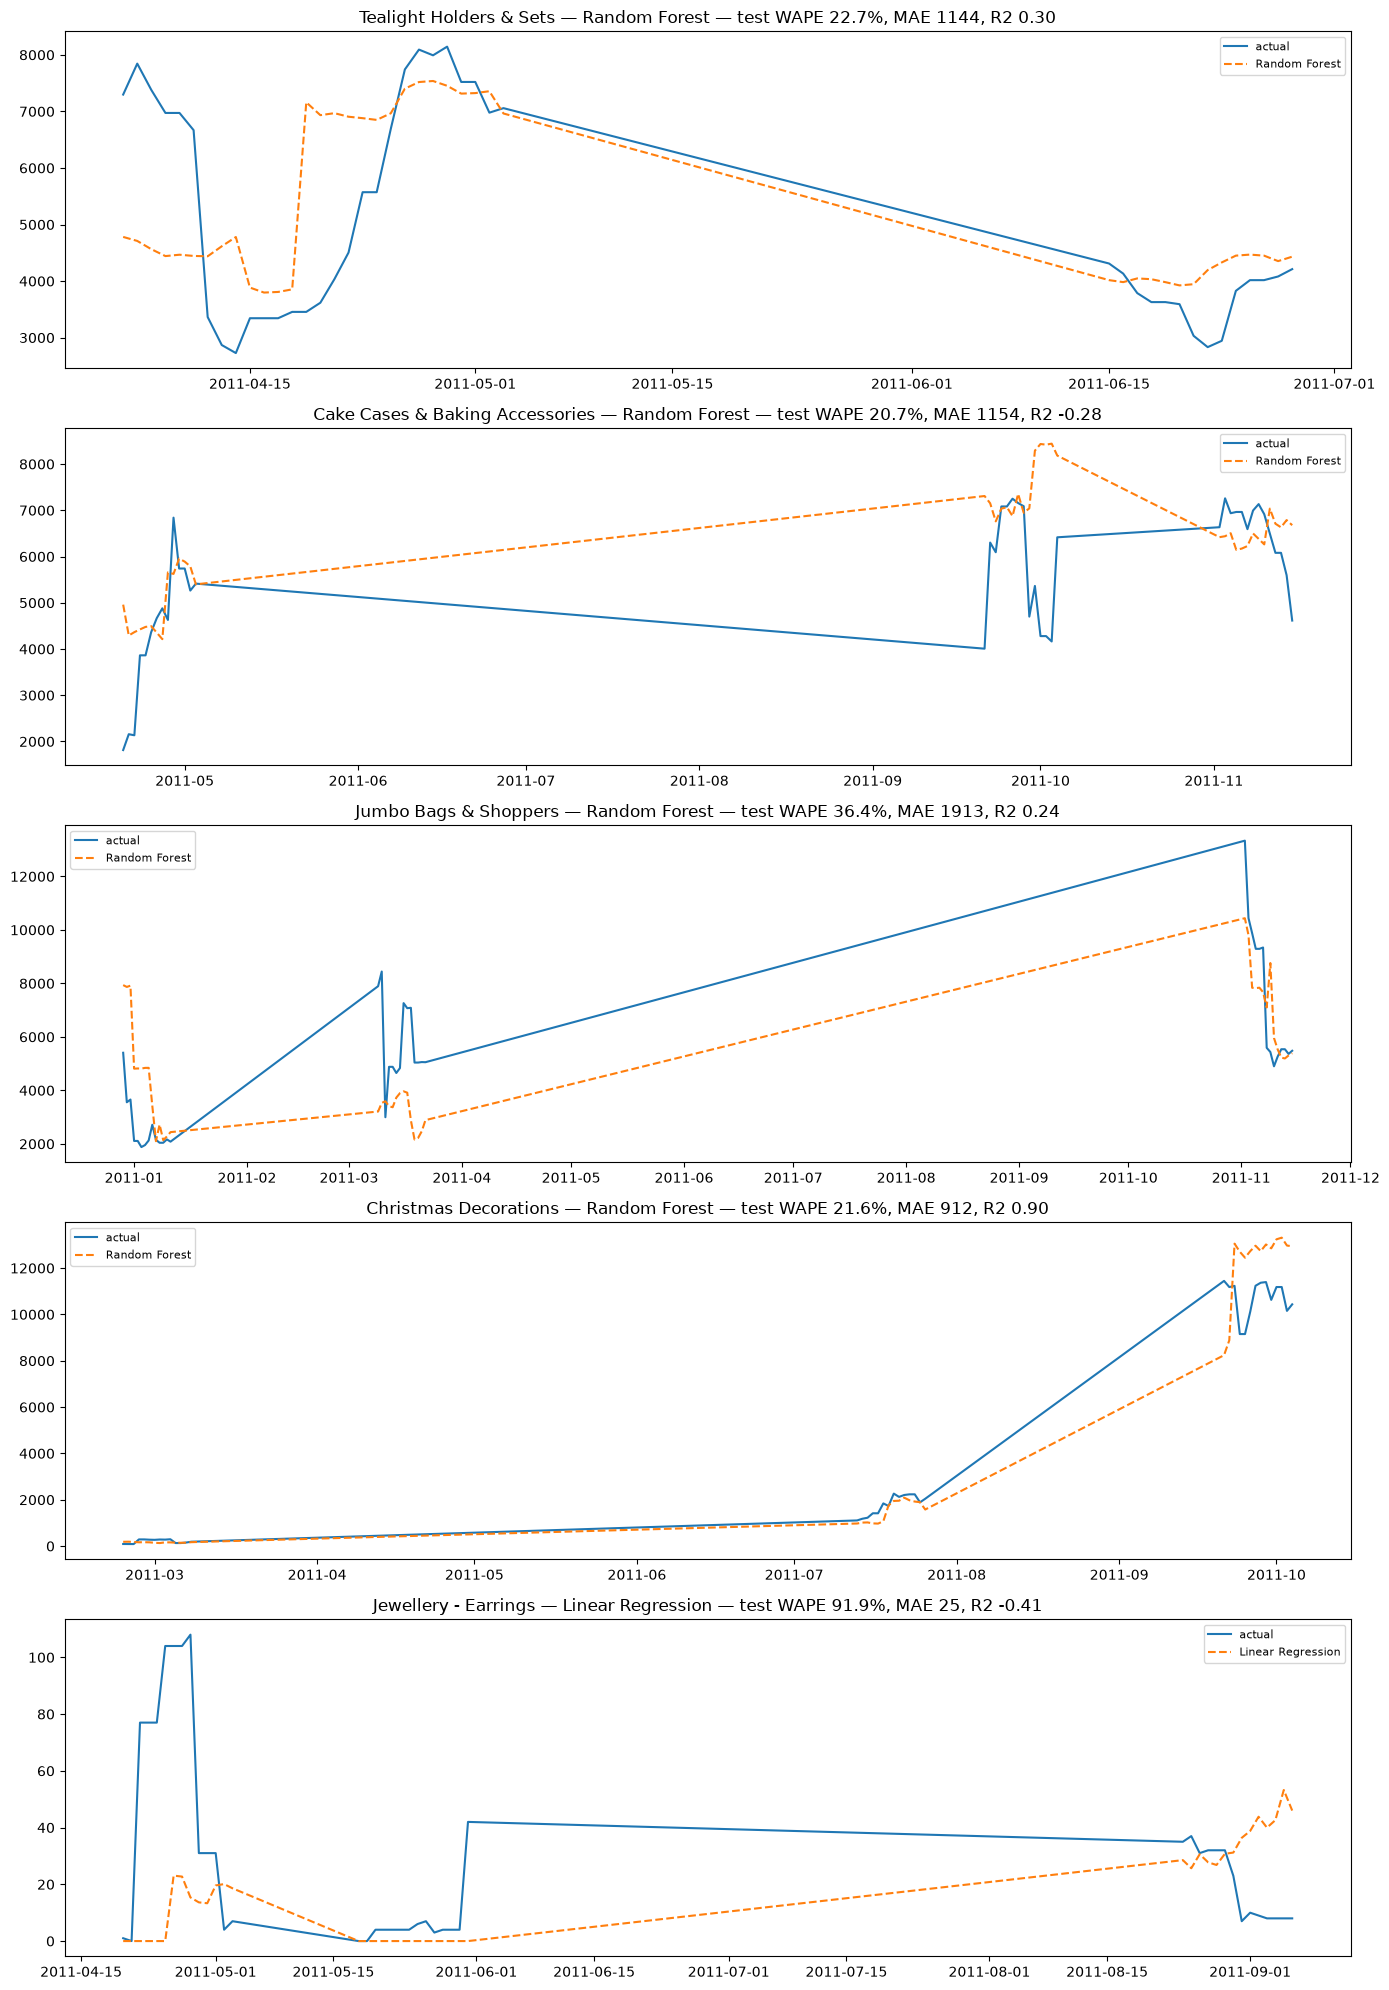

In [63]:
fig, axes = plt.subplots(len(selected_categories), 1,
                         figsize=(14, 4 * len(selected_categories)))

for ax, cat in zip(axes, selected_categories):
    s = splits[cat]
    test = s["test"].sort_values("Date")

    # Plot the model that won on TEST for this category, so that this figure
    # and the bar chart above describe the same models. An earlier version
    # plotted models chosen in a separate, superseded pass, which made the two
    # figures mutually inconsistent.
    sub = all_results[all_results["Category"] == cat]
    best_model = sub.loc[sub["Test WAPE (%)"].idxmin(), "Model"]

    _, _, tp = mdl.MODELS[best_model](s["train"], s["validation"],
                                      test, features, target_col)
    m = evaluate_forecast(test[target_col], tp)

    ax.plot(test["Date"], test[target_col], label="actual", lw=1.5)
    ax.plot(test["Date"], np.maximum(tp, 0), label=best_model, lw=1.5, ls="--")
    ax.set_title(f"{cat} — {best_model} — test WAPE {m['wape']:.1f}%, "
                 f"MAE {m['mae']:.0f}, R2 {m['r2']:.2f}")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

### Interpretation

The predicted series is consistently smoother than the actual one. The models
track the demand level but miss sudden peaks and overestimate quiet periods.

This is why a category can show a low WAPE and a negative R² at the same time:
predicting something close to the mean keeps aggregate error moderate while
explaining none of the day-to-day variation. WAPE rewards being roughly right
on average; R² asks whether the variation was captured. On this dataset they
frequently disagree, and both should be reported.


## Step 14: Forecast Error Analysis

The previous experiments compared forecasting models using aggregate performance metrics such as MAE, RMSE, WAPE, and R². However, these metrics alone do not fully describe how forecasting errors are distributed across different demand levels and time periods.

In particular, the forecast visualization in Step 13 suggests that some models produce relatively smooth predictions and fail to capture sudden increases in demand.

This section investigates forecasting errors in greater detail to identify potential limitations of the current models and guide subsequent improvements in feature engineering and model development.

The analysis focuses on four main questions:

1. Do the models systematically underestimate or overestimate demand?
2. Are forecasting errors larger during high-demand periods?
3. How are prediction errors distributed?
4. Do forecasting errors exhibit temporal patterns?

We initially focus on the Jewellery - Earrings category, which exhibited substantial variability in demand in the previous experiments.

The analysis uses a forecasting window of X = 7 days and a lead time of Y = 7 days.

**Methodological note:** This section initially reuses the existing stratified block split for exploratory error analysis. As the split may contain overlapping target windows, the results should not be interpreted as an unbiased estimate of prospective forecasting performance. Improvements motivated by this analysis will require evaluation on a separate, leakage-free test period.


### Step 14.1: Category and Model Selection

We first select the Jewellery - Earrings category and identify the model with the lowest validation WAPE.

Model selection is performed using the validation set rather than the test set to avoid selecting a model based on its final evaluation performance.

The selected model will be used to investigate the distribution, magnitude, and temporal structure of forecasting errors.

In [67]:

# Step 14.1 — Category and model selection

CATEGORY = "Jewellery - Earrings"

# Retrieve the existing train/validation/test split
s = splits[CATEGORY]

train = s["train"].copy()
validation = s["validation"].copy()
test = s["test"].copy()

# Retrieve the results of the selected category
category_results = all_results[
    all_results["Category"] == CATEGORY
].copy()

# Select the model using validation performance only
best_row = category_results.loc[
    category_results["Validation WAPE (%)"].idxmin()
]

best_model = best_row["Model"]

print(f"Category: {CATEGORY}")
print(f"Selected model: {best_model}")
print(f"Target: {target_col}")

print(f"Train observations: {len(train)}")
print(f"Validation observations: {len(validation)}")
print(f"Test observations: {len(test)}")

print(
    f"\nValidation WAPE: "
    f"{best_row['Validation WAPE (%)']:.2f}%"
)

print(
    f"Test WAPE: "
    f"{best_row['Test WAPE (%)']:.2f}%"
)

Category: Jewellery - Earrings
Selected model: XGBoost
Target: target_X7_Y7
Train observations: 235
Validation observations: 56
Test observations: 42

Validation WAPE: 65.80%
Test WAPE: 110.45%



### Step 14.2: Prediction Errors and Residual Construction

We generate predictions for the selected category and compute the corresponding forecast errors.

For each observation, the forecast error is defined as:

$$
e_t = y_t - \hat{y}_t
$$

where:

- $y_t$ is the actual demand over the forecasting window.
- $\hat{y}_t$ is the predicted demand over the same window.

A positive error indicates that the model underestimated actual demand, whereas a negative error indicates that the model overestimated demand.

The absolute error measures the magnitude of the deviation independently of its direction:

$$
AE_t = |y_t - \hat{y}_t|
$$

The squared error is defined as:

$$
SE_t = (y_t - \hat{y}_t)^2
$$

Squared errors give greater weight to large deviations and are useful for identifying extreme forecasting errors.

All errors are expressed relative to the total demand over the 7-day forecasting window.

In [98]:

# Step 14.2 — Generate predictions and compute errors

# Fit the selected model using the existing training split
# and generate predictions for validation and test.

_, validation_predictions, test_predictions = (
    mdl.MODELS[best_model](
        train,
        validation,
        test,
        features,
        target_col
    )
)

# Build the error analysis dataframe
error_df = test[["Date", target_col]].copy()

error_df["Actual"] = test[target_col].to_numpy()

error_df["Predicted"] = np.maximum(
    np.asarray(test_predictions).reshape(-1),
    0
)

# Forecast errors
error_df["Error"] = (
    error_df["Actual"] - error_df["Predicted"]
)

error_df["Absolute_Error"] = (
    error_df["Error"].abs()
)

error_df["Squared_Error"] = (
    error_df["Error"] ** 2
)

# Sort observations chronologically
error_df = (
    error_df
    .sort_values("Date")
    .reset_index(drop=True)
)

display(error_df.head(10))

,Date,target_X7_Y7,Actual,Predicted,Error,Absolute_Error,Squared_Error
0,2011-04-20,1.0,1.0,13.033189,-12.033189,12.033189,144.797633
1,2011-04-21,0.0,0.0,13.149487,-13.149487,13.149487,172.909021
2,2011-04-22,77.0,77.0,13.713058,63.286942,63.286942,4005.236968
3,2011-04-23,77.0,77.0,14.768140,62.231860,62.231860,3872.804419
4,2011-04-24,77.0,77.0,13.295698,63.704302,63.704302,4058.238072
5,2011-04-25,104.0,104.0,14.235178,89.764822,89.764822,8057.723270
6,2011-04-26,104.0,104.0,7.230563,96.769437,96.769437,9364.323906
7,2011-04-27,104.0,104.0,6.610616,97.389384,97.389384,9484.692076
8,2011-04-28,108.0,108.0,3.415480,104.584520,104.584520,10937.921845
9,2011-04-29,31.0,31.0,3.601539,27.398461,27.398461,750.675645



### Step 14.3: Global Error Statistics and Forecast Bias

Aggregate error metrics provide complementary information about model performance.

The Mean Absolute Error (MAE) measures the average absolute deviation between predicted and actual demand:

$$
MAE = \frac{1}{N}\sum_{t=1}^{N}|e_t|
$$

The Root Mean Squared Error (RMSE) penalizes large forecasting errors more heavily:

$$
RMSE = \sqrt{\frac{1}{N}\sum_{t=1}^{N}e_t^2}
$$

The Weighted Absolute Percentage Error (WAPE) expresses the total absolute error relative to the total observed demand:

$$
WAPE = 100\frac{\sum_{t=1}^{N}|e_t|}
{\sum_{t=1}^{N}|y_t|}
$$

To investigate systematic overestimation or underestimation, we compute the Mean Forecast Error (MFE):

$$
MFE = \frac{1}{N}\sum_{t=1}^{N}e_t
$$

A positive MFE indicates average underestimation, while a negative MFE indicates average overestimation.

We also compute the percentage of observations for which the model underestimates or overestimates demand.

These statistics help determine whether the forecasting errors are approximately balanced or exhibit systematic directional bias.

In [100]:

# Step 14.3 — Global forecasting error statistics

actual = error_df["Actual"]
predicted = error_df["Predicted"]
errors = error_df["Error"]

mae = errors.abs().mean()

rmse = np.sqrt(
    np.mean(errors ** 2)
)

wape = (
    100 * errors.abs().sum() / actual.abs().sum()
    if actual.abs().sum() > 0
    else np.nan
)

mean_bias = errors.mean()

relative_bias = (
    100 * errors.sum() / actual.sum()
    if actual.sum() != 0
    else np.nan
)

underestimation_rate = (
    100 * (errors > 0).mean()
)

overestimation_rate = (
    100 * (errors < 0).mean()
)

zero_error_rate = (
    100 * (errors == 0).mean()
)

error_statistics = pd.Series({

    "Mean actual demand": actual.mean(),

    "Mean predicted demand": predicted.mean(),

    "MAE": mae,

    "RMSE": rmse,

    "WAPE (%)": wape,

    "Mean Bias": mean_bias,

    "Relative Bias (%)": relative_bias,

    "Underestimation rate (%)": underestimation_rate,

    "Overestimation rate (%)": overestimation_rate,

    "Exact prediction rate (%)": zero_error_rate

})

display(
    error_statistics.to_frame("Value").round(2)
)

,Value
Mean actual demand,26.81
Mean predicted demand,15.77
MAE,29.61
RMSE,40.79
WAPE (%),110.45
Mean Bias,11.04
Relative Bias (%),41.19
Underestimation rate (%),50.00
Overestimation rate (%),50.00
Exact prediction rate (%),0.00


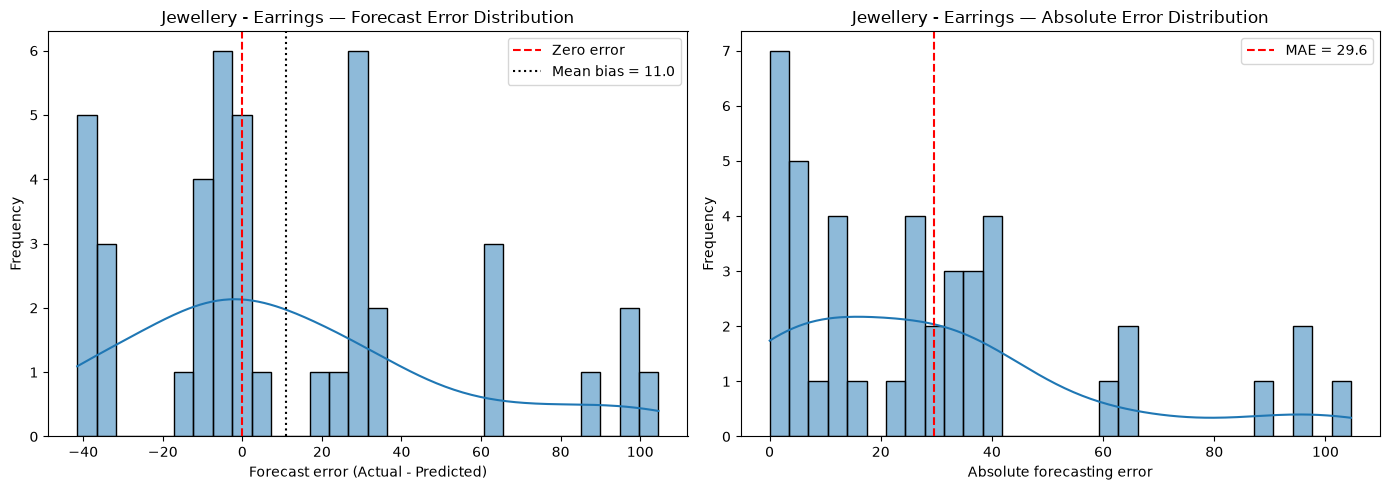

In [102]:

# Forecast error distribution

fig, axes = plt.subplots(
    1, 2,
    figsize=(14, 5)
)

# Distribution of signed errors
sns.histplot(
    error_df["Error"],
    bins=30,
    kde=True,
    ax=axes[0]
)

axes[0].axvline(
    0,
    color="red",
    linestyle="--",
    label="Zero error"
)

axes[0].axvline(
    mean_bias,
    color="black",
    linestyle=":",
    label=f"Mean bias = {mean_bias:.1f}"
)

axes[0].set_title(
    f"{CATEGORY} — Forecast Error Distribution"
)

axes[0].set_xlabel(
    "Forecast error (Actual - Predicted)"
)

axes[0].set_ylabel("Frequency")

axes[0].legend()


# Distribution of absolute errors
sns.histplot(
    error_df["Absolute_Error"],
    bins=30,
    kde=True,
    ax=axes[1]
)

axes[1].axvline(
    mae,
    color="red",
    linestyle="--",
    label=f"MAE = {mae:.1f}"
)

axes[1].set_title(
    f"{CATEGORY} — Absolute Error Distribution"
)

axes[1].set_xlabel(
    "Absolute forecasting error"
)

axes[1].set_ylabel("Frequency")

axes[1].legend()

plt.tight_layout()
plt.show()


### Step 14.4: Forecasting Performance During High-Demand Periods

The previous forecast visualization suggests that the selected model may struggle to capture sudden increases in demand.

To investigate this phenomenon, we compare forecasting errors between high-demand and regular-demand observations.

High-demand periods are initially defined as observations for which actual demand exceeds the 90th percentile of the observed demand distribution.

We then compare the following metrics across the two groups:

- Mean actual demand.
- Mean predicted demand.
- MAE.
- WAPE.
- Mean forecast bias.
- Underestimation frequency.

This analysis aims to determine whether forecasting errors increase disproportionately during high-demand periods and whether the model exhibits systematic underestimation when demand is unusually high.

The threshold is used for retrospective error analysis. It is not intended as an input feature available at the time of prediction.

Because the forecasting targets are constructed using overlapping 7-day windows, consecutive high-demand observations may correspond to the same underlying sales event.

In [105]:

# Step 14.4 — High-demand error analysis

# Define the high-demand threshold
high_demand_threshold = (
    error_df["Actual"].quantile(0.90)
)

error_df["Demand_Regime"] = np.where(
    error_df["Actual"] >= high_demand_threshold,
    "High demand",
    "Regular demand"
)

# Function to calculate error statistics by demand regime
def compute_regime_metrics(group):

    actual = group["Actual"]
    predicted = group["Predicted"]
    errors = group["Error"]

    return pd.Series({

        "N observations": len(group),

        "Mean actual demand": actual.mean(),

        "Mean predicted demand": predicted.mean(),

        "MAE": errors.abs().mean(),

        "WAPE (%)": (
            100 * errors.abs().sum() / actual.abs().sum()
            if actual.abs().sum() > 0
            else np.nan
        ),

        "Mean Bias": errors.mean(),

        "Underestimation rate (%)": (
            100 * (errors > 0).mean()
        )

    })


# Compare errors across demand regimes
regime_results = (
    error_df
    .groupby("Demand_Regime")
    .apply(
        compute_regime_metrics,
        include_groups=False
    )
)

print(
    f"High-demand threshold: "
    f"{high_demand_threshold:.2f} units"
)

display(regime_results.round(2))

High-demand threshold: 77.00 units


,N observations,Mean actual demand,Mean predicted demand,MAE,WAPE (%),Mean Bias,Underestimation rate (%)
Demand_Regime,,,,,,,
High demand,7.0,93.00,10.47,82.53,88.75,82.53,100.0
Regular demand,35.0,13.57,16.83,19.03,140.20,-3.25,40.0


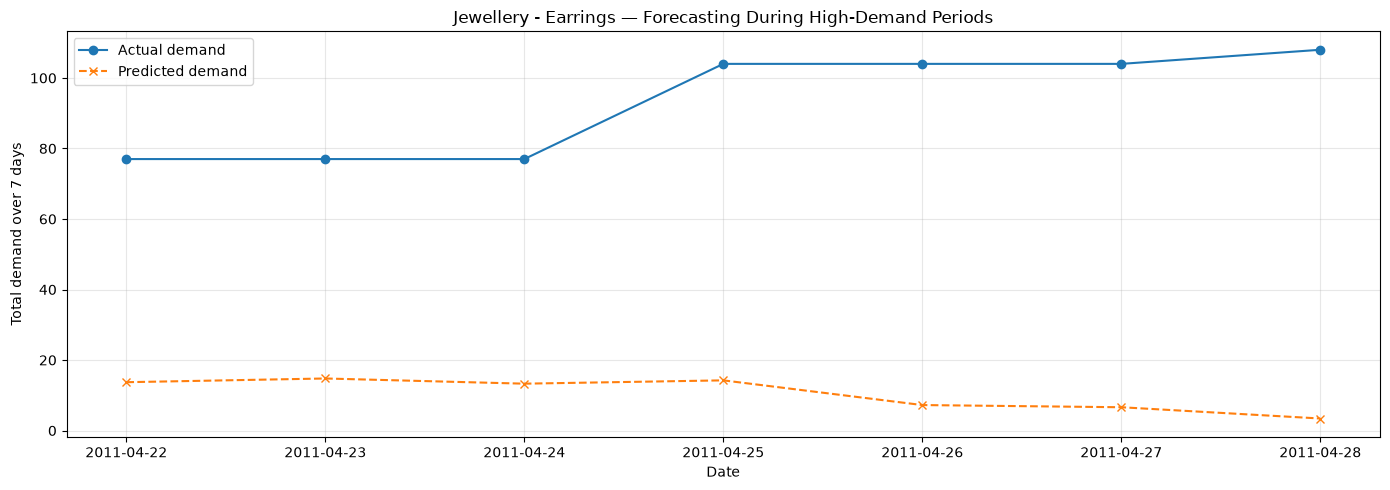

In [107]:

# Visualize high-demand forecasting performance

high_demand = error_df[
    error_df["Demand_Regime"] == "High demand"
].copy()

high_demand = high_demand.sort_values("Date")

plt.figure(figsize=(14, 5))

plt.plot(
    high_demand["Date"],
    high_demand["Actual"],
    marker="o",
    label="Actual demand"
)

plt.plot(
    high_demand["Date"],
    high_demand["Predicted"],
    marker="x",
    linestyle="--",
    label="Predicted demand"
)

plt.title(
    f"{CATEGORY} — Forecasting During High-Demand Periods"
)

plt.xlabel("Date")
plt.ylabel("Total demand over 7 days")

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


### Step 14.5: Temporal Analysis of Forecasting Errors

Aggregate error statistics do not indicate whether forecasting errors are distributed uniformly over time or concentrated in specific periods.

We therefore examine the temporal evolution of the signed and absolute forecasting errors.

This analysis aims to identify:

1. Periods characterized by persistent underestimation or overestimation.
2. Episodes of unusually large forecasting errors.
3. Potential changes in the magnitude of forecasting errors over time.

The observations are sorted chronologically before visualization.

The plotted dates correspond to the forecast reference dates. Each forecast predicts total demand over a future 7-day window.

As the current evaluation uses a stratified block split, the plotted observations do not necessarily form one continuous chronological test period.

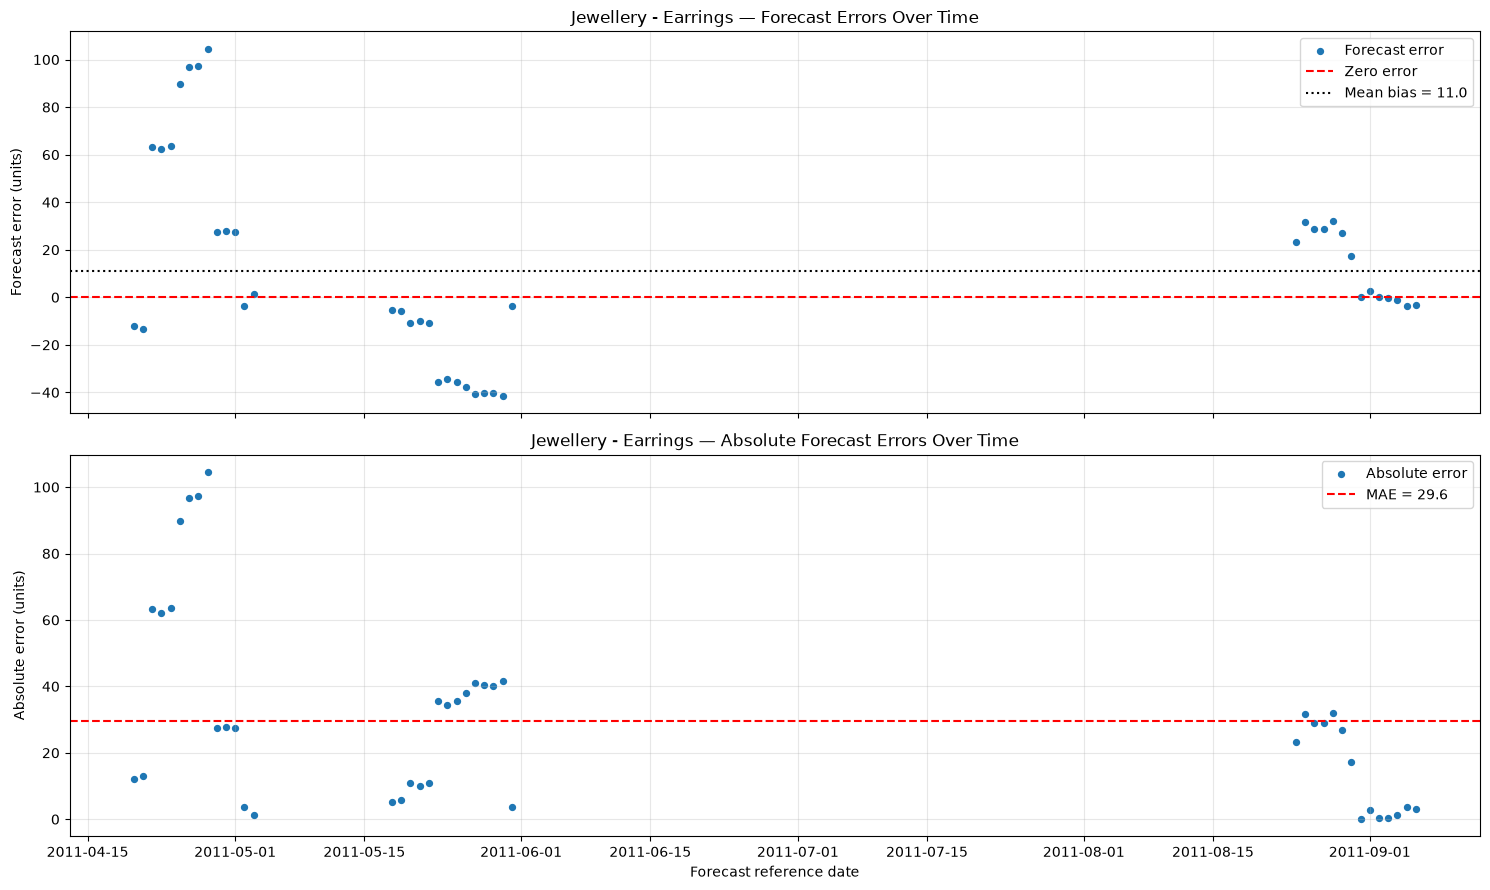

In [110]:

# Step 14.5 — Temporal forecasting error analysis

fig, axes = plt.subplots(
    2, 1,
    figsize=(15, 9),
    sharex=True
)

# Signed errors over time
axes[0].scatter(
    error_df["Date"],
    error_df["Error"],
    s=18,
    label="Forecast error"
)

axes[0].axhline(
    0,
    color="red",
    linestyle="--",
    label="Zero error"
)

axes[0].axhline(
    mean_bias,
    color="black",
    linestyle=":",
    label=f"Mean bias = {mean_bias:.1f}"
)

axes[0].set_title(
    f"{CATEGORY} — Forecast Errors Over Time"
)

axes[0].set_ylabel(
    "Forecast error (units)"
)

axes[0].legend()
axes[0].grid(alpha=0.3)


# Absolute errors over time
axes[1].scatter(
    error_df["Date"],
    error_df["Absolute_Error"],
    s=18,
    label="Absolute error"
)

axes[1].axhline(
    mae,
    color="red",
    linestyle="--",
    label=f"MAE = {mae:.1f}"
)

axes[1].set_title(
    f"{CATEGORY} — Absolute Forecast Errors Over Time"
)

axes[1].set_xlabel("Forecast reference date")
axes[1].set_ylabel("Absolute error (units)")

axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Step 14.6: Interpretation of the Forecast Error Analysis

The error analysis reveals an important asymmetry in the forecasting
performance for the Jewellery - Earrings category.

The selected XGBoost model achieved a validation WAPE of 65.80%, but its
test WAPE increased to 110.45%, indicating substantial variability in
out-of-sample performance.

On the test set, the mean observed demand was 26.81 units over the
7-day forecasting window, whereas the mean predicted demand was only
15.77 units. The MAE was 29.61 units and the RMSE was 40.79 units.
The higher RMSE relative to the MAE indicates that a subset of forecasts
contains particularly large errors.

Although underestimation and overestimation each occur in 50% of the
test observations, their magnitudes are not symmetric. The mean forecast
error is +11.04 units, corresponding to a relative bias of +41.19%.
Therefore, large underestimations dominate the total forecasting bias.

This behaviour becomes particularly clear during high-demand periods.
For observations above the 90th percentile of demand, actual demand
averages 93.00 units, while predicted demand averages only 10.47 units.
The corresponding MAE increases to 82.53 units, and all high-demand
observations are underestimated.

In comparison, regular-demand observations have a MAE of 19.03 units
and a small negative mean bias of -3.25 units.

Interestingly, WAPE is lower during high-demand periods (88.75%) than
during regular-demand periods (140.20%), despite the much larger absolute
errors during demand peaks. This occurs because WAPE is normalized by
the total observed demand. When demand is low, relatively moderate
absolute errors can therefore generate very large percentage errors.

Consequently, WAPE should not be interpreted in isolation. For this
category, MAE, RMSE, forecast bias, and peak-demand errors provide
important complementary information about the operational forecasting
performance.

The results suggest that the main weakness of the current model is not
simply general prediction noise, but its inability to anticipate large
increases in demand. The next analysis therefore investigates which
historical demand characteristics may explain these forecasting errors.

## Step 15: What Drives Forecast Errors?

Step 14 showed that the selected model performs particularly poorly during
high-demand periods.

For the Jewellery - Earrings category, the model strongly underestimates
demand peaks, while errors are much smaller during regular-demand periods.

The next objective is therefore to investigate whether large forecasting
errors are associated with identifiable characteristics of the historical
demand available at prediction time.

Importantly, this analysis does not introduce new features yet. It first
examines the features already available in the forecasting pipeline.

The analysis focuses on three questions:

1. Which existing historical-demand features are most strongly associated
   with forecast errors?
2. Do forecasting errors increase when recent demand is more volatile?
3. Does the model fail particularly when future demand increases sharply
   relative to recent historical demand?

Because this analysis uses the existing test observations, it should be
interpreted as diagnostic and exploratory. Any model modification motivated
by these findings must subsequently be evaluated on data that were not used
to formulate the hypothesis.

### Step 15.1: Link Historical Features to Forecast Errors

The forecasting pipeline already contains several variables describing
recent demand behaviour, including rolling means, rolling standard
deviations, rolling maxima, weekly averages, and calendar information.

We attach these existing explanatory variables to the prediction errors
constructed in Step 14.

Only variables already generated by the forecasting pipeline are used here.
No future demand information is introduced as a predictor.

In [117]:
# Step 15.1 — Attach existing features to the forecast errors

# Keep only features that are actually available in the current dataset
diagnostic_features = [
    f for f in features
    if f in test.columns
]

print(f"Available diagnostic features: {len(diagnostic_features)}")

# Check that each test date is unique
assert test["Date"].is_unique, "Test set contains duplicate dates."

# Merge feature values with forecast errors
diagnostic_df = error_df.merge(
    test[["Date"] + diagnostic_features],
    on="Date",
    how="left",
    validate="one_to_one"
)

print("Diagnostic dataset shape:", diagnostic_df.shape)

display(
    diagnostic_df[
        ["Date", "Actual", "Predicted", "Error", "Absolute_Error"]
        + diagnostic_features[:8]
    ].head()
)

Available diagnostic features: 30
Diagnostic dataset shape: (42, 38)


,Date,Actual,Predicted,Error,Absolute_Error,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,lag_7,lag_14
0,2011-04-20,1.0,13.033189,-12.033189,12.033189,0.0,7.0,0.0,0.0,0.0,0.0,4.0,2.0
1,2011-04-21,0.0,13.149487,-13.149487,13.149487,0.0,0.0,7.0,0.0,0.0,0.0,0.0,1.0
2,2011-04-22,77.0,13.713058,63.286942,63.286942,2.0,0.0,0.0,7.0,0.0,0.0,0.0,0.0
3,2011-04-23,77.0,14.768140,62.231860,62.231860,0.0,2.0,0.0,0.0,7.0,0.0,0.0,0.0
4,2011-04-24,77.0,13.295698,63.704302,63.704302,0.0,0.0,2.0,0.0,0.0,7.0,0.0,2.0


### Step 15.2: Association Between Existing Features and Forecast Errors

To identify potential error drivers, Spearman rank correlations are computed
between the existing explanatory variables and two measures of forecasting
error:

- Signed error: \(e_t = y_t - \hat{y}_t\)
- Absolute error: \(|e_t|\)

The signed error indicates whether a feature is associated with systematic
underestimation or overestimation.

The absolute error measures whether forecasting accuracy deteriorates as the
feature changes.

Spearman correlation is used because the test sample is small and the
relationships between demand characteristics and forecasting errors may be
nonlinear.

These correlations are exploratory associations and should not be interpreted
as causal effects.

In [340]:
# Step 15.2 — Spearman associations with forecast errors

correlation_rows = []
for feature in diagnostic_features:
    if not pd.api.types.is_numeric_dtype(diagnostic_df[feature]):
        continue
    valid=diagnostic_df[[feature, "Error", "Absolute_Error"]].dropna()
    
    if len(valid) < 5:
        continue
    # Skip constant variables
    if valid[feature].nunique() <= 1:
        continue

    rho_error=valid[feature].corr(valid["Error"], method="spearman")
    rho_abs_error=valid[feature].corr(valid["Absolute_Error"], method="spearman")

    correlation_rows.append({
        "Feature": feature,
        "Spearman rho with Error": rho_error,
        "Spearman rho with Absolute Error": rho_abs_error,
        "Abs rho with Absolute Error": abs(rho_abs_error)
    })

error_correlations = (
    pd.DataFrame(correlation_rows).sort_values("Abs rho with Absolute Error", ascending=False)
    .reset_index(drop=True)
)
display(error_correlations.head(15).round(3))

,Feature,Spearman rho with Error,Spearman rho with Absolute Error,Abs rho with Absolute Error
0,month,-0.147,-0.625,0.625
1,weekly_mean_3,-0.263,0.420,0.420
2,weekly_mean_4,-0.171,-0.321,0.321
3,lag_28,-0.007,-0.261,0.261
4,rolling_max_28,-0.765,-0.216,0.216
5,is_holiday,0.123,0.180,0.180
6,rolling_std_28,-0.736,-0.160,0.160
7,rolling_max_14,-0.744,-0.156,0.156
8,lag_2,-0.161,-0.155,0.155
9,lag_1,-0.039,-0.119,0.119


### Step 15.3: Visual Inspection of the Strongest Error Associations

The variables with the strongest associations with absolute forecasting error
are visualized directly.

The objective is to determine whether the correlation is driven by a genuine
pattern across observations or only by a small number of extreme points.

The plots therefore complement the rank-correlation analysis rather than
replace it.

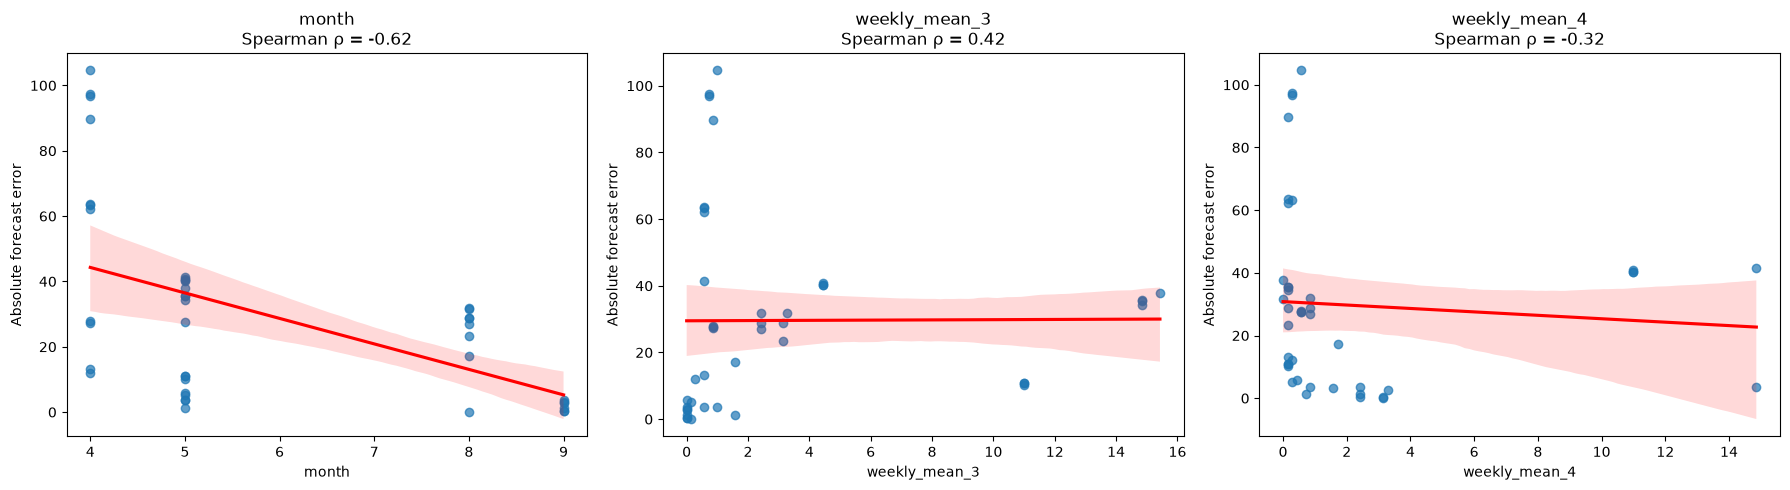

In [342]:
# Step 15.3 — Plot the three strongest associations

top_error_features=(error_correlations.head(3)["Feature"].tolist())
fig, axes=plt.subplots(1, len(top_error_features), figsize=(6 * len(top_error_features), 5))

if len(top_error_features) == 1:
    axes=[axes]

for ax, feature in zip(axes, top_error_features):
    sns.regplot(
        data=diagnostic_df,
        x=feature,
        y="Absolute_Error",
        scatter_kws={"alpha": 0.7},
        line_kws={"color": "red"},
        ax=ax
    )

    rho=diagnostic_df[[feature, "Absolute_Error"]].corr(method="spearman").iloc[0, 1]
    ax.set_title(f"{feature}\nSpearman ρ = {rho:.2f}")
    ax.set_ylabel("Absolute forecast error")
plt.tight_layout()
plt.show()

### Step 15.4: Forecast Performance Across Demand-Volatility Regimes

The feature-relevance analysis in Step 11 ranked rolling demand volatility
among the most informative variables for the Jewellery - Earrings category.

We therefore examine whether forecasting performance changes across different
levels of recent demand volatility.

The test observations are divided into three equally sized groups according
to the value of `rolling_std_28`:

- Low volatility
- Medium volatility
- High volatility

For each regime, MAE, WAPE, mean forecast bias, and the underestimation rate
are computed.

If the model performs substantially worse during high-volatility periods,
this would support the hypothesis that unstable demand is a major source of
forecasting error.

In [344]:
# Step 15.4 — Error statistics by volatility regime

VOLATILITY_FEATURE = "rolling_std_28"

if VOLATILITY_FEATURE not in diagnostic_df.columns:
    raise ValueError(
        f"{VOLATILITY_FEATURE} is not available in the current feature set."
    )

vol_df=diagnostic_df.dropna(subset=[VOLATILITY_FEATURE]).copy()

# Rank first to avoid problems caused by duplicate quantile boundaries
vol_df["Volatility_Regime"] = pd.qcut(
    vol_df[VOLATILITY_FEATURE].rank(method="first"), q=3,
    labels=["Low volatility", "Medium volatility", "High volatility"]
)

def compute_error_metrics(group):
    actual = group["Actual"]
    errors = group["Error"]

    return pd.Series({
        "N observations": len(group),
        "Mean actual demand": actual.mean(),
        "Mean volatility": group[VOLATILITY_FEATURE].mean(),
        "MAE": errors.abs().mean(),
        "RMSE": np.sqrt(np.mean(errors ** 2)),
        "WAPE (%)": (
            100 * errors.abs().sum() / actual.abs().sum()
            if actual.abs().sum() > 0
            else np.nan
        ),
        "Mean Bias": errors.mean(),
        "Underestimation rate (%)": 100 * (errors > 0).mean()
    })

volatility_results=(
    vol_df.groupby("Volatility_Regime", observed=True).apply(compute_error_metrics)
)

display(volatility_results.round(2))

,N observations,Mean actual demand,Mean volatility,MAE,RMSE,WAPE (%),Mean Bias,Underestimation rate (%)
Volatility_Regime,,,,,,,,
Low volatility,14.0,54.00,1.56,49.34,61.18,91.37,45.22,78.57
Medium volatility,14.0,20.00,3.09,14.29,19.44,71.46,13.11,71.43
High volatility,14.0,6.43,16.16,25.20,29.50,392.03,-25.20,0.00


### Step 15.5: Forecast Errors During Sudden Demand Changes

The forecast plots suggest that the model may behave conservatively and
produce relatively smooth predictions.

To investigate this hypothesis, the future 7-day demand is compared with the
recent historical demand level.

The recent historical 7-day demand is approximated as:

$$
H_t = X \times \text{rolling\_mean\_7}_t
$$

where \(X=7\) is the forecasting-window length.

A demand jump is then defined as:

$$
J_t = y_t - H_t
$$

A large positive value of \(J_t\) indicates that future demand increased
substantially relative to the recent historical level.

If forecasting errors become strongly positive when \(J_t\) increases, this
would indicate that the model tends to underestimate sudden upward changes in
demand.

In [346]:
# Step 15.5 — Demand jump analysis

if "rolling_mean_7" not in diagnostic_df.columns:
    raise ValueError( "rolling_mean_7 is required for the demand-jump analysis.")

diagnostic_df["Recent_7d_Demand_Level"]=(X * diagnostic_df["rolling_mean_7"])

diagnostic_df["Demand_Jump"]=(
    diagnostic_df["Actual"] - diagnostic_df["Recent_7d_Demand_Level"]
)

rho_jump_error=diagnostic_df[["Demand_Jump", "Error"]].corr(method="spearman").iloc[0, 1]

rho_jump_abs_error=diagnostic_df[["Demand_Jump", "Absolute_Error"]].corr(method="spearman").iloc[0, 1]
print(f"Spearman correlation — Demand Jump vs Error: "f"{rho_jump_error:.3f}")
print(f"Spearman correlation — Demand Jump vs Absolute Error: " f"{rho_jump_abs_error:.3f}")

Spearman correlation — Demand Jump vs Error: 0.840
Spearman correlation — Demand Jump vs Absolute Error: 0.362


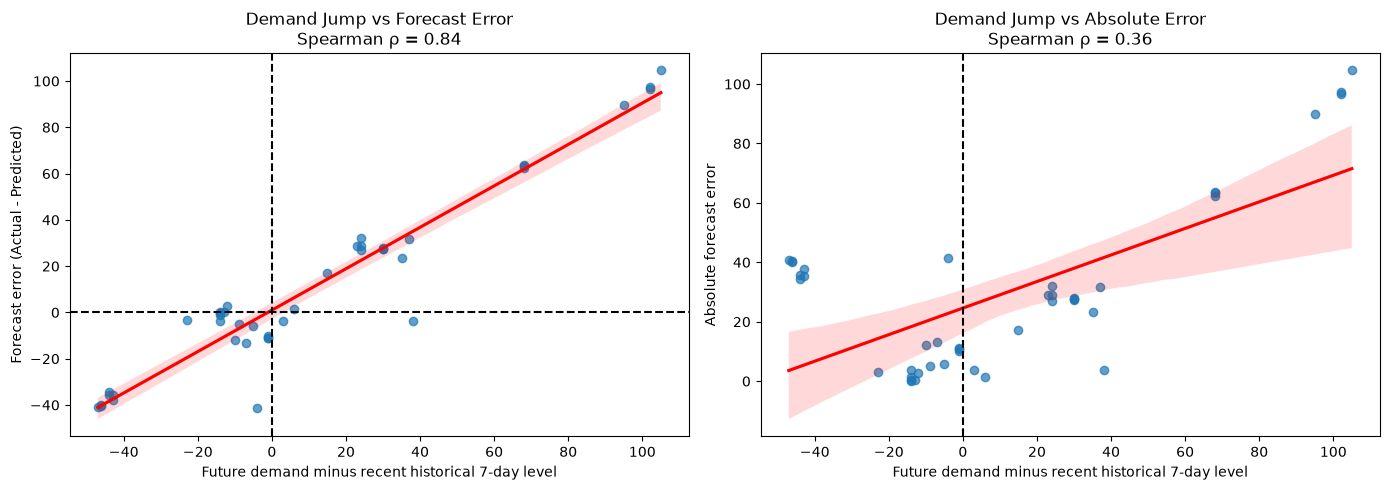

In [348]:
# Visualize demand jumps and forecasting errors

fig, axes=plt.subplots(1, 2, figsize=(14, 5))

sns.regplot(data=diagnostic_df,
    x="Demand_Jump",
    y="Error",
    scatter_kws={"alpha": 0.7},
    line_kws={"color": "red"},
    ax=axes[0]
)
axes[0].axhline(0, linestyle="--", color="black")
axes[0].axvline(0, linestyle="--", color="black")
axes[0].set_title(
    f"Demand Jump vs Forecast Error\n"
    f"Spearman ρ = {rho_jump_error:.2f}"
)
axes[0].set_xlabel("Future demand minus recent historical 7-day level")
axes[0].set_ylabel("Forecast error (Actual - Predicted)")
sns.regplot(
    data=diagnostic_df,
    x="Demand_Jump",
    y="Absolute_Error",
    scatter_kws={"alpha": 0.7},
    line_kws={"color": "red"},
    ax=axes[1]
)
axes[1].axvline(0, linestyle="--", color="black")
axes[1].set_title(
    f"Demand Jump vs Absolute Error\n"
    f"Spearman ρ = {rho_jump_abs_error:.2f}"
)

axes[1].set_xlabel("Future demand minus recent historical 7-day level")
axes[1].set_ylabel("Absolute forecast error")
plt.tight_layout()
plt.show()

### Step 15.6: Inspection of the Largest Forecasting Errors

The observations with the largest absolute forecasting errors are inspected
individually.

This helps determine whether the most severe prediction failures share common
characteristics such as:

- unusually large demand jumps;
- high recent volatility;
- unusually high recent maxima;
- or specific calendar periods.

The objective is not to draw conclusions from individual observations, but to
identify recurring patterns that can motivate the next controlled experiment.

In [350]:
# Step 15.6 — Inspect the largest errors

columns_to_show = [
    "Date",
    "Actual",
    "Predicted",
    "Error",
    "Absolute_Error",
    "Demand_Jump",
    "rolling_mean_7",
    "rolling_std_7",
    "rolling_std_28",
    "rolling_max_7",
    "rolling_max_28",
    "month"
]

columns_to_show=[c for c in columns_to_show if c in diagnostic_df.columns]
worst_errors=(diagnostic_df.sort_values("Absolute_Error", ascending=False)[columns_to_show].head(10))
display(worst_errors.round(2))

C:\Users\user\AppData\Local\Temp\ipykernel_20484\1100337134.py:20: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  display(worst_errors.round(2))


,Date,Actual,Predicted,Error,Absolute_Error,Demand_Jump,rolling_mean_7,rolling_std_7,rolling_std_28,rolling_max_7,rolling_max_28,month
8,2011-04-28,108.0,3.420000,104.58,104.58,105.0,0.43,0.79,1.55,2.0,7.0,4
7,2011-04-27,104.0,6.610000,97.39,97.39,102.0,0.29,0.76,1.56,2.0,7.0,4
6,2011-04-26,104.0,7.230000,96.77,96.77,102.0,0.29,0.76,1.56,2.0,7.0,4
5,2011-04-25,104.0,14.240000,89.76,89.76,95.0,1.29,2.63,1.56,7.0,7.0,4
4,2011-04-24,77.0,13.300000,63.70,63.70,68.0,1.29,2.63,1.56,7.0,7.0,4
2,2011-04-22,77.0,13.710000,63.29,63.29,68.0,1.29,2.63,1.55,7.0,7.0,4
3,2011-04-23,77.0,14.770000,62.23,62.23,68.0,1.29,2.63,1.56,7.0,7.0,4
26,2011-05-30,4.0,45.500000,-41.50,41.50,-4.0,1.14,1.95,16.70,4.0,77.0,5
23,2011-05-27,3.0,43.869999,-40.87,40.87,-47.0,7.14,15.49,16.70,42.0,77.0,5
24,2011-05-28,4.0,44.290001,-40.29,40.29,-46.0,7.14,15.49,16.70,42.0,77.0,5


## Step 16: Robustness Check Using Non-Overlapping Forecast Windows

The forecasting targets used in the previous analysis are constructed from
7-day demand windows.

Forecasts generated on consecutive reference dates therefore have strongly
overlapping target periods. As a result, a single demand event may appear
several times in the error analysis.

This dependence is particularly important when interpreting the large errors
observed during demand spikes.

To test whether the conclusions of Step 15 are robust, this section constructs
a subset of forecasts whose target windows do not overlap.

For a forecast issued at date \(t\), the target interval is:

\[
[t+Y,\;t+Y+X-1]
\]

with \(X=7\) and \(Y=7\).

Forecast observations are selected chronologically so that no two retained
target windows overlap.

The objective is to determine whether the association between abrupt demand
changes and forecast errors remains visible after removing duplicated exposure
to the same future demand events.

In [352]:
# Step 16.1 — Construct non-overlapping forecast windows

robust_df = diagnostic_df.copy()
robust_df["Target_Start"]=(robust_df["Date"]+pd.to_timedelta(Y, unit="D"))
robust_df["Target_End"]=(robust_df["Date"]+pd.to_timedelta(Y + X - 1, unit="D"))
robust_df = robust_df.sort_values("Target_Start").reset_index(drop=True)

selected_indices=[]
last_target_end=None

for idx, row in robust_df.iterrows():
    if (last_target_end is None or row["Target_Start"] > last_target_end):
        selected_indices.append(idx)
        last_target_end = row["Target_End"]
independent_df=(robust_df.loc[selected_indices].reset_index(drop=True))

print("Original test observations:", len(robust_df))
print("Independent forecast windows:", len(independent_df))
display(independent_df[[ "Date",
            "Target_Start",
            "Target_End",
            "Actual",
            "Predicted",
            "Error",
            "Demand_Jump"]]
)

Original test observations: 42
Independent forecast windows: 6


,Date,Target_Start,Target_End,Actual,Predicted,Error,Demand_Jump
0,2011-04-20,2011-04-27,2011-05-03,1.0,13.033189,-12.033189,-10.0
1,2011-04-27,2011-05-04,2011-05-10,104.0,6.610616,97.389384,102.0
2,2011-05-18,2011-05-25,2011-05-31,0.0,5.143320,-5.143320,-9.0
3,2011-05-25,2011-06-01,2011-06-07,6.0,41.618286,-35.618286,-44.0
4,2011-08-24,2011-08-31,2011-09-06,35.0,11.676814,23.323186,35.0
5,2011-08-31,2011-09-07,2011-09-13,7.0,6.972132,0.027868,-14.0


### Step 16.2: Performance on Independent Forecast Windows

The forecasting metrics are recomputed using only the non-overlapping
forecast windows.

Because the resulting sample is considerably smaller, these results should
not be interpreted as precise performance estimates.

Instead, the objective is to verify whether the qualitative error pattern
identified previously remains visible when overlapping target windows are
removed.

In [354]:
# Step 16.2 — Metrics on independent windows

actual_ind = independent_df["Actual"]
error_ind = independent_df["Error"]

independent_metrics = pd.Series({
    "N independent windows": len(independent_df),
    "Mean actual demand": actual_ind.mean(),
    "Mean predicted demand": independent_df["Predicted"].mean(),
    "MAE": error_ind.abs().mean(),
    "RMSE": np.sqrt(np.mean(error_ind ** 2)),
    "WAPE (%)": (100 *error_ind.abs().sum()/actual_ind.abs().sum() if actual_ind.abs().sum()>0 else np.nan),
    "Mean Bias": error_ind.mean(),
    "Underestimation rate (%)": 100*(error_ind>0).mean()
})
display(independent_metrics.to_frame("Value").round(2))

,Value
N independent windows,6.00
Mean actual demand,25.50
Mean predicted demand,14.18
MAE,28.92
RMSE,43.72
WAPE (%),113.42
Mean Bias,11.32
Underestimation rate (%),50.00


In [356]:
# Step 16.3 — Demand-jump relationship without overlapping targets

rho_ind_error=independent_df[["Demand_Jump", "Error"]].corr(method="spearman").iloc[0, 1]
rho_ind_abs=independent_df[["Demand_Jump", "Absolute_Error"]].corr(method="spearman").iloc[0, 1]
print("Independent windows — " f"Demand Jump vs Error: {rho_ind_error:.3f}")
print("Independent windows — " f"Demand Jump vs Absolute Error: {rho_ind_abs:.3f}")

Independent windows — Demand Jump vs Error: 0.829
Independent windows — Demand Jump vs Absolute Error: 0.371


### Step 16.4: Interpretation

Removing overlapping target windows reduces the evaluation sample from 42
observations to only 6 independent forecasting windows.

Despite this substantial reduction, the overall forecasting performance
remains similar to that observed on the complete test sample. The MAE is
28.92 units, the WAPE is 113.42%, and the mean forecast bias remains positive
at 11.32 units.

Most importantly, the relationship between abrupt demand changes and signed
forecast errors remains strong. The Spearman correlation between Demand Jump
and forecast error is 0.829, compared with 0.840 when overlapping windows were
included.

This indicates that the previously observed relationship is not solely caused
by repeated overlapping exposure to the same demand event.

The model therefore appears to systematically react too slowly to abrupt
changes in demand: it tends to underestimate demand when future sales rise
sharply relative to recent historical levels and to overestimate demand after
demand decreases.

However, only six independent forecast windows remain after removing overlap.
The magnitude of the correlation must therefore be interpreted cautiously.
The result provides evidence for the direction of the error pattern, rather
than a precise estimate of its strength.

## Step 17: Sensitivity to the Selection of Non-Overlapping Windows

The previous robustness check selected the earliest available forecast and
then iteratively removed overlapping target windows.

Because several alternative sets of non-overlapping forecasts can be formed,
the resulting correlation may depend on the particular starting observation.

This section repeats the non-overlapping-window analysis using different
starting positions.

For each starting position, the following statistics are computed:

- Number of retained independent forecasts.
- MAE.
- WAPE.
- Mean forecast bias.
- Spearman correlation between Demand Jump and signed forecast error.
- Spearman correlation between Demand Jump and absolute forecast error.

The objective is to determine whether the qualitative relationship identified
in Steps 15 and 16 is stable across alternative non-overlapping subsets.

In [360]:
def select_non_overlapping_windows(df, start_position=0):
    ordered=(df.sort_values("Target_Start").reset_index(drop=True))
    selected=[]
    last_target_end=None
    for idx in range(start_position, len(ordered)):
        row = ordered.iloc[idx]
        if (last_target_end is None or row["Target_Start"] > last_target_end):
            selected.append(idx)
            last_target_end = row["Target_End"]
    return ordered.iloc[selected].copy()

sensitivity_rows = []

# Try the first seven possible starting positions
for start in range(min(X, len(robust_df))):
    subset=select_non_overlapping_windows(robust_df, start_position=start)
    # Need enough observations for a meaningful rank correlation
    if len(subset) < 4:
        continue
    actual=subset["Actual"]
    error=subset["Error"]
    rho_error=subset[ ["Demand_Jump", "Error"]].corr(method="spearman").iloc[0, 1]
    rho_abs=subset[["Demand_Jump", "Absolute_Error"]].corr(method="spearman").iloc[0, 1]

    sensitivity_rows.append({
        "Starting position": start,
        "N windows": len(subset),
        "MAE": error.abs().mean(),
        "WAPE (%)": (
            100 * error.abs().sum() / actual.abs().sum()
            if actual.abs().sum() > 0
            else np.nan
        ),
        "Mean Bias": error.mean(),
        "rho Demand Jump vs Error": rho_error,
        "rho Demand Jump vs Absolute Error": rho_abs
    })


window_sensitivity=pd.DataFrame(sensitivity_rows)
display(window_sensitivity.round(3))

,Starting position,N windows,MAE,WAPE (%),Mean Bias,rho Demand Jump vs Error,rho Demand Jump vs Absolute Error
0,0,6,28.923,113.422,11.324,0.829,0.371
1,1,6,30.308,116.568,12.337,0.771,0.429
2,2,6,25.800,99.230,12.212,0.886,0.371
3,3,6,25.706,98.868,12.118,0.886,0.371
4,4,6,25.893,99.587,12.306,0.886,0.371
5,5,6,26.257,100.988,11.448,0.829,0.371
6,6,6,27.037,102.026,13.450,0.943,0.371


In [362]:
print(
    "\nDemand Jump vs Error — "
    f"median rho: "
    f"{window_sensitivity['rho Demand Jump vs Error'].median():.3f}"
)

print(
    "Demand Jump vs Error — "
    f"min/max rho: "
    f"{window_sensitivity['rho Demand Jump vs Error'].min():.3f} / "
    f"{window_sensitivity['rho Demand Jump vs Error'].max():.3f}"
)


Demand Jump vs Error — median rho: 0.886
Demand Jump vs Error — min/max rho: 0.771 / 0.943


### Step 17.1: Interpretation

The sensitivity analysis confirms that the relationship between abrupt demand
changes and directional forecast errors is robust to the choice of
non-overlapping forecast windows.

Across the seven alternative starting positions, the Spearman correlation
between Demand Jump and signed forecast error remains strongly positive,
ranging from 0.771 to 0.943, with a median value of 0.886.

This stability supports the qualitative conclusion obtained in Steps 15 and
16: the forecasting model reacts too slowly to abrupt changes in demand.

When future demand increases substantially relative to recent historical
levels, the model tends to underestimate demand. Conversely, after demand
falls relative to previously elevated levels, the model tends to overestimate
demand.

The association with absolute error is considerably weaker, remaining around
0.37–0.43. This suggests that the main effect concerns the direction of the
forecast error rather than simply its magnitude.

Forecast performance is also relatively stable across the alternative subsets,
with MAE values between approximately 25.7 and 30.3 units.

These alternative subsets are not statistically independent, since they share
many observations. The analysis should therefore be interpreted as a
sensitivity check rather than as independent replication.

Nevertheless, the consistency of the directional relationship provides a
clear hypothesis for the next modelling experiment.

## Step 18: Regime-Change Feature Experiment

The previous diagnostic analyses indicate that the main forecasting failure is
associated with abrupt changes in demand.

The current feature set already contains rolling means, standard deviations,
and maxima over different historical windows. However, these variables mostly
describe the level and variability of demand separately.

To make changes in the demand regime more explicit, this experiment introduces
features comparing short-term and longer-term historical demand.

The proposed features are:

1. Difference between the 7-day and 28-day rolling means.
2. Ratio between the 7-day and 28-day rolling means.
3. Ratio between short-term and long-term demand volatility.
4. Ratio between recent and longer-term maximum demand.

All variables are constructed exclusively from historical information already
available at the forecast date.

The objective is to test whether explicitly representing recent regime changes
improves the ability of the model to adapt to changing demand conditions.

The experiment compares the original XGBoost specification with an augmented
XGBoost model using the same train, validation, and test observations.

In [364]:
# Step 18.1 — Regime-change features

def add_regime_features(df):
    df=df.copy()
    df["mean_diff_7_28"]=(df["rolling_mean_7"]-df["rolling_mean_28"])
    df["mean_ratio_7_28"]=((df["rolling_mean_7"] + 1) / (df["rolling_mean_28"] + 1))
    df["volatility_ratio_7_28"]=((df["rolling_std_7"] + 1) / (df["rolling_std_28"] + 1))
    df["max_ratio_7_28"] = ((df["rolling_max_7"] + 1) / (df["rolling_max_28"] + 1))
    return df
train_aug = add_regime_features(train)
validation_aug = add_regime_features(validation)
test_aug = add_regime_features(test)

regime_features = ["mean_diff_7_28", "mean_ratio_7_28", "volatility_ratio_7_28", "max_ratio_7_28"]
augmented_features=(features + regime_features)
display(train_aug[regime_features].describe().round(3))

,mean_diff_7_28,mean_ratio_7_28,volatility_ratio_7_28,max_ratio_7_28
count,235.000,235.000,235.000,235.000
mean,0.645,1.035,0.819,0.524
std,5.506,0.645,0.519,0.377
min,-13.821,0.147,0.056,0.013
25%,-1.679,0.508,0.353,0.139
50%,-0.214,0.897,0.685,0.455
75%,0.964,1.333,1.305,1.000
max,36.679,3.151,1.939,1.000


### Step 18.2: Controlled Comparison of the Original and Augmented Models

To isolate the effect of the regime-change features, the original XGBoost
model and the augmented XGBoost model are trained using exactly the same:

- training observations;
- validation observations;
- test observations;
- target variable;
- model specification and hyperparameters.

The only difference between the two models is the addition of the four
regime-change variables introduced in Step 18.1.

This controlled comparison allows us to assess whether explicitly representing
short-term changes relative to longer-term demand improves forecasting
performance.

Because the additional features were motivated by patterns observed in the
current test set, the comparison on this split should be interpreted as an
exploratory experiment rather than final evidence of improved generalization.
A repeated evaluation on alternative splits will be performed afterwards.

In [366]:
# Step 18.2 — Original vs augmented XGBoost

MODEL_NAME = "XGBoost"

# Original model
_, val_pred_original, test_pred_original = (
    mdl.MODELS[MODEL_NAME](
        train,
        validation,
        test,
        features,
        target_col
    )
)
# Augmented model
_, val_pred_augmented, test_pred_augmented = (
    mdl.MODELS[MODEL_NAME](
        train_aug,
        validation_aug,
        test_aug,
        augmented_features,
        target_col
    )
)
# Ensure non-negative demand forecasts
val_pred_original=np.maximum(np.asarray(val_pred_original).reshape(-1), 0)
test_pred_original=np.maximum(np.asarray(test_pred_original).reshape(-1), 0)
val_pred_augmented=np.maximum(np.asarray(val_pred_augmented).reshape(-1), 0)
test_pred_augmented=np.maximum(np.asarray(test_pred_augmented).reshape(-1), 0)

In [368]:
# Step 18.3 — Evaluation helper

def calculate_metrics(actual, predicted):
    actual = np.asarray(actual)
    predicted = np.asarray(predicted)
    error = actual - predicted
    return {
        "MAE": np.mean(np.abs(error)),
        "RMSE": np.sqrt(np.mean(error ** 2)),
        "WAPE (%)": (100 * np.sum(np.abs(error))/np.sum(np.abs(actual)) if np.sum(np.abs(actual))>0 else np.nan),
        "Mean Bias": np.mean(error),
        "Relative Bias (%)": (100*np.sum(error)/np.sum(actual) if np.sum(actual)!=0 else np.nan)
    }
comparison_rows = []
for model_label, val_pred, test_pred in [
    ("Original XGBoost", val_pred_original, test_pred_original),
    ("XGBoost + Regime Features", val_pred_augmented, test_pred_augmented)]:
    val_metrics=calculate_metrics(validation[target_col], val_pred)
    test_metrics=calculate_metrics(test[target_col], test_pred)
    comparison_rows.append({
        "Model": model_label,
        "Validation MAE": val_metrics["MAE"],
        "Validation WAPE (%)": val_metrics["WAPE (%)"],
        "Test MAE": test_metrics["MAE"],
        "Test RMSE": test_metrics["RMSE"],
        "Test WAPE (%)": test_metrics["WAPE (%)"],
        "Test Mean Bias": test_metrics["Mean Bias"],
        "Test Relative Bias (%)": test_metrics["Relative Bias (%)"]
    })
model_comparison=pd.DataFrame(comparison_rows)
display(model_comparison.round(2))

,Model,Validation MAE,Validation WAPE (%),Test MAE,Test RMSE,Test WAPE (%),Test Mean Bias,Test Relative Bias (%)
0,Original XGBoost,25.45,65.80,29.61,40.79,110.45,11.04,41.19
1,XGBoost + Regime Features,28.59,73.91,23.79,37.91,88.75,18.49,68.97


### Step 18.4: Performance During High-Demand Periods

The motivation for the new features is the systematic underestimation observed
during abrupt increases in demand.

Therefore, an improvement in overall WAPE alone would not be sufficient.

The two models are compared specifically on the high-demand observations
identified in Step 14.

The main quantities of interest are:

- high-demand MAE;
- high-demand mean bias;
- high-demand underestimation rate.

If the augmented model reduces these errors, this would indicate that the
regime-change features help the model respond more effectively to demand
surges.

In [370]:
# Step 18.4 — High-demand comparison
actual_test=test[target_col].to_numpy()
high_threshold=np.quantile(actual_test, 0.90)
high_mask=( actual_test >= high_threshold)

def high_demand_metrics(actual, predicted, mask):
    y=actual[mask]
    p=predicted[mask]
    error=y-p
    return {"N high-demand observations": len(y),
        "Mean actual demand": np.mean(y),
        "Mean predicted demand": np.mean(p),
        "High-demand MAE": np.mean(np.abs(error)),
        "High-demand Bias": np.mean(error),
        "Underestimation rate (%)": 100 * np.mean(error > 0)
    }
high_demand_results = pd.DataFrame([
    {"Model": "Original XGBoost", **high_demand_metrics(actual_test, test_pred_original, high_mask)},
    {"Model": "XGBoost + Regime Features",
        **high_demand_metrics(actual_test, test_pred_augmented, high_mask)
    }
])
display(high_demand_results.round(2))

,Model,N high-demand observations,Mean actual demand,Mean predicted demand,High-demand MAE,High-demand Bias,Underestimation rate (%)
0,Original XGBoost,7,93.0,10.47,82.53,82.53,100.0
1,XGBoost + Regime Features,7,93.0,9.29,83.71,83.71,100.0


### Step 18.5: Demand-Jump Sensitivity After Feature Augmentation

The previous analysis identified a strong positive association between abrupt
changes in demand and signed forecast errors.

To determine whether the augmented model addresses this weakness, we recompute
the correlation between Demand Jump and forecast error for both models.

A lower positive correlation for the augmented model would indicate that
forecast errors are less systematically linked to abrupt changes in demand.

This is particularly important because the purpose of the additional features
is not simply to reduce average error, but to improve the model's responsiveness
to changing demand regimes.

In [372]:
# Step 18.5 — Demand-jump sensitivity

jump_comparison=diagnostic_df[["Date", "Demand_Jump"]].copy()
jump_comparison["Original_Error"]=(actual_test-test_pred_original)
jump_comparison["Augmented_Error"]=(actual_test- test_pred_augmented)
rho_original=jump_comparison[["Demand_Jump", "Original_Error"]].corr( method="spearman").iloc[0, 1]
rho_augmented=jump_comparison[["Demand_Jump", "Augmented_Error"]].corr(method="spearman").iloc[0, 1]
print( "Original XGBoost — " f"Demand Jump vs Error: {rho_original:.3f}")
print("Augmented XGBoost — " f"Demand Jump vs Error: {rho_augmented:.3f}")
print("\nChange in correlation: " f"{rho_augmented - rho_original:+.3f}")

Original XGBoost — Demand Jump vs Error: 0.840
Augmented XGBoost — Demand Jump vs Error: 0.803

Change in correlation: -0.037


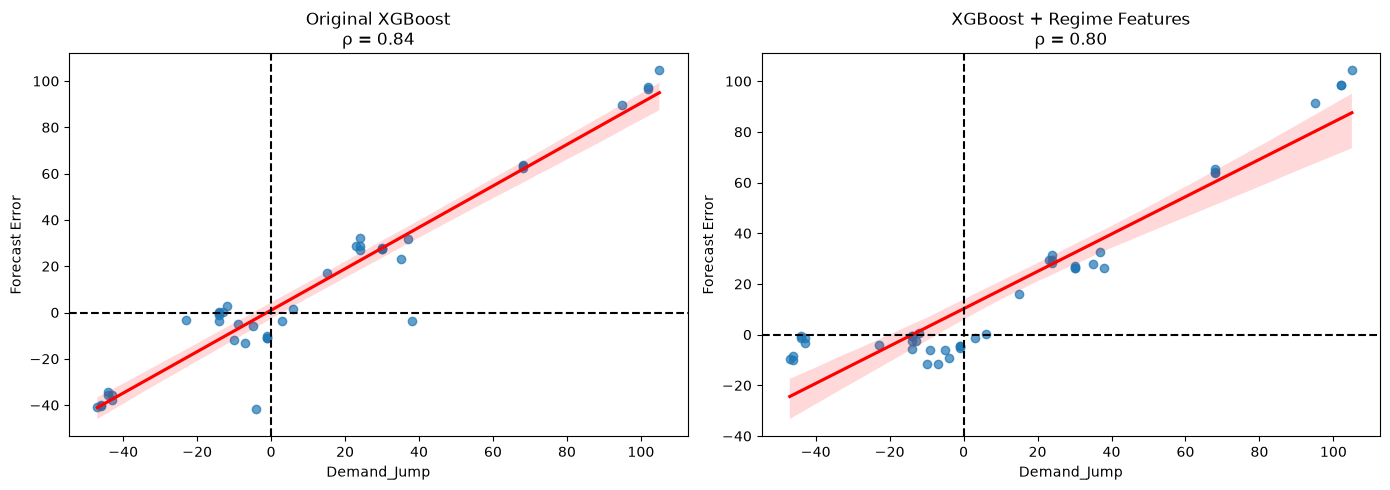

In [374]:
fig, axes=plt.subplots(1, 2, figsize=(14, 5))
sns.regplot(
    data=jump_comparison,
    x="Demand_Jump",
    y="Original_Error",
    scatter_kws={"alpha": 0.7},
    line_kws={"color": "red"},
    ax=axes[0]
)
axes[0].axhline(0, linestyle="--", color="black")
axes[0].axvline(0, linestyle="--", color="black")
axes[0].set_title(f"Original XGBoost\n" f"ρ = {rho_original:.2f}")
axes[0].set_ylabel("Forecast Error")
sns.regplot(
    data=jump_comparison,
    x="Demand_Jump",
    y="Augmented_Error",
    scatter_kws={"alpha": 0.7},
    line_kws={"color": "red"},
    ax=axes[1]
)

axes[1].axhline(0, linestyle="--", color="black")
axes[1].axvline(0, linestyle="--", color="black")

axes[1].set_title(
    f"XGBoost + Regime Features\n"
    f"ρ = {rho_augmented:.2f}"
)

axes[1].set_ylabel(
    "Forecast Error"
)

plt.tight_layout()
plt.show()

### Step 18.6: Interpretation

The regime-change features produced mixed results.

On the current test split, the augmented XGBoost model reduced MAE from
29.61 to 23.79 units and WAPE from 110.45% to 88.75%. However, validation
performance deteriorated, with validation WAPE increasing from 65.80% to
73.91%.

The improvement in aggregate test metrics therefore does not provide sufficient
evidence that the augmented specification generalizes better.

More importantly, the additional features did not improve performance during
high-demand periods. High-demand MAE increased slightly from 82.53 to 83.71
units, while all high-demand observations remained underestimated.

The relationship between Demand Jump and signed forecast error also remained
strong. The Spearman correlation decreased only from 0.840 to 0.803.

Therefore, although the regime-change features modify average forecasting
performance, they do not solve the specific failure mode identified in the
previous diagnostic analysis.

The current evidence does not support retaining these features as an improved
model specification without further robustness evaluation.

## Step 19: Repeated Evaluation of the Regime-Change Features

The single-split experiment in Step 18 produced conflicting evidence:
aggregate test metrics improved, while validation performance deteriorated
and high-demand forecasting remained poor.

To determine whether the apparent improvement is robust or specific to one
data split, the comparison is repeated across 30 stratified block splits.

For each random seed, the original and augmented XGBoost models are trained
and evaluated on exactly the same observations.

This paired design removes much of the variability caused by differences in
the data split and allows the effect of the additional features to be assessed
more directly.

The primary quantities of interest are the paired differences in:

- validation MAE;
- validation WAPE;
- test MAE;
- test WAPE;
- mean forecast bias.

Negative differences in MAE or WAPE indicate an improvement of the augmented
model relative to the original model.

In [376]:
# Step 19.1 — Repeated paired evaluation

CATEGORY="Jewellery - Earrings"
N_SEEDS=30
base_data=datasets[CATEGORY].copy()
repeated_feature_results=[]
for seed in range(N_SEEDS):
    s=spl.stratified_block_split(
        base_data,
        target_col,
        random_state=seed
    )
    tr=s["train"].copy()
    va=s["validation"].copy()
    te=s["test"].copy()
    # Original XGBoost
    _, val_orig, test_orig = mdl.MODELS["XGBoost"](
        tr, va, te, features, target_col)
    # Add regime features
    tr_aug = add_regime_features(tr)
    va_aug = add_regime_features(va)
    te_aug = add_regime_features(te)

    _, val_aug, test_aug = mdl.MODELS["XGBoost"](
        tr_aug, va_aug, te_aug, augmented_features, target_col
    )

    val_orig = np.maximum(np.asarray(val_orig).reshape(-1), 0)
    test_orig = np.maximum(np.asarray(test_orig).reshape(-1), 0)

    val_aug = np.maximum(np.asarray(val_aug).reshape(-1), 0)
    test_aug = np.maximum(np.asarray(test_aug).reshape(-1), 0)

    val_metrics_orig = calculate_metrics(va[target_col], val_orig)
    val_metrics_aug = calculate_metrics(va[target_col],val_aug)

    test_metrics_orig=calculate_metrics(te[target_col], test_orig)

    test_metrics_aug=calculate_metrics(te[target_col], test_aug)

    repeated_feature_results.append({
        "Seed": seed,
        "Validation MAE Original": val_metrics_orig["MAE"],
        "Validation MAE Augmented": val_metrics_aug["MAE"],
        "Validation WAPE Original": val_metrics_orig["WAPE (%)"],
        "Validation WAPE Augmented": val_metrics_aug["WAPE (%)"],
        "Test MAE Original": test_metrics_orig["MAE"],
        "Test MAE Augmented": test_metrics_aug["MAE"],
        "Test WAPE Original": test_metrics_orig["WAPE (%)"],
        "Test WAPE Augmented": test_metrics_aug["WAPE (%)"],
        "Test Bias Original": test_metrics_orig["Mean Bias"],
        "Test Bias Augmented": test_metrics_aug["Mean Bias"]
    })
paired_results = pd.DataFrame(repeated_feature_results)

In [378]:
# Step 19.2 — Paired differences

paired_results["Delta Validation MAE"]=(paired_results["Validation MAE Augmented"]-paired_results["Validation MAE Original"])
paired_results["Delta Validation WAPE"]=(paired_results["Validation WAPE Augmented"]
    - paired_results["Validation WAPE Original"]
)

paired_results["Delta Test MAE"]=(paired_results["Test MAE Augmented"]
    - paired_results["Test MAE Original"]
)
paired_results["Delta Test WAPE"]=(paired_results["Test WAPE Augmented"]
    - paired_results["Test WAPE Original"]
)
summary = pd.Series({
    "Mean Δ Validation MAE": paired_results["Delta Validation MAE"].mean(),
    "Mean Δ Validation WAPE": paired_results["Delta Validation WAPE"].mean(),
    "Mean Δ Test MAE": paired_results["Delta Test MAE"].mean(),
    "Mean Δ Test WAPE": paired_results["Delta Test WAPE"].mean(),
    "% seeds improved Validation WAPE":
        100*(paired_results["Delta Validation WAPE"]<0 ).mean(),
    "% seeds improved Test WAPE":
        100*(paired_results["Delta Test WAPE"]<0).mean()
})
display(summary.to_frame("Value").round(3))

,Value
Mean Δ Validation MAE,0.267
Mean Δ Validation WAPE,0.756
Mean Δ Test MAE,-0.086
Mean Δ Test WAPE,-0.273
% seeds improved Validation WAPE,30.000
% seeds improved Test WAPE,36.667


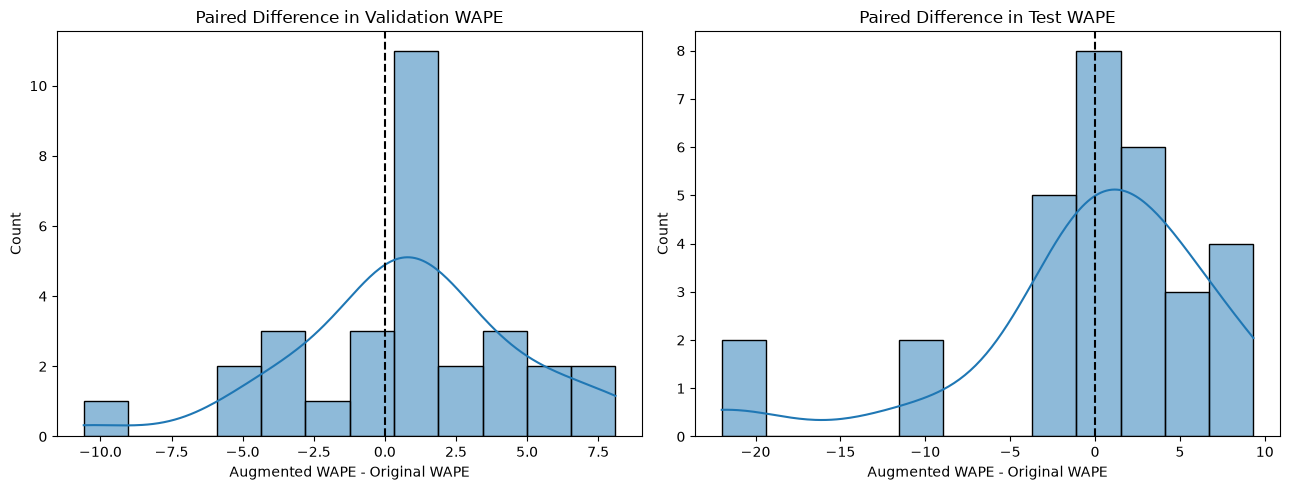

In [380]:
fig, axes=plt.subplots(1, 2, figsize=(13, 5))
sns.histplot(
    paired_results["Delta Validation WAPE"],
    bins=12,
    kde=True,
    ax=axes[0]
)
axes[0].axvline(0, linestyle="--", color="black")
axes[0].set_title("Paired Difference in Validation WAPE")
axes[0].set_xlabel("Augmented WAPE - Original WAPE")
sns.histplot(
    paired_results["Delta Test WAPE"],
    bins=12,
    kde=True,
    ax=axes[1]
)
axes[1].axvline(0, linestyle="--", color="black")
axes[1].set_title("Paired Difference in Test WAPE")
axes[1].set_xlabel("Augmented WAPE - Original WAPE")
plt.tight_layout()
plt.show()

### Step 19.3: Interpretation

The repeated paired evaluation does not support retaining the proposed
regime-change features.

Across the 30 matched data splits, the augmented model slightly worsened
validation performance on average. Validation MAE increased by 0.267 units
and validation WAPE increased by 0.756 percentage points.

Only 30% of the splits showed an improvement in validation WAPE.

On the test sets, the average differences were close to zero. Test MAE
decreased by only 0.086 units and test WAPE by 0.273 percentage points.
However, only 36.7% of the test splits showed an improvement in WAPE.

Therefore, the small average improvement on the test sets is not systematic.
It appears to be driven by a limited number of favourable splits rather than
a stable improvement in forecasting performance.

This result also explains why the substantial improvement observed on the
single split in Step 18 should not be interpreted as evidence that the new
features improve the model.

Overall, the proposed short-versus-long-term regime features do not provide
a robust improvement over the original XGBoost specification.

## Step 20: Are Demand Spikes Predictable Ex Ante?

The previous experiments identified a systematic forecasting failure:
the model tends to underestimate abrupt increases in demand and overestimate
demand after these increases disappear.

Additional regime-change features did not provide a robust improvement across
repeated data splits.

This raises a more fundamental question:

> Are abrupt future demand increases predictable from the information available
> at the forecast date?

If the historical feature set contains little information before a demand
surge occurs, improving the point forecasting model through additional lagged
sales features may have limited potential.

This section therefore investigates:

1. How many distinct upward-demand events occur in the available data.
2. Whether historical features differ before demand jumps and ordinary periods.
3. Whether a simple classifier can identify future demand jumps using only
   information available at the forecast date.

The purpose is not to build a production jump classifier, but to assess the
amount of predictive signal contained in the currently available covariates.

### Step 20.1: Definition of a Future Demand Jump

For each forecast reference date, recent historical demand is represented by
the average demand over the previous 7 days.

Because the forecasting target represents cumulative demand over a 7-day
window, the recent historical demand level is expressed on the same scale:

$$
H_t = 7 \times \text{rolling\_mean\_7}_t
$$

The future demand change is then defined as:

$$
J_t = y_t - H_t
$$

Large positive values of $J_t$ correspond to future demand that is substantially
higher than the recent historical level.

For exploratory analysis, a future jump is defined as an observation above the
90th percentile of the demand-jump distribution.

The future-jump indicator is used only as an outcome for diagnostic analysis.
It is never included as a forecasting feature.

In [382]:
# Step 20.1 — Define future demand jumps

CATEGORY = "Jewellery - Earrings"
jump_data=(datasets[CATEGORY].copy().sort_values("Date").reset_index(drop=True))
jump_data["Recent_7d_Demand_Level"]=(X* jump_data["rolling_mean_7"])
jump_data["Demand_Jump"]=(jump_data[target_col]-jump_data["Recent_7d_Demand_Level"])
# Define a large positive future jump
jump_threshold=max(jump_data["Demand_Jump"].quantile(0.90), 0)
jump_data["Future_Jump"]=(jump_data["Demand_Jump"] >= jump_threshold).astype(int)
print(f"Jump threshold: {jump_threshold:.2f} units")
print(
    f"Jump observations: "
    f"{jump_data['Future_Jump'].sum()} / {len(jump_data)}"
)
print(
    f"Jump prevalence: "
    f"{100 * jump_data['Future_Jump'].mean():.2f}%"
)

Jump threshold: 48.00 units
Jump observations: 36 / 333
Jump prevalence: 10.81%


### Step 20.2: Identification of Distinct Demand-Jump Episodes

Because forecasting targets are constructed from overlapping 7-day windows,
a single underlying demand surge can generate several consecutive observations
classified as future jumps.

Counting these observations as independent events would overstate the amount
of information available for learning spike behaviour.

Consecutive jump observations are therefore grouped into demand-jump episodes.

The number of distinct episodes provides an indication of how many genuinely
different demand surges are available in the dataset.

In [384]:
# Step 20.2 — Identify distinct jump episodes

jump_rows=(jump_data[jump_data["Future_Jump"]==1].copy().sort_values("Date"))
# A new episode begins if the previous jump observation
# occurred more than one day earlier
jump_rows["New_Episode"]=(jump_rows["Date"].diff().dt.days.fillna(999).gt(1))
jump_rows["Episode"]=(jump_rows["New_Episode"].cumsum())
jump_episodes=(jump_rows.groupby("Episode")
    .agg(Start_Date=("Date", "min"),
        End_Date=("Date", "max"),
        N_Rows=("Date", "size"),
        Max_Demand_Jump=("Demand_Jump", "max"),
        Mean_Target_Demand=(target_col, "mean")
    ).reset_index(drop=True)
)
print("Number of distinct jump episodes:",len(jump_episodes))
display(jump_episodes.round(2))

Number of distinct jump episodes: 6


C:\Users\user\AppData\Local\Temp\ipykernel_20484\3459292647.py:17: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  display(jump_episodes.round(2))


,Start_Date,End_Date,N_Rows,Max_Demand_Jump,Mean_Target_Demand
0,2011-04-22,2011-04-28,7,105.0,93.00
1,2011-06-21,2011-06-26,6,95.0,86.50
2,2011-10-01,2011-10-02,2,48.0,51.00
3,2011-10-05,2011-10-11,7,173.0,175.14
4,2011-10-18,2011-10-18,1,86.0,90.00
5,2011-10-27,2011-11-08,13,307.0,235.08


### Step 20.3: Historical Feature Differences Before Demand Jumps

If demand surges are predictable from historical sales behaviour, observations
preceding future jumps should exhibit different historical characteristics
from ordinary observations.

For each numerical feature, the mean value before jump observations is compared
with the mean value before normal observations.

A standardized mean difference is computed:

$$
SMD =
\frac{\bar{x}_{jump} - \bar{x}_{normal}}
{\sqrt{(s_{jump}^2+s_{normal}^2)/2}}
$$

Large absolute values indicate stronger separation between the two groups.

This analysis remains exploratory and does not establish causal relationships.

In [386]:
# Step 20.3 — Feature separation before future jumps

candidate_features = [
    f for f in features
    if f in jump_data.columns
    and pd.api.types.is_numeric_dtype(jump_data[f])
]
feature_separation = []
jump_group=jump_data[jump_data["Future_Jump"]==1]

normal_group=jump_data[jump_data["Future_Jump"] == 0]

for feature in candidate_features:
    x_jump = jump_group[feature].dropna()
    x_normal = normal_group[feature].dropna()
    if (len(x_jump)<3 or len(x_normal)<3 or jump_data[feature].nunique()<=1):
        continue
    pooled_sd=np.sqrt((x_jump.var(ddof=1)+x_normal.var(ddof=1))/2)
    if pooled_sd == 0 or np.isnan(pooled_sd):
        smd = np.nan
    else:
        smd=(x_jump.mean()-x_normal.mean())/pooled_sd
    feature_separation.append({
        "Feature": feature,
        "Mean before jump": x_jump.mean(),
        "Mean normal": x_normal.mean(),
        "Standardized difference": smd,
        "Abs standardized difference": abs(smd) if not np.isnan(smd) else np.nan
    })
feature_separation_df=(
    pd.DataFrame(feature_separation)
    .sort_values("Abs standardized difference", ascending=False)
    .reset_index(drop=True)
)
display(feature_separation_df.head(15).round(3))

,Feature,Mean before jump,Mean normal,Standardized difference,Abs standardized difference
0,month,8.389,5.724,0.911,0.911
1,trend_7_28,-1.556,0.818,-0.549,0.549
2,rolling_max_28,66.556,38.811,0.536,0.536
3,weekly_mean_2,7.746,3.612,0.516,0.516
4,weekly_mean_3,6.651,2.969,0.507,0.507
5,rolling_std_28,13.393,8.430,0.473,0.473
6,rolling_std_14,12.925,8.047,0.416,0.416
7,rolling_max_14,45.250,28.424,0.393,0.393
8,rolling_mean_28,5.091,3.579,0.335,0.335
9,rolling_mean_14,5.641,4.005,0.272,0.272


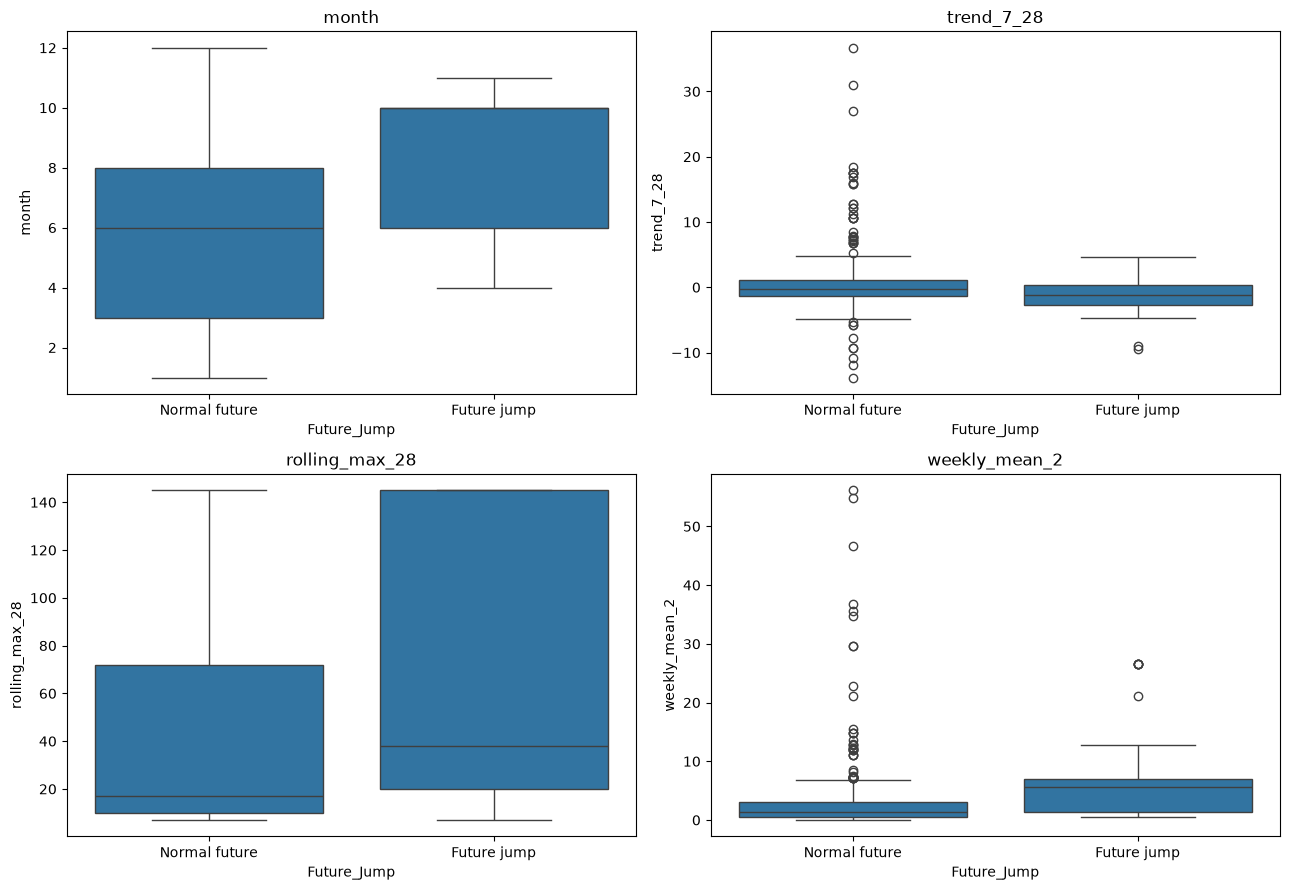

In [388]:
# Step 20.4 — Plot strongest candidate signals

top_jump_features=(feature_separation_df.head(4)["Feature"].tolist())
fig, axes=plt.subplots(2, 2, figsize=(13, 9))
axes = axes.flatten()
for ax, feature in zip(axes, top_jump_features):
    sns.boxplot(
        data=jump_data,
        x="Future_Jump",
        y=feature,
        ax=ax
    )
    ax.set_xticks([0, 1], labels=[ "Normal future", "Future jump"])
    ax.set_title(feature)
plt.tight_layout()
plt.show()

### Step 20.5: Predictability of Future Demand Jumps

To assess whether the existing feature set contains useful ex-ante information
about future demand surges, a simple logistic regression classifier is trained
to predict the future-jump indicator.

A simple linear classifier is intentionally used.

The objective is not to optimize jump classification performance but to test
whether the available covariates contain a detectable predictive signal.

The experiment is repeated across 30 stratified data splits.

For each split:

1. The jump threshold is estimated using the training data only.
2. The classifier is trained using historical and calendar features available
   at the forecast date.
3. Performance is evaluated on the validation set.

Two metrics are reported:

- ROC AUC.
- Average Precision (AP).

Because future jumps are rare, Average Precision is particularly informative.
Its no-skill reference level is approximately equal to the fraction of jump
observations in the evaluation sample.

In [390]:
# Step 20.5 — Repeated ex-ante jump predictability experiment

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (roc_auc_score, average_precision_score)

jump_predictability_results = []
for seed in range(30):
    s=spl.stratified_block_split(jump_data, target_col, random_state=seed)
    tr = s["train"].copy()
    va = s["validation"].copy()
    # IMPORTANT:
    # Jump threshold estimated using TRAINING DATA ONLY
    train_jump_threshold=max(tr["Demand_Jump"].quantile(0.90), 0)
    y_train=(tr["Demand_Jump"]>= train_jump_threshold).astype(int)
    y_val=(va["Demand_Jump"]>=train_jump_threshold).astype(int)
    # Need both classes to compute AUC
    if (y_train.nunique() < 2 or y_val.nunique()<2):
        continue
    classifier = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", LogisticRegression( class_weight="balanced", max_iter=2000, random_state=seed))
    ])
    classifier.fit(tr[candidate_features], y_train)
    jump_probability = classifier.predict_proba(va[candidate_features])[:, 1]
    auc=roc_auc_score(y_val, jump_probability)
    ap=average_precision_score(y_val, jump_probability)
    prevalence = y_val.mean()

    jump_predictability_results.append({
        "Seed": seed,
        "ROC AUC": auc,
        "Average Precision": ap,
        "Jump prevalence": prevalence,
        "AP improvement over baseline": ap - prevalence,
        "N validation observations": len(va),
        "N validation jumps": y_val.sum()
    })

jump_predictability_df = pd.DataFrame(jump_predictability_results)
display(jump_predictability_df.head().round(3))

,Seed,ROC AUC,Average Precision,Jump prevalence,AP improvement over baseline,N validation observations,N validation jumps
0,0,0.097,0.070,0.107,-0.037,56,6
1,1,0.490,0.183,0.143,0.040,56,8
2,2,0.206,0.129,0.143,-0.013,56,8
3,3,0.631,0.210,0.161,0.049,56,9
4,4,0.877,0.512,0.107,0.405,56,6


In [394]:
# Step 20.6 — Predictability summary

predictability_summary = pd.Series({
    "N valid splits": len(jump_predictability_df),
    "Median ROC AUC": jump_predictability_df["ROC AUC"].median(),
    "Mean ROC AUC": jump_predictability_df["ROC AUC"].mean(),
    "ROC AUC std": jump_predictability_df["ROC AUC"].std(),
    "Median Average Precision": jump_predictability_df["Average Precision"].median(),
    "Median jump prevalence": jump_predictability_df["Jump prevalence"].median(),
    "Median AP improvement over baseline": jump_predictability_df["AP improvement over baseline"].median(),
    "% splits AUC > 0.60": 100*(jump_predictability_df["ROC AUC"]>0.60).mean(),
    "% splits AUC > 0.70": 100*(jump_predictability_df["ROC AUC"]>0.70).mean()
})
display(predictability_summary.to_frame("Value").round(3))

,Value
N valid splits,30.000
Median ROC AUC,0.556
Mean ROC AUC,0.534
ROC AUC std,0.327
Median Average Precision,0.206
Median jump prevalence,0.143
Median AP improvement over baseline,0.057
% splits AUC > 0.60,46.667
% splits AUC > 0.70,43.333


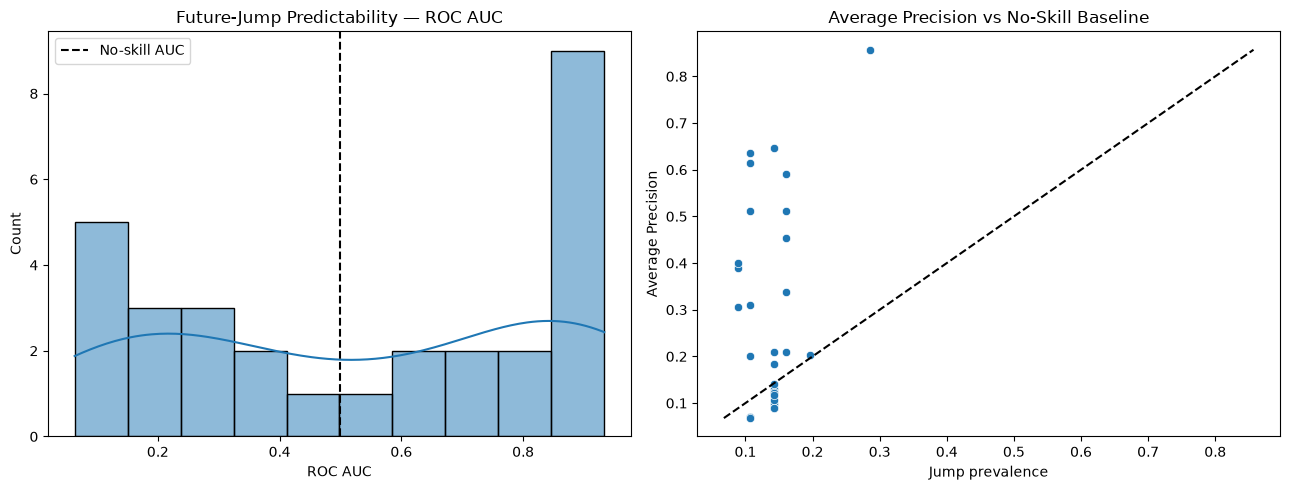

In [396]:
fig, axes=plt.subplots(1, 2, figsize=(13, 5))
sns.histplot(
    jump_predictability_df["ROC AUC"],
    bins=10,
    kde=True,
    ax=axes[0]
)

axes[0].axvline(
    0.5,
    linestyle="--",
    color="black",
    label="No-skill AUC"
)

axes[0].set_title("Future-Jump Predictability — ROC AUC")

axes[0].legend()
sns.scatterplot(
    data=jump_predictability_df,
    x="Jump prevalence",
    y="Average Precision",
    ax=axes[1]
)

min_val = min(
    jump_predictability_df["Jump prevalence"].min(),
    jump_predictability_df["Average Precision"].min()
)

max_val = max(
    jump_predictability_df["Jump prevalence"].max(),
    jump_predictability_df["Average Precision"].max()
)
axes[1].plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle="--",
    color="black"
)
axes[1].set_title("Average Precision vs No-Skill Baseline")

plt.tight_layout()
plt.show()

### Step 20.7: Interpretation

The dataset contains 36 observations classified as future demand jumps,
but these observations correspond to only 6 distinct demand-jump episodes.

This distinction is important because the overlapping 7-day forecasting
windows cause the same underlying demand surge to appear repeatedly in the
dataset. Therefore, the effective number of independent spike events
available for learning is very small.

Some historical variables differ between future-jump and normal observations.
The strongest standardized difference is observed for `month`, followed by
`trend_7_28`, `rolling_max_28`, and several weekly demand statistics.

However, these descriptive differences do not translate into stable
out-of-sample jump predictability.

Across 30 repeated classification experiments, the median ROC AUC is 0.556
and the mean ROC AUC is 0.534. The standard deviation of 0.327 indicates
substantial instability across data splits.

Median Average Precision is 0.206, compared with a median jump prevalence
of 0.143, corresponding to a median improvement of only 0.057 over the
no-skill baseline.

The large variation in classification performance suggests that the
available historical and calendar variables contain only weak and unstable
information about future demand surges.

Combined with the small number of independent jump episodes, these results
suggest that the difficulty of forecasting sudden demand increases is not
only a model-capacity problem. The available predictors may simply not
contain enough information to anticipate these events reliably.

Further improvements in point forecasting would therefore likely require
additional exogenous variables describing the mechanisms generating demand,
such as promotions, price changes, marketing activity, stock availability,
or other operational information.

If such variables are unavailable, a more appropriate next direction is to
model forecast uncertainty explicitly through probabilistic forecasting.

## Step 21: Probabilistic Demand Forecasting

The previous analyses showed that abrupt demand increases are difficult to
anticipate reliably from the currently available historical and calendar
features.

A point forecast provides only one estimate of future demand and therefore
does not describe the uncertainty surrounding that prediction.

This section extends the forecasting framework from point prediction to
probabilistic forecasting.

Instead of predicting a single value, three conditional demand quantiles are
estimated:

- Q10: lower-demand scenario;
- Q50: median forecast;
- Q90: upper-demand scenario.

For a forecasting observation with covariates \(X_t\), the estimated quantile
\(Q_\tau(Y_t \mid X_t)\) represents the demand level below which the future
outcome is expected to fall with probability \(\tau\).

The interval between Q10 and Q90 therefore represents a nominal 80% predictive
interval.

The analysis evaluates:

1. Quantile accuracy using Pinball Loss.
2. Empirical coverage of the Q10-Q90 interval.
3. Predictive interval width.
4. Coverage during high-demand periods.
5. Whether predictive uncertainty increases when forecasting becomes difficult.

**Methodological note:** The current test split has already been used extensively
for diagnostic analysis in previous sections. Therefore, the results in this
section should initially be interpreted as exploratory. Robustness across
repeated splits and categories will be evaluated separately.

### Step 21.1: Quantile Model Estimation

Three gradient boosting models are estimated independently for the 10th,
50th, and 90th conditional demand quantiles.

Quantile regression minimizes the asymmetric Pinball Loss:

$$
L_\tau(y,\hat{q}) =
\begin{cases}
\tau(y-\hat{q}), & y \geq \hat{q} \\
(1-\tau)(\hat{q}-y), & y < \hat{q}
\end{cases}
$$

where $\tau$ is the target quantile.

Unlike ordinary regression, quantile regression does not attempt to estimate
only the conditional mean of future demand. It provides information about the
shape and uncertainty of the conditional demand distribution.

The same model specification is used for all three quantiles so that
differences arise from the quantile objective rather than from separate
hyperparameter choices.

In [204]:
# Step 21.1 — Quantile models

from sklearn.ensemble import GradientBoostingRegressor

CATEGORY = "Jewellery - Earrings"

s = splits[CATEGORY]

train_q = s["train"].copy()
validation_q = s["validation"].copy()
test_q = s["test"].copy()

quantiles = [0.10, 0.50, 0.90]

quantile_models = {}
quantile_predictions = {}

for q in quantiles:

    model = GradientBoostingRegressor(
        loss="quantile",
        alpha=q,
        n_estimators=300,
        learning_rate=0.03,
        max_depth=3,
        min_samples_leaf=8,
        random_state=42
    )

    model.fit(
        train_q[features],
        train_q[target_col]
    )

    pred = model.predict(
        test_q[features]
    )

    pred = np.maximum(pred, 0)

    quantile_models[q] = model
    quantile_predictions[q] = pred


probabilistic_df = test_q[
    ["Date", target_col]
].copy()

probabilistic_df["Actual"] = (
    test_q[target_col].to_numpy()
)

probabilistic_df["Q10"] = (
    quantile_predictions[0.10]
)

probabilistic_df["Q50"] = (
    quantile_predictions[0.50]
)

probabilistic_df["Q90"] = (
    quantile_predictions[0.90]
)

probabilistic_df = (
    probabilistic_df
    .sort_values("Date")
    .reset_index(drop=True)
)

display(
    probabilistic_df.head(10).round(2)
)

C:\Users\user\AppData\Local\Temp\ipykernel_20484\1884104535.py:72: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  probabilistic_df.head(10).round(2)


,Date,target_X7_Y7,Actual,Q10,Q50,Q90
0,2011-04-20,1.0,1.0,3.76,2.47,17.63
1,2011-04-21,0.0,0.0,3.78,3.14,17.81
2,2011-04-22,77.0,77.0,3.72,3.48,17.82
3,2011-04-23,77.0,77.0,3.73,3.41,17.53
4,2011-04-24,77.0,77.0,3.64,3.27,17.69
5,2011-04-25,104.0,104.0,3.93,3.09,21.27
6,2011-04-26,104.0,104.0,4.29,5.57,14.15
7,2011-04-27,104.0,104.0,4.20,5.06,14.95
8,2011-04-28,108.0,108.0,3.97,3.54,13.79
9,2011-04-29,31.0,31.0,4.08,4.12,13.76


### Step 21.2: Quantile Consistency

Because the three quantiles are estimated using independent models, quantile
crossing may occur.

A prediction is considered inconsistent when:

$$
Q_{10} > Q_{50}
$$

or

$$
Q_{50} > Q_{90}.
$$

The frequency of such cases is reported before evaluating the predictive
interval.

In [207]:
# Step 21.2 — Check quantile crossing

crossing_mask = (
    (probabilistic_df["Q10"] > probabilistic_df["Q50"])
    |
    (probabilistic_df["Q50"] > probabilistic_df["Q90"])
)

crossing_rate = (
    100 * crossing_mask.mean()
)

print(
    f"Quantile crossing rate: "
    f"{crossing_rate:.2f}%"
)

Quantile crossing rate: 16.67%


### Step 21.3: Quantile Accuracy Using Pinball Loss

Quantile forecasts are evaluated using Pinball Loss.

For a correctly specified quantile model, lower Pinball Loss indicates better
quantile prediction.

The loss is computed separately for Q10, Q50, and Q90.

The median forecast Q50 can also be interpreted as a probabilistic analogue
of a conventional point forecast, since minimizing the 50th-percentile
Pinball Loss corresponds to minimizing absolute error.

In [210]:
# Step 21.3 — Pinball Loss

from sklearn.metrics import mean_pinball_loss

pinball_results = []

for q, column in [
    (0.10, "Q10"),
    (0.50, "Q50"),
    (0.90, "Q90")
]:

    loss = mean_pinball_loss(
        probabilistic_df["Actual"],
        probabilistic_df[column],
        alpha=q
    )

    pinball_results.append({
        "Quantile": q,
        "Pinball Loss": loss
    })


pinball_df = pd.DataFrame(
    pinball_results
)

display(
    pinball_df.round(3)
)

,Quantile,Pinball Loss
0,0.1,3.539
1,0.5,13.738
2,0.9,16.718


### Step 21.4: Quantile Calibration

A probabilistic forecast should not only minimize a loss function; its
predicted quantiles should also be calibrated.

For quantile \(Q_\tau\), empirical coverage is defined as:

$$
C_\tau =
\frac{1}{N}
\sum_{t=1}^{N}
\mathbf{1}(y_t \leq Q_{\tau,t})
$$

A well-calibrated model should approximately satisfy:

$$
C_\tau \approx \tau.
$$

For example, approximately 90% of observed future demand values should fall
below the predicted Q90.

In [213]:
# Step 21.4 — Quantile calibration

calibration_rows = []

for q, column in [
    (0.10, "Q10"),
    (0.50, "Q50"),
    (0.90, "Q90")
]:

    empirical_coverage = (
        probabilistic_df["Actual"]
        <= probabilistic_df[column]
    ).mean()

    calibration_rows.append({
        "Quantile": q,
        "Nominal coverage (%)": 100 * q,
        "Empirical coverage (%)":
            100 * empirical_coverage,
        "Calibration error (pp)":
            100 * (empirical_coverage - q)
    })


calibration_df = pd.DataFrame(
    calibration_rows
)

display(
    calibration_df.round(2)
)

,Quantile,Nominal coverage (%),Empirical coverage (%),Calibration error (pp)
0,0.1,10.0,33.33,23.33
1,0.5,50.0,54.76,4.76
2,0.9,90.0,59.52,-30.48


### Step 21.5: Predictive Interval Coverage and Width

The Q10-Q90 interval represents a nominal 80% predictive interval.

For each observation:

$$
I_t = [Q_{0.10,t}, Q_{0.90,t}]
$$

Two complementary properties are evaluated.

**Coverage**

The proportion of actual outcomes contained within the interval:

$$
Coverage =
\frac{1}{N}
\sum_{t=1}^{N}
\mathbf{1}
(Q_{0.10,t} \leq y_t \leq Q_{0.90,t})
$$

The target coverage is approximately 80%.

**Interval width**

$$
Width_t =
Q_{0.90,t} - Q_{0.10,t}
$$

A very wide interval may achieve high coverage while providing little useful
information. Therefore, coverage and interval width must be interpreted
together.

In [216]:
# Step 21.5 — Prediction interval evaluation

probabilistic_df["Covered"] = (
    (
        probabilistic_df["Actual"]
        >= probabilistic_df["Q10"]
    )
    &
    (
        probabilistic_df["Actual"]
        <= probabilistic_df["Q90"]
    )
)

probabilistic_df["Interval_Width"] = (
    probabilistic_df["Q90"]
    - probabilistic_df["Q10"]
)

coverage = (
    100 * probabilistic_df["Covered"].mean()
)

mean_width = (
    probabilistic_df["Interval_Width"].mean()
)

median_width = (
    probabilistic_df["Interval_Width"].median()
)

interval_results = pd.Series({
    "Nominal coverage (%)": 80.0,

    "Empirical coverage (%)":
        coverage,

    "Mean interval width":
        mean_width,

    "Median interval width":
        median_width,

    "Mean actual demand":
        probabilistic_df["Actual"].mean()
})

display(
    interval_results
    .to_frame("Value")
    .round(2)
)

,Value
Nominal coverage (%),80.00
Empirical coverage (%),26.19
Mean interval width,22.56
Median interval width,17.41
Mean actual demand,26.81


### Step 21.6: Uncertainty During High-Demand Periods

The primary motivation for probabilistic forecasting is the failure of point
forecasts during abrupt increases in demand.

The analysis therefore separately evaluates the observations classified as
high demand.

For these observations, we examine:

- Q50 error;
- Q90 coverage;
- Q10-Q90 interval coverage;
- average predictive interval width.

If Q50 continues to underestimate demand but Q90 frequently covers the
observed outcome, the probabilistic model may still provide useful information
about upper-tail demand risk.

Conversely, if high-demand observations also exceed Q90, the probabilistic
model is underestimating uncertainty in the upper tail.

In [219]:
# Step 21.6 — High-demand probabilistic performance

high_threshold = (
    probabilistic_df["Actual"]
    .quantile(0.90)
)

high_prob_df = probabilistic_df[
    probabilistic_df["Actual"]
    >= high_threshold
].copy()

high_q50_mae = np.mean(
    np.abs(
        high_prob_df["Actual"]
        - high_prob_df["Q50"]
    )
)

high_q90_coverage = (
    100
    * (
        high_prob_df["Actual"]
        <= high_prob_df["Q90"]
    ).mean()
)

high_interval_coverage = (
    100
    * high_prob_df["Covered"].mean()
)

high_interval_width = (
    high_prob_df["Interval_Width"].mean()
)

high_demand_prob_results = pd.Series({

    "N high-demand observations":
        len(high_prob_df),

    "Mean actual demand":
        high_prob_df["Actual"].mean(),

    "Mean Q50 forecast":
        high_prob_df["Q50"].mean(),

    "Mean Q90 forecast":
        high_prob_df["Q90"].mean(),

    "Q50 MAE":
        high_q50_mae,

    "Q90 upper-tail coverage (%)":
        high_q90_coverage,

    "Q10-Q90 interval coverage (%)":
        high_interval_coverage,

    "Mean interval width":
        high_interval_width
})

display(
    high_demand_prob_results
    .to_frame("Value")
    .round(2)
)

,Value
N high-demand observations,7.00
Mean actual demand,93.00
Mean Q50 forecast,3.92
Mean Q90 forecast,16.74
Q50 MAE,89.08
Q90 upper-tail coverage (%),0.00
Q10-Q90 interval coverage (%),0.00
Mean interval width,12.82


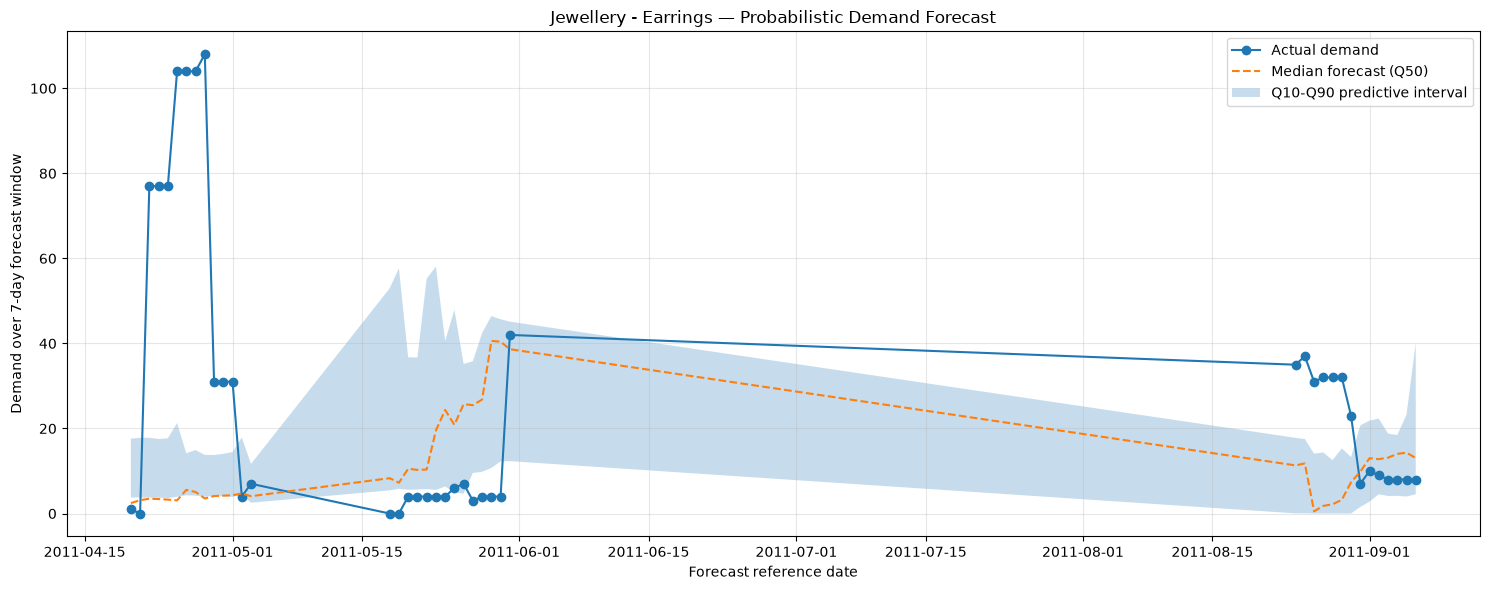

In [221]:
# Step 21.7 — Probabilistic forecast visualization

plot_df = (
    probabilistic_df
    .sort_values("Date")
    .copy()
)

plt.figure(
    figsize=(15, 6)
)

plt.plot(
    plot_df["Date"],
    plot_df["Actual"],
    marker="o",
    label="Actual demand"
)

plt.plot(
    plot_df["Date"],
    plot_df["Q50"],
    linestyle="--",
    label="Median forecast (Q50)"
)

plt.fill_between(
    plot_df["Date"],
    plot_df["Q10"],
    plot_df["Q90"],
    alpha=0.25,
    label="Q10-Q90 predictive interval"
)

plt.title(
    f"{CATEGORY} — Probabilistic Demand Forecast"
)

plt.xlabel(
    "Forecast reference date"
)

plt.ylabel(
    "Demand over 7-day forecast window"
)

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Step 21.8: Interpretation

The initial probabilistic forecasting experiment reveals substantial
miscalibration.

The median forecast Q50 is relatively well calibrated, with an empirical
coverage of 54.76% compared with its nominal level of 50%.

However, the tail quantiles are poorly calibrated. Q10 has an empirical
coverage of 33.33% instead of 10%, while Q90 covers only 59.52% of the
observations instead of the intended 90%.

Consequently, the nominal 80% Q10-Q90 predictive interval achieves only
26.19% empirical coverage.

The problem is particularly severe during high-demand periods. Mean observed
demand is 93 units, while the mean Q50 and Q90 forecasts are only 3.92 and
16.74 units respectively. None of the high-demand observations are covered by
Q90 or by the Q10-Q90 interval.

Therefore, the raw quantile regression model does not adequately represent
upper-tail demand risk. The limitation observed previously in point forecasts
also appears in the estimated predictive distribution.

Before evaluating probabilistic forecasting across additional categories, the
predictive intervals should therefore be calibrated using information from the
validation set.

### Step 21.9: Conformal Calibration of the Predictive Interval

The raw Q10-Q90 interval substantially undercovers observed demand.

To correct this issue without retraining the quantile models, split conformal
calibration is applied using the validation set.

For each validation observation, a conformity score is defined as:

$$
s_i =
\max(Q_{0.10,i} - y_i,\;
     y_i - Q_{0.90,i},\;
     0).
$$

The calibration quantile of these scores determines how much the original
interval must be widened.

The calibrated interval is:

$$
[Q_{0.10}-q,\;Q_{0.90}+q]
$$

where \(q\) is estimated exclusively from validation observations.

The test set is not used to determine the calibration adjustment.

In [228]:
# Step 21.9 — Split conformal calibration

alpha = 0.20   # target = 80% interval

# Predict validation quantiles using the already-trained models
val_q10 = np.maximum(
    quantile_models[0.10].predict(validation_q[features]),
    0
)

val_q90 = np.maximum(
    quantile_models[0.90].predict(validation_q[features]),
    0
)

y_val = validation_q[target_col].to_numpy()

# Conformity scores
conformal_scores = np.maximum.reduce([
    val_q10 - y_val,
    y_val - val_q90,
    np.zeros(len(y_val))
])

# Finite-sample conformal quantile
n_cal = len(conformal_scores)

quantile_level = min(
    np.ceil((n_cal + 1) * (1 - alpha)) / n_cal,
    1.0
)

q_hat = np.quantile(
    conformal_scores,
    quantile_level,
    method="higher"
)

print(
    f"Conformal adjustment q_hat: {q_hat:.2f}"
)

Conformal adjustment q_hat: 6.05


In [230]:
# Apply conformal correction to TEST predictions

probabilistic_df["CQ10"] = np.maximum(
    probabilistic_df["Q10"] - q_hat,
    0
)

probabilistic_df["CQ90"] = (
    probabilistic_df["Q90"] + q_hat
)

probabilistic_df["Conformal_Covered"] = (
    (
        probabilistic_df["Actual"]
        >= probabilistic_df["CQ10"]
    )
    &
    (
        probabilistic_df["Actual"]
        <= probabilistic_df["CQ90"]
    )
)

probabilistic_df["Conformal_Width"] = (
    probabilistic_df["CQ90"]
    - probabilistic_df["CQ10"]
)

conformal_results = pd.Series({

    "Target coverage (%)":
        80,

    "Raw interval coverage (%)":
        100 * probabilistic_df["Covered"].mean(),

    "Conformal interval coverage (%)":
        100 * probabilistic_df["Conformal_Covered"].mean(),

    "Raw mean interval width":
        probabilistic_df["Interval_Width"].mean(),

    "Conformal mean interval width":
        probabilistic_df["Conformal_Width"].mean(),

    "Conformal adjustment":
        q_hat
})

display(
    conformal_results
    .to_frame("Value")
    .round(2)
)

,Value
Target coverage (%),80.00
Raw interval coverage (%),26.19
Conformal interval coverage (%),52.38
Raw mean interval width,22.56
Conformal mean interval width,32.41
Conformal adjustment,6.05


In [232]:
high_conf_df = probabilistic_df[
    probabilistic_df["Actual"]
    >= high_threshold
].copy()

high_conformal_results = pd.Series({

    "N high-demand observations":
        len(high_conf_df),

    "Raw high-demand coverage (%)":
        100 * high_conf_df["Covered"].mean(),

    "Conformal high-demand coverage (%)":
        100 * high_conf_df["Conformal_Covered"].mean(),

    "Mean actual demand":
        high_conf_df["Actual"].mean(),

    "Mean calibrated upper bound":
        high_conf_df["CQ90"].mean(),

    "Mean calibrated interval width":
        high_conf_df["Conformal_Width"].mean()
})

display(
    high_conformal_results
    .to_frame("Value")
    .round(2)
)

,Value
N high-demand observations,7.0
Raw high-demand coverage (%),0.0
Conformal high-demand coverage (%),0.0
Mean actual demand,93.0
Mean calibrated upper bound,22.8
Mean calibrated interval width,22.8


### Step 21.10: Conformal Calibration Results

Conformal calibration improves the empirical coverage of the predictive
interval, but does not fully correct the uncertainty estimates.

The raw Q10-Q90 interval achieves only 26.19% coverage. After estimating a
conformal adjustment of 6.05 units from the validation set, empirical coverage
increases to 52.38%.

This improvement comes with an increase in mean interval width from 22.56 to
32.41 units, while coverage remains substantially below the nominal target
of 80%.

More importantly, conformal calibration does not improve coverage during
high-demand periods. The seven high-demand observations remain entirely
outside the calibrated interval.

Mean observed demand during these periods is 93 units, whereas the mean
calibrated upper bound is only 22.8 units.

This indicates that the validation sample does not contain errors comparable
in magnitude to the extreme demand increases appearing in the test sample.
Consequently, the calibration adjustment is insufficient to represent
upper-tail demand risk.

The result also highlights a limitation of conformal calibration in this
setting. Standard split-conformal coverage relies on calibration and future
observations being approximately exchangeable. Temporal dependence,
overlapping forecast targets, and a small number of rare demand regimes make
this assumption difficult to satisfy.

Overall, probabilistic forecasting improves the representation of ordinary
forecast uncertainty but does not solve the problem of abrupt demand spikes
for this category.

## Step 22: Probabilistic Forecasting Across Categories

The detailed analysis of `Jewellery - Earrings` showed that both the raw
quantile interval and its conformal calibration failed to adequately cover
large demand spikes.

This section checks whether that behaviour is specific to this difficult
category or also appears in other representative demand profiles.

For each category, the same Q10-Q90 quantile-regression procedure is applied
using the existing training, validation, and test splits.

The validation set is used exclusively to estimate the conformal adjustment,
which is then applied to the test interval.

The comparison focuses on four quantities:

- raw Q10-Q90 empirical coverage;
- conformal interval coverage;
- mean conformal interval width;
- conformal coverage during high-demand observations.

The objective is not to optimize a separate probabilistic model for every
category, but to assess whether the uncertainty-modelling conclusions obtained
for `Jewellery - Earrings` generalize to other demand profiles.

In [278]:
# Step 22.1 — Probabilistic robustness across categories

from sklearn.ensemble import GradientBoostingRegressor

alpha = 0.20
category_prob_results = []
for category in selected_categories:
    s = splits[category]
    tr = s["train"].copy()
    va = s["validation"].copy()
    te = s["test"].copy()
    # Features actually available for this category
    cat_features=[f for f in features if f in tr.columns]
    # ---------------------------
    # Train Q10 and Q90 models
    # ---------------------------
    q_models = {}
    for q in [0.10, 0.90]:
        model = GradientBoostingRegressor(
            loss="quantile",
            alpha=q,
            n_estimators=300,
            learning_rate=0.03,
            max_depth=3,
            min_samples_leaf=8,
            random_state=42
        )
        model.fit( tr[cat_features],tr[target_col])
        q_models[q] = model
    # ---------------------------
    # Validation predictions
    # ---------------------------
    val_q10 = np.maximum(q_models[0.10].predict(va[cat_features]), 0)
    val_q90 = np.maximum(q_models[0.90].predict(va[cat_features]), 0)
    y_val = va[target_col].to_numpy()
    # ---------------------------
    # Conformal calibration
    # ---------------------------
    conformal_scores = np.maximum.reduce([val_q10 - y_val, y_val - val_q90, np.zeros(len(y_val))])
    n_cal=len(conformal_scores)
    quantile_level=min(np.ceil((n_cal + 1) * (1 - alpha)) / n_cal,1.0 )
    q_hat=np.quantile(conformal_scores, quantile_level, method="higher")
    # ---------------------------
    # Test predictions
    # ---------------------------
    test_q10 = np.maximum(q_models[0.10].predict(te[cat_features]),0)
    test_q90 = np.maximum(q_models[0.90].predict(te[cat_features]),0)
    y_test = te[target_col].to_numpy()
    
    # Raw interval
    raw_covered=((y_test >= test_q10) & (y_test <= test_q90))
    raw_width=(test_q90 - test_q10)
    
    # Conformal interval
    conf_q10 = np.maximum(test_q10 - q_hat, 0)
    conf_q90 = (test_q90 + q_hat)
    conf_covered=((y_test >= conf_q10)&(y_test <= conf_q90))
    conf_width=(conf_q90 - conf_q10)
    # ---------------------------
    # High-demand observations
    # ---------------------------
    high_threshold = np.quantile(y_test,0.90)
    high_mask = ( y_test >= high_threshold)
    if high_mask.sum() > 0:
        high_conf_coverage=( 100 * conf_covered[high_mask].mean())
    else:
        high_conf_coverage = np.nan

    # ---------------------------
    # Save summary
    # ---------------------------
    category_prob_results.append({
        "Category":
            category,
        "Raw coverage (%)":
            100 * raw_covered.mean(),
        "Conformal coverage (%)":
            100 * conf_covered.mean(),
        "Target coverage (%)":
            80.0,
        "Mean conformal width":
            conf_width.mean(),
        "Mean actual demand":
            y_test.mean(),
        "High-demand coverage (%)":
            high_conf_coverage,
        "Conformal adjustment":
            q_hat
    })

category_prob_df = pd.DataFrame( category_prob_results)
display(category_prob_df.round(2))

,Category,Raw coverage (%),Conformal coverage (%),Target coverage (%),Mean conformal width,Mean actual demand,High-demand coverage (%),Conformal adjustment
0,Tealight Holders & Sets,35.71,52.38,80.0,2335.55,5050.88,0.00,378.57
1,Cake Cases & Baking Accessories,71.43,100.00,80.0,6600.52,5569.00,100.00,1275.81
2,Jumbo Bags & Shoppers,61.90,83.33,80.0,7114.74,5258.74,33.33,1732.16
3,Christmas Decorations,76.19,97.62,80.0,2912.52,4229.17,80.00,616.36
4,Jewellery - Earrings,26.19,52.38,80.0,32.41,26.81,0.00,6.05


In [279]:
# Step 22.2 — Relative interval width

category_prob_df["Relative width (%)"] = (
    100 * category_prob_df["Mean conformal width"]
    / category_prob_df["Mean actual demand"].replace(0, np.nan)
)

display(category_prob_df[
        ["Category",
            "Raw coverage (%)",
            "Conformal coverage (%)",
            "Target coverage (%)",
            "Relative width (%)",
            "High-demand coverage (%)"]
    ].round(2)
)

,Category,Raw coverage (%),Conformal coverage (%),Target coverage (%),Relative width (%),High-demand coverage (%)
0,Tealight Holders & Sets,35.71,52.38,80.0,46.24,0.00
1,Cake Cases & Baking Accessories,71.43,100.00,80.0,118.52,100.00
2,Jumbo Bags & Shoppers,61.90,83.33,80.0,135.29,33.33
3,Christmas Decorations,76.19,97.62,80.0,68.87,80.00
4,Jewellery - Earrings,26.19,52.38,80.0,120.89,0.00


### Step 22.3: Interpretation

The cross-category analysis shows that probabilistic forecasting performance
is highly dependent on the demand profile.

Conformal calibration improves empirical interval coverage for all five
categories, but the nominal 80% target is not consistently achieved.

For `Christmas Decorations`, raw coverage increases from 76.19% to 97.62%,
while high-demand coverage reaches 80%. This category therefore provides the
strongest evidence that probabilistic intervals can capture meaningful demand
uncertainty.

`Cake Cases & Baking Accessories` reaches 100% conformal coverage and 100%
high-demand coverage. However, its mean calibrated interval width corresponds
to approximately 118.5% of mean demand. The high coverage is therefore obtained
with relatively broad prediction intervals.

`Jumbo Bags & Shoppers` achieves 83.33% overall conformal coverage, close to
the nominal 80% target. However, its interval width is approximately 135.3%
of mean demand and high-demand coverage remains only 33.33%.

The weakest results occur for `Tealight Holders & Sets` and
`Jewellery - Earrings`. Both categories achieve only 52.38% conformal coverage,
and neither covers any of the high-demand observations.

For `Jewellery - Earrings`, the calibrated interval width is approximately
120.9% of average demand, yet high-demand coverage remains 0%. This confirms
that simply widening the predictive interval does not solve the upper-tail
forecasting problem for sparse and abrupt demand profiles.

Overall, conformal calibration improves uncertainty representation, but its
effectiveness is strongly category-dependent. Stable or more regular demand
profiles appear easier to characterize probabilistically, whereas abrupt
high-demand events remain difficult to represent using the currently
available historical and calendar variables.

### Step 22.4 — Fixed prediction intervals around point forecasts

In addition to quantile-based prediction intervals, we evaluate simpler
intervals constructed directly around the point forecast.

For a point prediction $\hat{y}$, two types of intervals are considered:

1. Absolute-margin intervals:

   $[\hat{y} - m, \hat{y} + m]$

   where m is a fixed number of demand units.

2. Percentage-margin intervals:

   $[\hat{y}(1-p), \hat{y}(1+p)]$

   where p is a fixed percentage of the point forecast.

The purpose is to study the trade-off between:

- empirical coverage: proportion of actual observations contained in the interval;
- interval width: how wide the interval must be to obtain that coverage.

A wider interval generally increases coverage but provides a less precise
prediction range.

The analysis is performed on the same X = 7, Y = 7 forecasting task and
the same train-validation-test splits used in the previous experiments.

In [270]:
# Step 22.5 — Generate point forecasts for interval experiments

fixed_interval_predictions = {}

for cat in selected_categories:

    print(f"Running {cat}")

    model_name = best_model_by_category[cat]

    s = splits[cat]

    tr = s["train"]
    va = s["validation"]
    te = s["test"]

    cat_features = [f for f in features if f in tr.columns ]

    _, val_pred, test_pred = mdl.MODELS[model_name](
        tr, va, te, cat_features, target_col)

    val_pred = np.maximum(np.asarray(val_pred).reshape(-1),0)

    test_pred = np.maximum(np.asarray(test_pred).reshape(-1),0)

    fixed_interval_predictions[cat] = {
        "model": model_name,
        "y_val": va[target_col].to_numpy(),
        "val_pred": val_pred,
        "y_test": te[target_col].to_numpy(),
        "test_pred": test_pred
    }

Running Tealight Holders & Sets
Running Cake Cases & Baking Accessories
Running Jumbo Bags & Shoppers
Running Christmas Decorations
Running Jewellery - Earrings


In [272]:
# Step 22.6 — Percentage-margin intervals

PERCENT_MARGINS = [ 0.10, 0.20, 0.30, 0.50, 0.75, 1.00, 1.50, 2.00 ]
percentage_rows = []

for cat in selected_categories:

    data = fixed_interval_predictions[cat]

    y_val = data["y_val"]
    pred_val = data["val_pred"]

    for p in PERCENT_MARGINS:
        lower = np.maximum(pred_val * (1 - p), 0)
        upper = pred_val * (1 + p)
        covered = ((y_val >= lower) & (y_val <= upper))
        width = upper - lower

        percentage_rows.append({
            "Category": cat,
            "Margin (%)": p * 100,
            "Validation coverage (%)": 100 * covered.mean(),
            "Mean interval width": width.mean(),
            "Mean actual demand": y_val.mean()
        })

percentage_interval_df = pd.DataFrame(percentage_rows)

percentage_interval_df["Relative width (%)"] = (
    100 * percentage_interval_df["Mean interval width"] / percentage_interval_df["Mean actual demand"])

display(percentage_interval_df.round(2))

,Category,Margin (%),Validation coverage (%),Mean interval width,Mean actual demand,Relative width (%)
0,Tealight Holders & Sets,10.0,39.62,1009.53,4833.38,20.89
1,Tealight Holders & Sets,20.0,67.92,2019.06,4833.38,41.77
2,Tealight Holders & Sets,30.0,94.34,3028.59,4833.38,62.66
3,Tealight Holders & Sets,50.0,100.00,5047.65,4833.38,104.43
4,Tealight Holders & Sets,75.0,100.00,7571.48,4833.38,156.65
5,Tealight Holders & Sets,100.0,100.00,10095.30,4833.38,208.87
6,Tealight Holders & Sets,150.0,100.00,12619.13,4833.38,261.08
7,Tealight Holders & Sets,200.0,100.00,15142.96,4833.38,313.30
8,Cake Cases & Baking Accessories,10.0,26.79,960.40,4928.09,19.49
9,Cake Cases & Baking Accessories,20.0,39.29,1920.80,4928.09,38.98


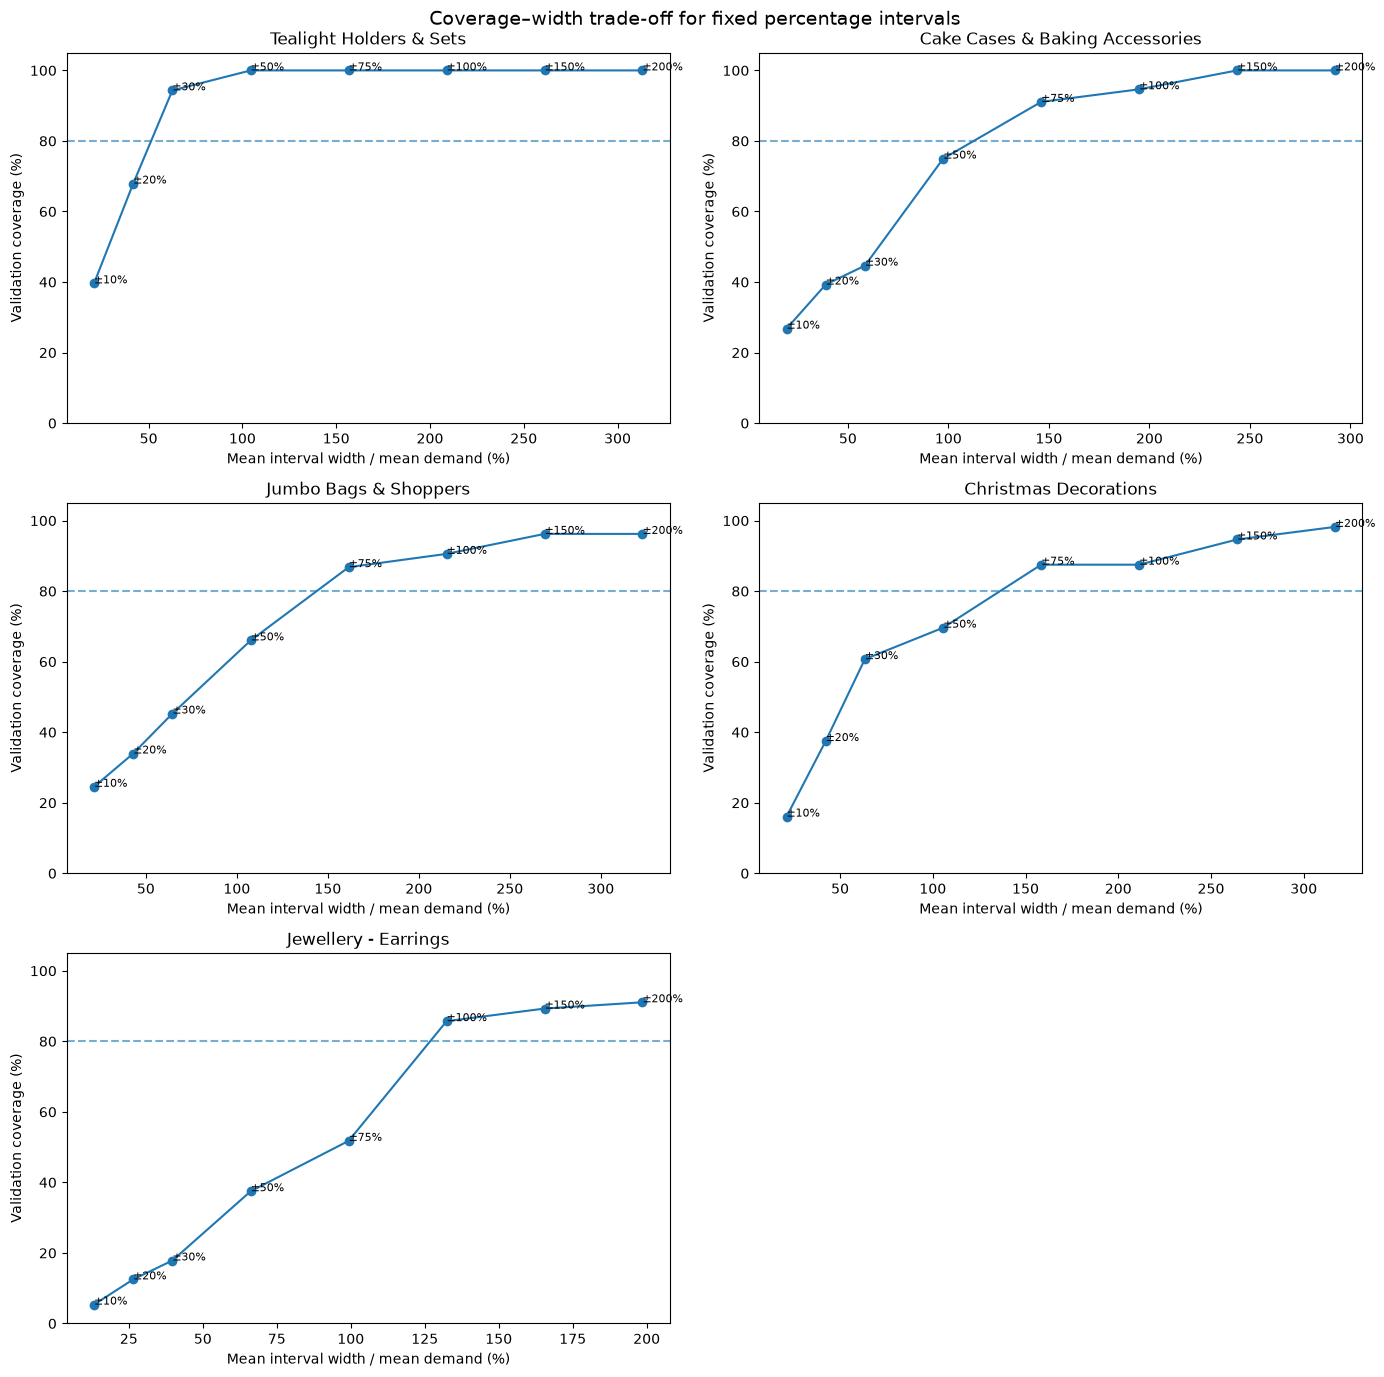

In [274]:
# Step 22.7 — Coverage-width trade-off for percentage intervals

fig, axes = plt.subplots(3, 2,figsize=(14, 14))
axes = axes.flatten()
for ax, cat in zip(axes, selected_categories):
    sub = percentage_interval_df[percentage_interval_df["Category"] == cat]

    ax.plot(sub["Relative width (%)"],
        sub["Validation coverage (%)"],
        marker="o"
    )
    for _, row in sub.iterrows():
        ax.annotate(
            f'±{row["Margin (%)"]:.0f}%',
            (
                row["Relative width (%)"],
                row["Validation coverage (%)"]
            ), fontsize=8
        )
    ax.axhline(80, linestyle="--", alpha=0.6)
    ax.set_title(cat)
    ax.set_xlabel("Mean interval width / mean demand (%)")
    ax.set_ylabel("Validation coverage (%)")
    ax.set_ylim(0, 105)

for ax in axes[len(selected_categories):]:
    ax.set_visible(False)
fig.suptitle("Coverage–width trade-off for fixed percentage intervals", fontsize=14)
plt.tight_layout()
plt.show()

In [282]:
# Step 22.8 — Select the smallest percentage margin reaching 80% coverage

TARGET_COVERAGE = 80.0
selected_percentage_margins = []
for cat in selected_categories:
    sub=(percentage_interval_df[percentage_interval_df["Category"] == cat]
        .sort_values("Margin (%)").copy())

    eligible=sub[sub["Validation coverage (%)"] >= TARGET_COVERAGE]

    if len(eligible) > 0:
        chosen = eligible.iloc[0]

    else:
        # If 80% is never reached, use the largest tested margin
        chosen = sub.iloc[-1]

    selected_percentage_margins.append({
        "Category": cat,
        "Selected margin (%)": chosen["Margin (%)"],
        "Validation coverage (%)": chosen["Validation coverage (%)"],
        "Validation relative width (%)": chosen["Relative width (%)"]
    })

selected_percentage_df = pd.DataFrame(
    selected_percentage_margins
)

display(selected_percentage_df.round(2))

,Category,Selected margin (%),Validation coverage (%),Validation relative width (%)
0,Tealight Holders & Sets,30.0,94.34,62.66
1,Cake Cases & Baking Accessories,75.0,91.07,146.16
2,Jumbo Bags & Shoppers,75.0,86.79,161.46
3,Christmas Decorations,75.0,87.50,158.43
4,Jewellery - Earrings,100.0,85.71,132.39


In [284]:
# Step 22.9 — Test evaluation of selected percentage intervals

percentage_test_rows = []

for _, row in selected_percentage_df.iterrows():
    cat = row["Category"]
    p = row["Selected margin (%)"] / 100
    data = fixed_interval_predictions[cat]
    y_test = data["y_test"]
    pred_test = data["test_pred"]
    lower = np.maximum(pred_test * (1-p),0)

    upper = pred_test * (1 + p)

    covered = ((y_test >= lower) & (y_test <= upper))

    width = upper - lower

    # High-demand observations
    high_threshold = np.quantile(y_test, 0.90)

    high_mask = y_test >= high_threshold

    high_covered = (
        (y_test[high_mask] >= lower[high_mask]) &
        (y_test[high_mask] <= upper[high_mask])
    )

    percentage_test_rows.append({
        "Category": cat,

        "Selected margin (%)":
            row["Selected margin (%)"],

        "Validation coverage (%)":
            row["Validation coverage (%)"],

        "Test coverage (%)":
            100 * covered.mean(),

        "Mean test interval width":
            width.mean(),

        "Mean test demand":
            y_test.mean(),

        "Relative test width (%)":
            100 * width.mean() / y_test.mean(),

        "High-demand coverage (%)":
            100 * high_covered.mean()
    })

percentage_test_df = pd.DataFrame(
    percentage_test_rows
)

display(
    percentage_test_df.round(2)
)

,Category,Selected margin (%),Validation coverage (%),Test coverage (%),Mean test interval width,Mean test demand,Relative test width (%),High-demand coverage (%)
0,Tealight Holders & Sets,30.0,94.34,66.67,3182.07,5050.88,63.00,80.0
1,Cake Cases & Baking Accessories,75.0,91.07,100.00,9503.56,5569.00,170.65,100.0
2,Jumbo Bags & Shoppers,75.0,86.79,83.33,9119.05,5258.74,173.41,100.0
3,Christmas Decorations,75.0,87.50,97.62,6857.85,4229.17,162.16,80.0
4,Jewellery - Earrings,100.0,85.71,59.52,31.53,26.81,117.61,0.0


In [286]:
# Step 22.10 — Absolute fixed-width intervals

ABS_MULTIPLIERS = [
    0.5,
    1.0,
    1.5,
    2.0,
    2.5,
    3.0,
    4.0
]

absolute_rows = []

for cat in selected_categories:

    data = fixed_interval_predictions[cat]

    y_val = data["y_val"]
    pred_val = data["val_pred"]

    validation_mae = np.mean(
        np.abs(y_val - pred_val)
    )

    for k in ABS_MULTIPLIERS:

        # Same absolute margin for EVERY prediction
        # within this category.
        margin = k * validation_mae

        lower = np.maximum(
            pred_val - margin,
            0
        )

        upper = pred_val + margin

        covered = (
            (y_val >= lower) &
            (y_val <= upper)
        )

        width = upper - lower

        absolute_rows.append({
            "Category": cat,
            "MAE multiplier": k,
            "Absolute margin": margin,
            "Validation coverage (%)":
                100 * covered.mean(),
            "Mean interval width":
                width.mean(),
            "Mean actual demand":
                y_val.mean()
        })

absolute_interval_df = pd.DataFrame(
    absolute_rows
)

absolute_interval_df["Relative width (%)"] = (
    100
    * absolute_interval_df["Mean interval width"]
    / absolute_interval_df["Mean actual demand"]
)

display(
    absolute_interval_df.round(2)
)

,Category,MAE multiplier,Absolute margin,Validation coverage (%),Mean interval width,Mean actual demand,Relative width (%)
0,Tealight Holders & Sets,0.5,376.92,37.74,753.83,4833.38,15.60
1,Tealight Holders & Sets,1.0,753.83,66.04,1507.67,4833.38,31.19
2,Tealight Holders & Sets,1.5,1130.75,79.25,2261.50,4833.38,46.79
3,Tealight Holders & Sets,2.0,1507.67,83.02,3015.33,4833.38,62.39
4,Tealight Holders & Sets,2.5,1884.58,88.68,3769.16,4833.38,77.98
5,Tealight Holders & Sets,3.0,2261.50,98.11,4523.00,4833.38,93.58
6,Tealight Holders & Sets,4.0,3015.33,100.00,6030.66,4833.38,124.77
7,Cake Cases & Baking Accessories,0.5,731.97,33.93,1463.95,4928.09,29.71
8,Cake Cases & Baking Accessories,1.0,1463.95,50.00,2927.90,4928.09,59.41
9,Cake Cases & Baking Accessories,1.5,2195.92,75.00,4391.85,4928.09,89.12


In [288]:
# Step 22.11 — Select the smallest absolute margin reaching 80% coverage

TARGET_COVERAGE = 80.0

selected_absolute_rows = []

for cat in selected_categories:

    sub = (
        absolute_interval_df[
            absolute_interval_df["Category"] == cat
        ]
        .sort_values("Absolute margin")
        .copy()
    )

    eligible = sub[
        sub["Validation coverage (%)"] >= TARGET_COVERAGE
    ]

    if len(eligible) > 0:
        chosen = eligible.iloc[0]
    else:
        chosen = sub.iloc[-1]

    selected_absolute_rows.append({
        "Category": cat,
        "Selected multiplier":
            chosen["MAE multiplier"],

        "Selected absolute margin":
            chosen["Absolute margin"],

        "Validation coverage (%)":
            chosen["Validation coverage (%)"],

        "Validation relative width (%)":
            chosen["Relative width (%)"]
    })

selected_absolute_df = pd.DataFrame(
    selected_absolute_rows
)

display(
    selected_absolute_df.round(2)
)

,Category,Selected multiplier,Selected absolute margin,Validation coverage (%),Validation relative width (%)
0,Tealight Holders & Sets,2.0,1507.67,83.02,62.39
1,Cake Cases & Baking Accessories,2.0,2927.90,91.07,118.82
2,Jumbo Bags & Shoppers,2.0,3446.47,86.79,129.68
3,Christmas Decorations,1.5,1194.75,80.36,45.60
4,Jewellery - Earrings,1.0,25.45,83.93,105.56


In [290]:
# Step 22.12 — Test evaluation of selected absolute intervals

absolute_test_rows = []

for _, row in selected_absolute_df.iterrows():

    cat = row["Category"]
    margin = row["Selected absolute margin"]

    data = fixed_interval_predictions[cat]

    y_test = data["y_test"]
    pred_test = data["test_pred"]

    lower = np.maximum(
        pred_test - margin,
        0
    )

    upper = pred_test + margin

    covered = (
        (y_test >= lower) &
        (y_test <= upper)
    )

    width = upper - lower

    # Same high-demand definition as before
    high_threshold = np.quantile(
        y_test,
        0.90
    )

    high_mask = y_test >= high_threshold

    high_covered = (
        (y_test[high_mask] >= lower[high_mask]) &
        (y_test[high_mask] <= upper[high_mask])
    )

    absolute_test_rows.append({
        "Category": cat,

        "Absolute margin":
            margin,

        "Validation coverage (%)":
            row["Validation coverage (%)"],

        "Test coverage (%)":
            100 * covered.mean(),

        "Mean test interval width":
            width.mean(),

        "Mean test demand":
            y_test.mean(),

        "Relative test width (%)":
            100 * width.mean() / y_test.mean(),

        "High-demand coverage (%)":
            100 * high_covered.mean()
    })

absolute_test_df = pd.DataFrame(
    absolute_test_rows
)

display(
    absolute_test_df.round(2)
)


,Category,Absolute margin,Validation coverage (%),Test coverage (%),Mean test interval width,Mean test demand,Relative test width (%),High-demand coverage (%)
0,Tealight Holders & Sets,1507.67,83.02,71.43,3015.33,5050.88,59.70,80.0
1,Cake Cases & Baking Accessories,2927.90,91.07,88.10,5855.79,5569.00,105.15,100.0
2,Jumbo Bags & Shoppers,3446.47,86.79,64.29,6574.00,5258.74,125.01,100.0
3,Christmas Decorations,1194.75,80.36,71.43,2027.75,4229.17,47.95,40.0
4,Jewellery - Earrings,25.45,83.93,45.24,37.44,26.81,139.64,0.0


In [292]:
# Step 22.13 — Final comparison of interval strategies

comparison_rows = []

for cat in selected_categories:

    # --------------------------------------------------
    # 1. Absolute fixed interval
    # --------------------------------------------------
    abs_row = absolute_test_df[
        absolute_test_df["Category"] == cat
    ].iloc[0]

    comparison_rows.append({
        "Category": cat,
        "Method": "Absolute fixed",
        "Test coverage (%)":
            abs_row["Test coverage (%)"],
        "Relative width (%)":
            abs_row["Relative test width (%)"],
        "High-demand coverage (%)":
            abs_row["High-demand coverage (%)"]
    })

    # --------------------------------------------------
    # 2. Percentage fixed interval
    # --------------------------------------------------
    pct_row = percentage_test_df[
        percentage_test_df["Category"] == cat
    ].iloc[0]

    comparison_rows.append({
        "Category": cat,
        "Method": "Percentage fixed",
        "Test coverage (%)":
            pct_row["Test coverage (%)"],
        "Relative width (%)":
            pct_row["Relative test width (%)"],
        "High-demand coverage (%)":
            pct_row["High-demand coverage (%)"]
    })

    # --------------------------------------------------
    # 3. Conformal Q10-Q90 interval
    # --------------------------------------------------
    prob_row = category_prob_df[
        category_prob_df["Category"] == cat
    ].iloc[0]

    comparison_rows.append({
        "Category": cat,
        "Method": "Conformal Q10-Q90",
        "Test coverage (%)":
            prob_row["Conformal coverage (%)"],
        "Relative width (%)":
            prob_row["Relative width (%)"],
        "High-demand coverage (%)":
            prob_row["High-demand coverage (%)"]
    })


interval_comparison_df = pd.DataFrame(
    comparison_rows
)

display(
    interval_comparison_df.round(2)
)

,Category,Method,Test coverage (%),Relative width (%),High-demand coverage (%)
0,Tealight Holders & Sets,Absolute fixed,71.43,59.70,80.00
1,Tealight Holders & Sets,Percentage fixed,66.67,63.00,80.00
2,Tealight Holders & Sets,Conformal Q10-Q90,52.38,46.24,0.00
3,Cake Cases & Baking Accessories,Absolute fixed,88.10,105.15,100.00
4,Cake Cases & Baking Accessories,Percentage fixed,100.00,170.65,100.00
5,Cake Cases & Baking Accessories,Conformal Q10-Q90,100.00,118.52,100.00
6,Jumbo Bags & Shoppers,Absolute fixed,64.29,125.01,100.00
7,Jumbo Bags & Shoppers,Percentage fixed,83.33,173.41,100.00
8,Jumbo Bags & Shoppers,Conformal Q10-Q90,83.33,135.29,33.33
9,Christmas Decorations,Absolute fixed,71.43,47.95,40.00


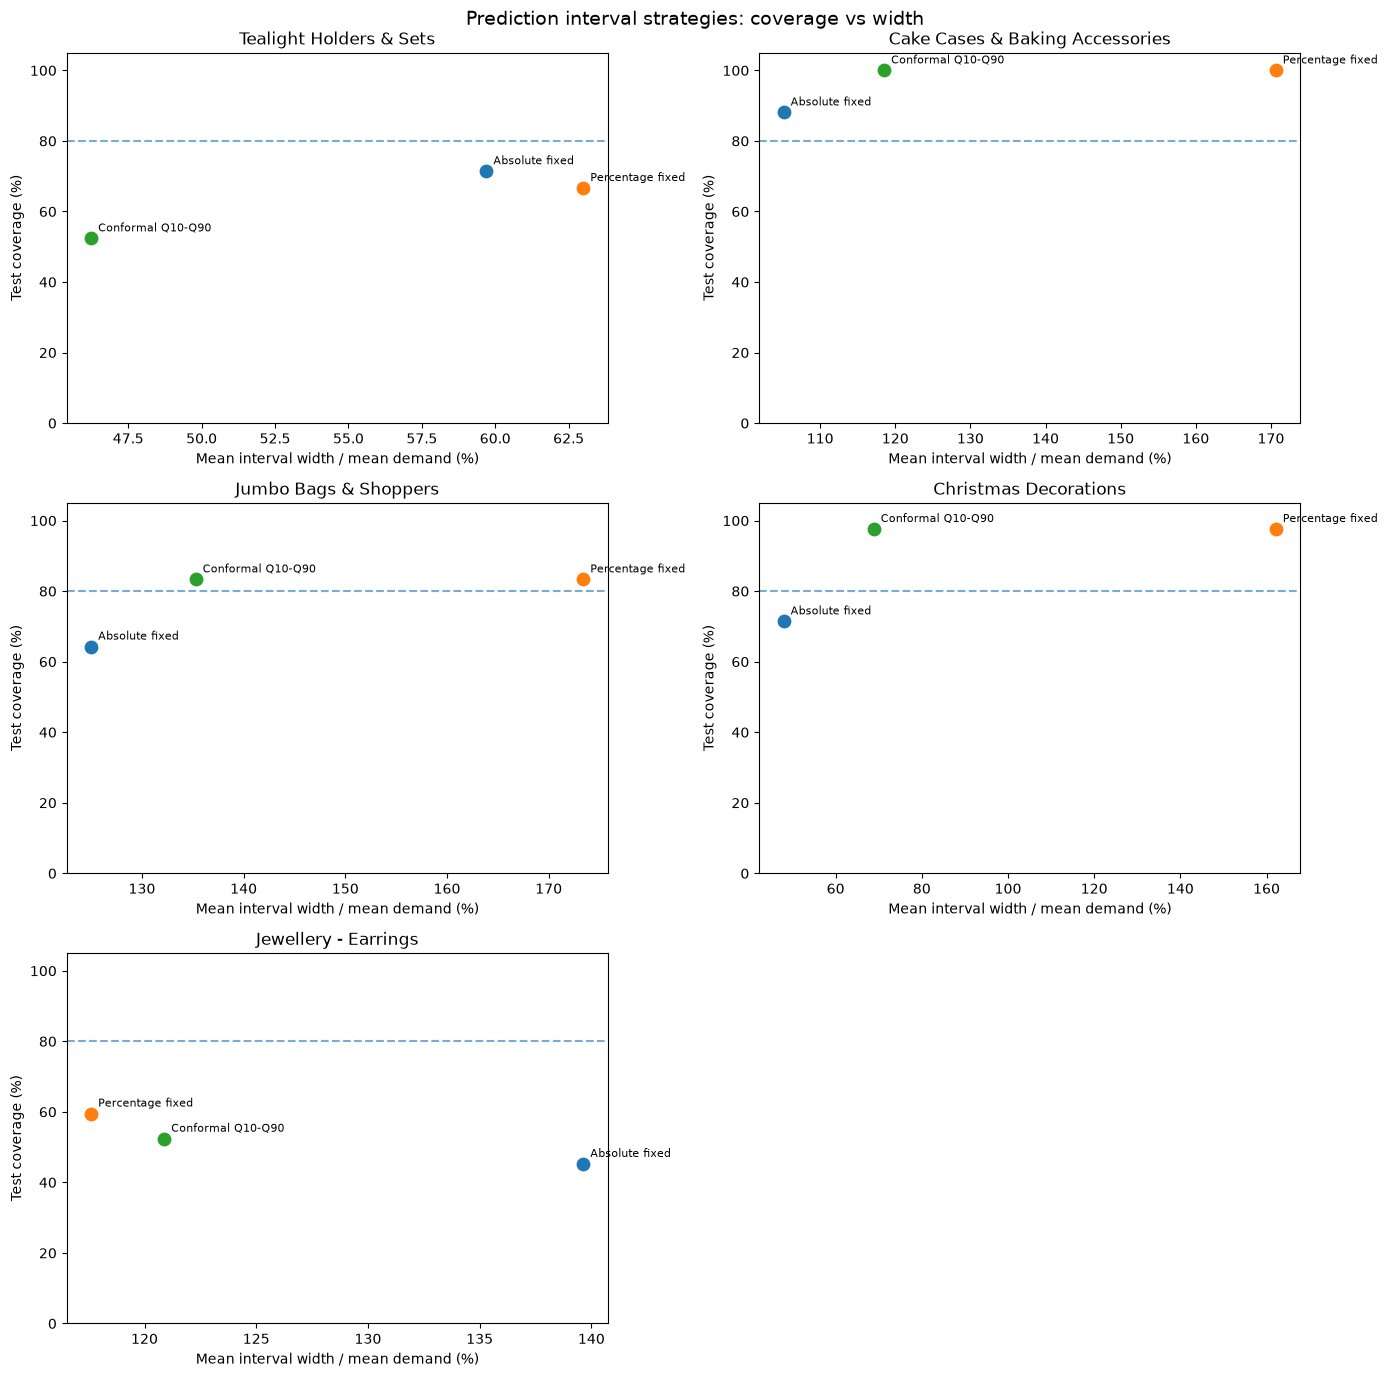

In [294]:
# Step 22.14 — Coverage vs interval width

fig, axes = plt.subplots(
    3,
    2,
    figsize=(14, 14)
)

axes = axes.flatten()

for ax, cat in zip(
    axes,
    selected_categories
):

    sub = interval_comparison_df[
        interval_comparison_df["Category"] == cat
    ]

    for _, row in sub.iterrows():

        ax.scatter(
            row["Relative width (%)"],
            row["Test coverage (%)"],
            s=80
        )

        ax.annotate(
            row["Method"],
            (
                row["Relative width (%)"],
                row["Test coverage (%)"]
            ),
            xytext=(5, 5),
            textcoords="offset points",
            fontsize=8
        )

    ax.axhline(
        80,
        linestyle="--",
        alpha=0.6
    )

    ax.set_title(cat)

    ax.set_xlabel(
        "Mean interval width / mean demand (%)"
    )

    ax.set_ylabel(
        "Test coverage (%)"
    )

    ax.set_ylim(0, 105)

for ax in axes[len(selected_categories):]:
    ax.set_visible(False)

fig.suptitle(
    "Prediction interval strategies: coverage vs width",
    fontsize=14
)

plt.tight_layout()
plt.show()

### Step 22.15 — Interpretation of prediction interval strategies

Three prediction-interval strategies were compared:

1. an absolute fixed margin around the point forecast;
2. a percentage-based fixed margin around the point forecast;
3. a conformally calibrated Q10-Q90 probabilistic interval.

For the two fixed-margin approaches, the interval size was selected using
validation data only, with the objective of reaching at least 80% empirical
coverage. The selected interval was then evaluated without modification on
the test set.

The results show that there is no universally superior interval construction.

**Tealight Holders & Sets.**

The absolute fixed interval achieves 71.43% test coverage with a relative
width of 59.70%, while the percentage interval reaches 66.67% with a
slightly larger width of 63.00%.

The conformal Q10-Q90 interval is narrower (46.24%) but covers only 52.38%
of observations. Both fixed approaches cover 80% of high-demand observations,
whereas the conformal interval covers none.

Importantly, none of the approaches reaches the nominal 80% target on the
test set, despite the fixed intervals reaching it during validation.

**Cake Cases & Baking Accessories.**

All three approaches provide relatively high test coverage.

The absolute interval achieves 88.10% coverage with a relative width of
105.15%. The conformal Q10-Q90 interval reaches 100% coverage with a width
of 118.52%.

The percentage interval also reaches 100% coverage, but requires a much
larger relative width of 170.65%.

All three methods cover all high-demand observations.

Therefore, the percentage interval does not provide additional coverage
relative to the conformal interval despite being substantially wider.

**Jumbo Bags & Shoppers.**

The conformal and percentage intervals both obtain 83.33% overall coverage.

However, the conformal interval is narrower (135.29% versus 173.41%).

The percentage interval nevertheless covers 100% of high-demand observations,
compared with only 33.33% for the conformal interval.

This illustrates that overall coverage alone does not fully describe the
quality of an uncertainty estimate when extreme-demand periods are
operationally important.

**Christmas Decorations.**

For Christmas Decorations, both the percentage-based and conformal
intervals achieve 97.62% test coverage.

However, the mean interval width of the percentage-based approach
corresponds to 162.16% of the mean observed demand, compared with only
68.87% for the conformal Q10-Q90 interval.

This does not mean that a ±162.16% margin was used. The percentage-based
interval was constructed using a ±75% margin around each point forecast;
162.16% represents the resulting mean interval width relative to the
mean observed demand.

**Jewellery - Earrings.**

This category remains the most difficult.

The percentage interval provides the highest overall coverage at 59.52%,
followed by the conformal interval at 52.38% and the absolute interval at
45.24%.

Despite relative interval widths exceeding 100% of mean demand, none of the
three methods covers any of the high-demand observations.

This reinforces the earlier conclusion that abrupt demand increases in this
category are not adequately represented by the information available to the
forecasting models.

### Overall conclusion

Increasing interval width generally increases empirical coverage, but wider
intervals are not automatically more informative.

The relationship between coverage and width is strongly category-dependent,
and no single interval construction dominates across all demand profiles.

Fixed intervals can perform well for some categories, but margins calibrated
on validation data do not necessarily retain their nominal coverage on the
test period.

Probabilistic intervals can provide substantially more efficient uncertainty
estimates in some cases, particularly for Christmas Decorations, but they
also fail for categories characterized by sparse and abrupt demand changes.

Therefore, prediction intervals should be evaluated jointly in terms of
coverage, width, and behavior during high-demand periods rather than using
coverage alone.

## Step 23: Final Research Conclusions

This notebook investigated retail demand forecasting at the category level,
using a 7-day forecasting window and a 7-day lead time as the main reference
configuration, while also examining alternative forecasting windows and lead
times.

The analysis went beyond comparing forecasting algorithms and focused on
robustness, failure modes, uncertainty, and the practical limitations of the
forecasting framework.

### Point forecasting

The experiments show that no single forecasting model dominates consistently
across all product categories.

Repeated evaluations demonstrate that apparent differences between models on
a single train-validation-test split can be unstable. Model selection should
therefore rely on repeated comparisons rather than on one favourable
realization of the data split.

### Forecasting window and lead time

The sensitivity analysis showed that forecasting performance depends jointly
on the forecasting window X, the lead time Y, and the product category.

Increasing the lead time often increases forecasting error, but the effect is
not systematic across all categories and forecasting windows.

Similarly, longer forecasting windows often produce lower WAPE values, but
this should not automatically be interpreted as improved forecasting ability.
Increasing X also increases the amount of cumulative demand in the target,
which changes the denominator of WAPE.

Therefore, X and Y should primarily reflect the operational forecasting
requirement, after which model performance should be evaluated for that
specific configuration.

### Forecast-error diagnosis

Detailed analysis of `Jewellery - Earrings` identified a systematic failure
during abrupt changes in demand.

The forecasting model tends to underestimate demand when future demand rises
sharply relative to recent historical levels and to overestimate demand after
elevated demand disappears.

This relationship remains visible after removing overlapping forecast windows,
indicating that it is not solely an artefact of repeated overlapping targets.

### Feature-engineering experiment

Additional features explicitly comparing short-term and long-term demand
regimes were introduced to address this behaviour.

Although these features improved performance substantially on one individual
test split, repeated paired evaluation across 30 splits showed no robust
improvement.

This illustrates the importance of validating feature-engineering hypotheses
across multiple data realizations rather than relying on a single favourable
test result.

### Feature selection

The effect of reducing the number of explanatory variables was also
investigated.

For `Jewellery - Earrings`, reducing the feature set from 30 to 10 variables
decreased mean validation WAPE from 75.23% to 73.61%, but increased its
standard deviation from 6.60 to 11.81.

For `Christmas Decorations`, the 10-feature model achieved a mean WAPE of
33.36%, compared with 33.82% for the full model, again with increased
variability.

These results show that a substantially smaller feature set can maintain
similar forecasting accuracy, but feature reduction does not provide a
consistent improvement in robustness.

The full feature set was therefore retained as the reference configuration.

### Predictability of demand spikes

The analysis then investigated whether large future demand increases could be
anticipated from the information available at forecast time.

For `Jewellery - Earrings`, 36 observations classified as future demand jumps
corresponded to only six distinct demand-jump episodes because of overlapping
forecast windows.

A repeated classification experiment produced a median ROC AUC of 0.556 and
a mean ROC AUC of 0.534, with substantial variability between splits.

These results suggest that historical demand and calendar variables contain
only weak and unstable information about future demand surges.

The difficulty of forecasting these events therefore appears to be partly an
information limitation rather than simply insufficient model complexity.

### Prediction intervals and uncertainty

Uncertainty was investigated using three prediction-interval strategies:

1. absolute fixed margins around the point forecast;
2. percentage-based fixed margins around the point forecast;
3. conformally calibrated Q10-Q90 probabilistic intervals.

The fixed margins were selected using validation data to target approximately
80% empirical coverage and were then evaluated unchanged on the test set.

The experiments reveal a clear trade-off between empirical coverage and
interval precision. Increasing interval width generally improves coverage,
but the amount of uncertainty required varies substantially across categories.

For `Christmas Decorations`, both the percentage-based and conformal
intervals achieved 97.62% test coverage.

However, the mean interval width of the percentage-based approach was
equivalent to 162.16% of the mean observed test demand, compared with only
68.87% for the conformal Q10-Q90 interval.

This does not mean that a ±162.16% margin was used. The percentage-based
interval was constructed using a ±75% margin around each individual point
forecast; 162.16% is the resulting mean interval width expressed relative to
the mean observed demand.

For `Cake Cases & Baking Accessories`, the absolute fixed interval achieved
88.10% coverage with a mean interval width equivalent to 105.15% of mean
demand, while the conformal interval achieved 100% coverage with a relative
width of 118.52%.

For `Jumbo Bags & Shoppers`, both the percentage-based and conformal intervals
achieved 83.33% overall coverage. The conformal interval was narrower, but the
percentage-based interval provided better coverage of high-demand
observations.

For `Tealight Holders & Sets`, none of the three approaches reached the
80% coverage target on the test set, despite the fixed intervals reaching it
during validation.

`Jewellery - Earrings` remained the most difficult category. None of the
tested approaches reached 80% test coverage, and none covered any of the
high-demand observations.

These results show that uncertainty estimates should not be evaluated using
coverage alone. Interval width and behaviour during high-demand periods are
also essential for assessing the usefulness of a prediction interval.

### Overall conclusion

The main limitation identified in this study is not simply the choice of
forecasting algorithm.

Forecasting performance depends strongly on the demand characteristics of each
category, the forecasting horizon, the lead time, and the amount of predictive
information available before a demand event occurs.

Historical sales and calendar features are useful for modelling regular demand
behaviour, but they provide limited information for anticipating rare and
abrupt demand surges.

Further improvements would therefore benefit from additional exogenous
variables available before the forecast date, such as promotions, prices,
marketing activity, inventory availability, or other operational information.

Until such information is available, point forecasts should be accompanied by
uncertainty estimates, and model performance should be assessed separately for
regular and high-demand regimes.

Finally, uncertainty intervals should be evaluated jointly in terms of
coverage and width: an interval that covers more observations is not
necessarily more informative if achieving that coverage requires an
excessively wide prediction range.